# Recommender Systems: MovieLens Dataset
## System Development for Marketing
### Amsterdam University of Applied Sciences 2025/2026

## Overview
This notebook implements two recommender system techniques on the
MovieLens 1M dataset:

- Technique A: Singular Value Decomposition (SVD) complemented with SVD++
- Technique D: Item-based Collaborative Filtering (ItemKNN) for both
  rating prediction and classification

The notebook follows a structured pipeline:
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering and Preprocessing
5. Train / Validation / Test Split
6. Model Implementation
7. Evaluation and Insights

## Dataset
The MovieLens 1M dataset contains:
- 1,000,209 anonymous ratings of approximately 3,900 movies
- Ratings submitted by 6,040 users who joined MovieLens in 2000
- Each user has a minimum of 20 ratings
- Ratings are on a scale of 1 to 5

Author: Sanjeev Dubey

Student ID: 500975381

GitHub: https://github.com/sanjeev-gitt/SDM-RecSys-Assignment

## Step 1: Environment Setup and Library Imports

All necessary Python libraries are imported in this step.
Each library serves a specific purpose in the recommender
system pipeline:

- pandas and numpy: data manipulation and numerical computation
- matplotlib and seaborn: data visualization
- sklearn: model evaluation metrics and preprocessing utilities
- scipy: sparse matrix operations and SVD decomposition

All models are implemented from scratch to ensure full
transparency and understanding of the underlying algorithms.
The Surprise library is not used, as required by the
assignment guidelines.

In [1]:
# sys provides access to system-specific parameters and functions
import sys

# pandas is used for data manipulation and working with DataFrames
import pandas as pd

# numpy is used for numerical operations and array handling
import numpy as np

# matplotlib.pyplot is used for creating plots and charts
import matplotlib.pyplot as plt

# seaborn is used for advanced statistical data visualization
import seaborn as sns

# train_test_split splits the dataset into training, validation
# and test sets in a reproducible way
from sklearn.model_selection import train_test_split

# mean_absolute_error and mean_squared_error measure rating
# prediction accuracy for regression tasks
# precision_score, recall_score, f1_score and roc_auc_score
# measure performance for binary classification tasks
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score)

# LabelEncoder converts categorical labels into numeric values
# MinMaxScaler normalizes numeric features to the range 0 to 1
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# scipy.sparse provides efficient storage for matrices
# that contain mostly zero values
import scipy.sparse as sp

# svds performs truncated Singular Value Decomposition
# which is the core algorithm used in Technique A
from scipy.sparse.linalg import svds

# warnings module controls the display of warning messages
import warnings

# suppresses all warning messages to keep output clean
warnings.filterwarnings('ignore')

# configures pandas to display up to 100 rows in output
pd.set_option('display.max_rows', 100)

# configures pandas to display up to 50 columns in output
pd.set_option('display.max_columns', 50)

# configures pandas output width to 1000 characters
# to prevent unwanted line wrapping
pd.set_option('display.width', 1000)

# prints confirmation that all libraries loaded without errors
print("All libraries loaded successfully")

All libraries loaded successfully


## Step 2: Data Loading

The MovieLens 1M dataset consists of three files:

| File | Description |
|------|-------------|
| movies.csv | Movie information including title and genres |
| ratings.csv | User-movie ratings with timestamps |
| users.csv | User demographic information |

All three files are loaded and an initial inspection of their
structure, dimensions and data types is performed to understand
the dataset before any cleaning or transformation takes place.

In [2]:
# =============================================================
# STEP 2: LOAD MOVIELENS DATASET
# =============================================================
# MovieLens 1M Dataset contains three files:
# movies.csv  : movie information including id, title and genres
# ratings.csv : user movie ratings with userId, movieId,
#               rating and timestamp
# users.csv   : user demographics including gender, age,
#               occupation and zip code
# =============================================================

# os module is used to construct file paths in a way that
# works correctly on both Windows and Unix operating systems
import os

# raw string prefix r is used so that Windows backslashes
# in the path are not interpreted as escape characters
DATA_PATH = r"C:\Users\sanje\OneDrive\Desktop\Typeit\SDM\raw_data\MovieLens"

# os.path.join combines the folder path and filename into
# a full file path that works on any operating system
# pd.read_csv reads the CSV file and returns a pandas DataFrame
movies  = pd.read_csv(os.path.join(DATA_PATH, 'movies.csv'))

# loads the ratings file containing all user-movie rating pairs
ratings = pd.read_csv(os.path.join(DATA_PATH, 'ratings.csv'))

# loads the users file containing demographic information
# for each user in the dataset
users   = pd.read_csv(os.path.join(DATA_PATH, 'users.csv'))

# prints a separator line to make output easier to read
print("=" * 50)

# prints the section heading
print("DATASET SHAPES")

# prints a separator line to close the heading block
print("=" * 50)

# shape[0] gives the number of rows and shape[1] gives
# the number of columns in the movies DataFrame
# the comma format specifier adds thousand separators
print(f"Movies  : {movies.shape[0]:,} rows x {movies.shape[1]} columns")

# prints the dimensions of the ratings DataFrame
print(f"Ratings : {ratings.shape[0]:,} rows x {ratings.shape[1]} columns")

# prints the dimensions of the users DataFrame
print(f"Users   : {users.shape[0]:,} rows x {users.shape[1]} columns")

# prints a blank line followed by a separator before the preview section
print("\n" + "=" * 50)

# prints the heading for the movies preview section
print("MOVIES - First 5 rows")

# prints a separator line under the heading
print("=" * 50)

# head() returns the first 5 rows of the DataFrame by default
print(movies.head())

# prints separator before the ratings preview section
print("\n" + "=" * 50)

# prints the heading for the ratings preview section
print("RATINGS - First 5 rows")

# prints a separator line under the heading
print("=" * 50)

# displays the first 5 rows of the ratings DataFrame
print(ratings.head())

# prints separator before the users preview section
print("\n" + "=" * 50)

# prints the heading for the users preview section
print("USERS - First 5 rows")

# prints a separator line under the heading
print("=" * 50)

# displays the first 5 rows of the users DataFrame
print(users.head())

# prints separator before the data types section
print("\n" + "=" * 50)

# prints the heading for the data types section
print("DATA TYPES")

# prints a separator line under the heading
print("=" * 50)

# prints a label before the movies data types output
print("\nMovies dtypes:")

# dtypes attribute shows the data type of each column
# in the movies DataFrame
print(movies.dtypes)

# prints a label before the ratings data types output
print("\nRatings dtypes:")

# displays the data type of each column in the ratings DataFrame
print(ratings.dtypes)

# prints a label before the users data types output
print("\nUsers dtypes:")

# displays the data type of each column in the users DataFrame
print(users.dtypes)

DATASET SHAPES
Movies  : 3,883 rows x 3 columns
Ratings : 1,000,209 rows x 4 columns
Users   : 6,040 rows x 5 columns

MOVIES - First 5 rows
   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy

RATINGS - First 5 rows
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291

USERS - First 5 rows
   userId gender  age  occupation    zip
0       1      F    1          10  48067
1       2      M   56          16  70072


### Step 2: Observations

The dataset loaded successfully with the following structure:

| File | Rows | Columns |
|------|------|---------|
| Movies | 3,883 | 3 |
| Ratings | 1,000,209 | 4 |
| Users | 6,040 | 5 |

Key observations:
- The ratings file contains over 1 million ratings, making this
  a sufficiently large dataset for collaborative filtering
- Genres are stored as pipe-separated strings, for example
  Animation|Comedy, requiring encoding in feature engineering
- The timestamp column is in Unix format and requires conversion
  to a readable datetime format
- Age is stored as grouped categories (1, 18, 25, 35, 45, 50, 56)
  rather than exact ages
- Zip codes are stored as strings which is correct as they may
  contain leading zeros that would be lost if stored as integers

## Step 3: Data Cleaning

Data cleaning is a critical step before any analysis or modelling.
The following issues are systematically checked and handled:

| Check | Description |
|-------|-------------|
| Missing values | Identify and handle null entries |
| Duplicates | Remove duplicate rows and duplicate user-movie pairs |
| Rating outliers | Ensure all ratings fall within the valid 1 to 5 scale |
| Inconsistencies | Validate gender values, age groups and referential integrity |
| Timestamp | Convert Unix timestamps to readable datetime format |
| Cold-start | Remove users and movies with insufficient ratings |

Cold-start filtering is especially important in recommender
systems. As stated in the lecture materials, a small number
of high-confidence neighbours is by far preferable to a large
number of neighbours for which the similarity weights are not
trustworthy. A minimum threshold of 20 ratings per user and
10 ratings per movie is applied to ensure reliable similarity
calculations.

In [3]:
# =============================================================
# STEP 3: DATA CLEANING
# =============================================================
# The following checks are performed in this step:
# 3.1 Missing values
# 3.2 Duplicate records
# 3.3 Outliers in ratings
# 3.4 Invalid or inconsistent values
# 3.5 Timestamp conversion
# 3.6 Final clean summary
# 3.7 Cold-start filtering
# =============================================================

# ─────────────────────────────────────────────────────────────
# 3.1 MISSING VALUES CHECK
# ─────────────────────────────────────────────────────────────

# prints section heading for missing value analysis
print("=" * 50)
print("3.1 MISSING VALUES")
print("=" * 50)

# isnull() returns True for each missing cell
# sum() counts the total missing values per column
print("\nMovies missing values:")
print(movies.isnull().sum())

# counts missing values in each column of the ratings DataFrame
print("\nRatings missing values:")
print(ratings.isnull().sum())

# counts missing values in each column of the users DataFrame
print("\nUsers missing values:")
print(users.isnull().sum())

# ─────────────────────────────────────────────────────────────
# 3.2 DUPLICATE RECORDS CHECK
# ─────────────────────────────────────────────────────────────

# prints section heading for duplicate record analysis
print("\n" + "=" * 50)
print("3.2 DUPLICATE RECORDS")
print("=" * 50)

# duplicated() returns True for rows that are exact duplicates
# sum() counts the total number of duplicate rows
print(f"\nMovies duplicates  : {movies.duplicated().sum()}")
print(f"Ratings duplicates : {ratings.duplicated().sum()}")
print(f"Users duplicates   : {users.duplicated().sum()}")

# checks specifically for cases where the same user rated
# the same movie more than once which is invalid in this dataset
dup_ratings = ratings.duplicated(
    subset=['userId', 'movieId']).sum()

# prints the count of duplicate user-movie rating pairs
print(f"\nDuplicate user-movie rating pairs: {dup_ratings}")

# ─────────────────────────────────────────────────────────────
# 3.3 RATING OUTLIERS CHECK
# ─────────────────────────────────────────────────────────────

# prints section heading for rating range validation
print("\n" + "=" * 50)
print("3.3 RATING OUTLIERS")
print("=" * 50)

# between(1, 5) returns True for valid ratings
# the tilde ~ inverts the result to find invalid ratings
invalid_ratings = ratings[~ratings['rating'].between(1, 5)]

# prints the count of ratings outside the valid 1 to 5 range
print(f"\nInvalid ratings (outside 1 to 5 scale): "
      f"{len(invalid_ratings)}")

# sorted() arranges unique rating values in ascending order
print(f"Valid rating values found: "
      f"{sorted(ratings['rating'].unique())}")

# ─────────────────────────────────────────────────────────────
# 3.4 INCONSISTENCY CHECKS
# ─────────────────────────────────────────────────────────────

# prints section heading for data consistency checks
print("\n" + "=" * 50)
print("3.4 INCONSISTENCY CHECKS")
print("=" * 50)

# unique() returns all distinct gender values found in the column
# expected values are M and F only
print(f"\nUnique gender values : {users['gender'].unique()}")

# defines the complete list of valid age group codes
# used by the MovieLens dataset
valid_ages = [1, 18, 25, 35, 45, 50, 56]

# isin() checks if each age value is in the valid list
# the tilde ~ inverts to find rows with invalid ages
invalid_ages = users[~users['age'].isin(valid_ages)]

# prints the count of users with invalid age values
print(f"Invalid age values   : {len(invalid_ages)}")

# prints all unique age group values found in the dataset
print(f"Valid age groups     : {sorted(users['age'].unique())}")

# converts the movieId column from ratings into a Python set
# for fast membership lookup
movies_in_ratings = set(ratings['movieId'].unique())

# converts the movieId column from movies into a Python set
movies_in_movies  = set(movies['movieId'].unique())

# set difference finds IDs present in ratings but not in movies
# this would indicate a referential integrity violation
missing_movies = movies_in_ratings - movies_in_movies

# prints the count of movie IDs missing from the movies file
print(f"\nMovieIds in ratings but not in movies : "
      f"{len(missing_movies)}")

# converts the userId column from ratings into a Python set
users_in_ratings = set(ratings['userId'].unique())

# converts the userId column from users into a Python set
users_in_users = set(users['userId'].unique())

# set difference finds user IDs in ratings with no user profile
missing_users = users_in_ratings - users_in_users

# prints the count of user IDs missing from the users file
print(f"UserIds in ratings but not in users   : "
      f"{len(missing_users)}")

# ─────────────────────────────────────────────────────────────
# 3.5 TIMESTAMP CONVERSION
# ─────────────────────────────────────────────────────────────

# prints section heading for timestamp conversion
print("\n" + "=" * 50)
print("3.5 TIMESTAMP CONVERSION")
print("=" * 50)

# pd.to_datetime converts integer Unix timestamps to datetime
# unit='s' specifies that the values are in seconds
ratings['timestamp'] = pd.to_datetime(
    ratings['timestamp'], unit='s')

# confirms the timestamp conversion completed successfully
print("\nTimestamp converted to datetime successfully")

# min() and max() return the earliest and latest rating dates
print(f"Rating date range: "
      f"{ratings['timestamp'].min()} to "
      f"{ratings['timestamp'].max()}")

# displays the first 3 rows to verify the conversion result
print("\nRatings after timestamp conversion:")
print(ratings.head(3))

# ─────────────────────────────────────────────────────────────
# 3.6 FINAL CLEAN SUMMARY
# ─────────────────────────────────────────────────────────────

# prints section heading for the clean data summary
print("\n" + "=" * 50)
print("3.6 FINAL CLEAN DATASET SUMMARY")
print("=" * 50)

# prints the number of rows remaining in each dataset
print(f"\nMovies  : {movies.shape[0]:,} rows - clean")
print(f"Ratings : {ratings.shape[0]:,} rows - clean")
print(f"Users   : {users.shape[0]:,} rows - clean")

# ─────────────────────────────────────────────────────────────
# 3.7 COLD-START FILTERING
# ─────────────────────────────────────────────────────────────
# Users or items with very few ratings produce unreliable
# similarity calculations in collaborative filtering models.
# Lecture 3 states that a small number of high-confidence
# neighbours is preferable to a large number of neighbours
# with untrustworthy similarity weights.
# Threshold: minimum 20 ratings per user, 10 per movie.
# ─────────────────────────────────────────────────────────────

# prints section heading for cold-start filtering
print("\n" + "=" * 50)
print("3.7 COLD-START FILTERING")
print("=" * 50)

# prints dataset statistics before any filtering is applied
print("\nBefore Filtering")
print(f"Total ratings  : {len(ratings):,}")
print(f"Unique users   : {ratings['userId'].nunique():,}")
print(f"Unique movies  : {ratings['movieId'].nunique():,}")

# groupby groups all ratings by userId
# count() returns the number of ratings each user has given
user_counts = ratings.groupby('userId')['rating'].count()

# groupby groups all ratings by movieId
# count() returns the number of ratings each movie has received
movie_counts = ratings.groupby('movieId')['rating'].count()

# prints the heading for threshold analysis
print("\nCold-Start Analysis")

# iterates through three different threshold values
# to show the impact of each threshold on data retention
for threshold in [5, 10, 20]:

    # counts users who have fewer ratings than the threshold
    cold_users = (user_counts < threshold).sum()

    # counts movies that have fewer ratings than the threshold
    cold_movies = (movie_counts < threshold).sum()

    # prints the results for the current threshold value
    print(f"\nThreshold = {threshold} ratings:")
    print(f"  Users  with fewer than {threshold} ratings : "
          f"{cold_users:,}")
    print(f"  Movies with fewer than {threshold} ratings : "
          f"{cold_movies:,}")

# minimum number of ratings a user must have to be retained
MIN_USER_RATINGS  = 20

# minimum number of ratings a movie must have to be retained
MIN_MOVIE_RATINGS = 10

# boolean indexing selects only users meeting the threshold
# .index extracts the userId values that pass the filter
valid_users = user_counts[
    user_counts >= MIN_USER_RATINGS].index

# boolean indexing selects only movies meeting the threshold
valid_movies = movie_counts[
    movie_counts >= MIN_MOVIE_RATINGS].index

# isin() checks if each userId is in the valid_users list
# the ampersand & combines both conditions with logical AND
# .copy() creates an independent copy to avoid SettingWithCopyWarning
ratings_clean = ratings[
    ratings['userId'].isin(valid_users) &
    ratings['movieId'].isin(valid_movies)
].copy()

# prints dataset statistics after filtering is applied
print("\nAfter Filtering")
print(f"Min user  ratings threshold : {MIN_USER_RATINGS}")
print(f"Min movie ratings threshold : {MIN_MOVIE_RATINGS}")
print(f"Total ratings  : {len(ratings_clean):,}")
print(f"Unique users   : {ratings_clean['userId'].nunique():,}")
print(f"Unique movies  : {ratings_clean['movieId'].nunique():,}")

# calculates how many ratings were removed by the filter
print(f"\nRatings removed : "
      f"{len(ratings) - len(ratings_clean):,}")

# calculates how many unique users were removed by the filter
print(f"Users removed   : "
      f"{ratings['userId'].nunique() - ratings_clean['userId'].nunique():,}")

# calculates how many unique movies were removed by the filter
print(f"Movies removed  : "
      f"{ratings['movieId'].nunique() - ratings_clean['movieId'].nunique():,}")

# confirms that ratings_clean is the dataset used going forward
print("\nratings_clean will be used for all further steps")

3.1 MISSING VALUES

Movies missing values:
movieId    0
title      0
genres     0
dtype: int64

Ratings missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Users missing values:
userId        0
gender        0
age           0
occupation    0
zip           0
dtype: int64

3.2 DUPLICATE RECORDS

Movies duplicates  : 0
Ratings duplicates : 0
Users duplicates   : 0

Duplicate user-movie rating pairs: 0

3.3 RATING OUTLIERS

Invalid ratings (outside 1 to 5 scale): 0
Valid rating values found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

3.4 INCONSISTENCY CHECKS

Unique gender values : ['F' 'M']
Invalid age values   : 0
Valid age groups     : [np.int64(1), np.int64(18), np.int64(25), np.int64(35), np.int64(45), np.int64(50), np.int64(56)]

MovieIds in ratings but not in movies : 0
UserIds in ratings but not in users   : 0

3.5 TIMESTAMP CONVERSION

Timestamp converted to datetime successfully
Rating date range: 2000-04-25 23:05:32 t

### Step 3: Observations

The MovieLens dataset proved to be exceptionally clean:

| Check | Result |
|-------|--------|
| Missing values | None found across all three files |
| Duplicates | No duplicate rows or user-movie pairs |
| Rating outliers | All ratings valid on the 1 to 5 scale |
| Gender values | Only valid values M and F found |
| Age groups | All ages within expected groups |
| Referential integrity | All IDs consistent across files |
| Timestamp | Successfully converted, covering 2000 to 2003 |

Cold-Start Filtering Results:

- All 6,040 users had at least 20 ratings so no users were removed
- 446 movies (12% of all movies) had fewer than 10 ratings and
  were removed to prevent unreliable similarity calculations
- Only 1,670 ratings (0.17% of total) were removed
- Final clean dataset: 998,539 ratings, 6,040 users, 3,260 movies

The fact that no users suffered from cold-start confirms that the
MovieLens platform enforced a minimum rating requirement during
data collection. The long tail of rarely-rated movies is a classic
characteristic of recommender system datasets, confirming the
importance of cold-start filtering at the item level.

## Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps to understand the structure,
patterns and characteristics of the dataset before building
any models. This is a critical step that directly informs
feature engineering and modelling decisions.

The following analyses are performed:

| Analysis | Purpose |
|----------|---------|
| 4.1 Descriptive Statistics | Understand central tendency and spread of ratings |
| 4.2 Rating Distribution | Identify rating patterns and positivity bias |
| 4.3 User Activity Analysis | Understand how active users are in the system |
| 4.4 Movie Popularity Analysis | Identify popular vs rarely rated movies |
| 4.5 Genre Analysis | Understand content distribution across genres |
| 4.6 User Demographics Analysis | Analyze age and gender patterns |
| 4.7 Correlation Analysis | Identify relationships between variables |
| 4.8 Sparsity Analysis | Quantify the density of the user-item matrix |
| 4.9 User and Item Bias | Detect systematic rating tendencies |
| 4.10 Temporal Patterns | Analyze how ratings evolve over time |

Temporal analysis is particularly important for this assignment
as Technique A (SVD++) incorporates temporal dynamics. As
discussed in the lecture materials, timeSVD++ accounts for
the fact that both user preferences and item popularity change
over time, making temporal EDA a necessary foundation for
model design.

4.1 DESCRIPTIVE STATISTICS

Ratings Statistics:
           rating
count  998539.000
mean        3.583
std         1.117
min         1.000
25%         3.000
50%         4.000
75%         4.000
max         5.000

Users Statistics:
            age  occupation
count  6040.000    6040.000
mean     30.639       8.147
std      12.896       6.330
min       1.000       0.000
25%      25.000       3.000
50%      25.000       7.000
75%      35.000      14.000
max      56.000      20.000

Key Facts:
Total ratings          : 998,539
Unique users           : 6,040
Unique movies rated    : 3,260
Total movies available : 3,883
Average rating         : 3.583
Median rating          : 4.0
Std deviation          : 1.117
Skewness               : -0.554
Kurtosis               : -0.350

Ratings Per User:
Min    : 17
Max    : 2233
Mean   : 165.3
Median : 96.0
Std    : 192.2

Ratings Per Movie:
Min    : 10
Max    : 3428
Mean   : 306.3
Median : 161.0
Std    : 395.8

Average Rating Per Movie:
Min    : 1.059
Max 

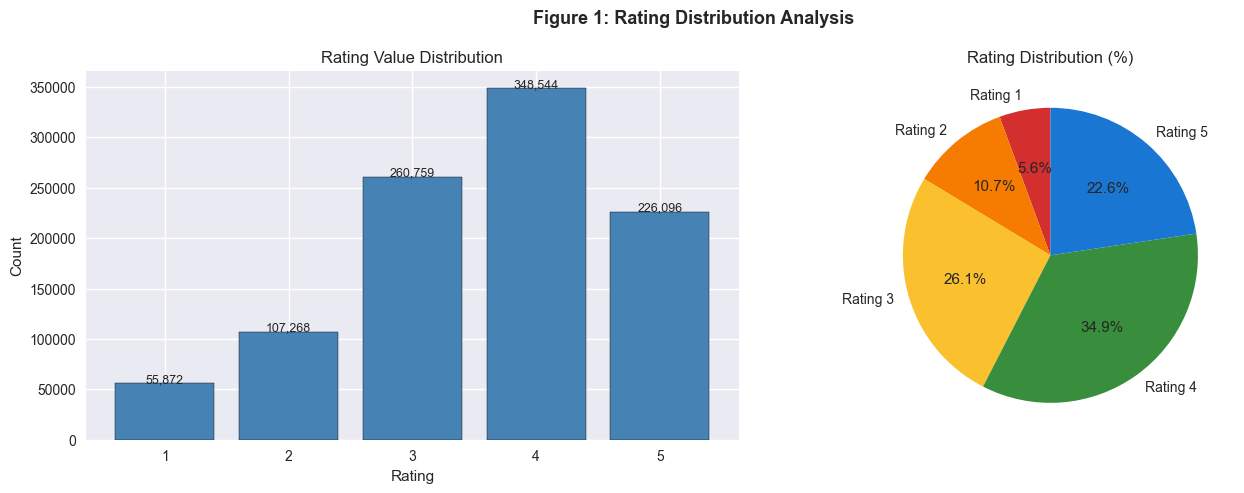

Figure 1 saved.

4.3 USER ACTIVITY ANALYSIS


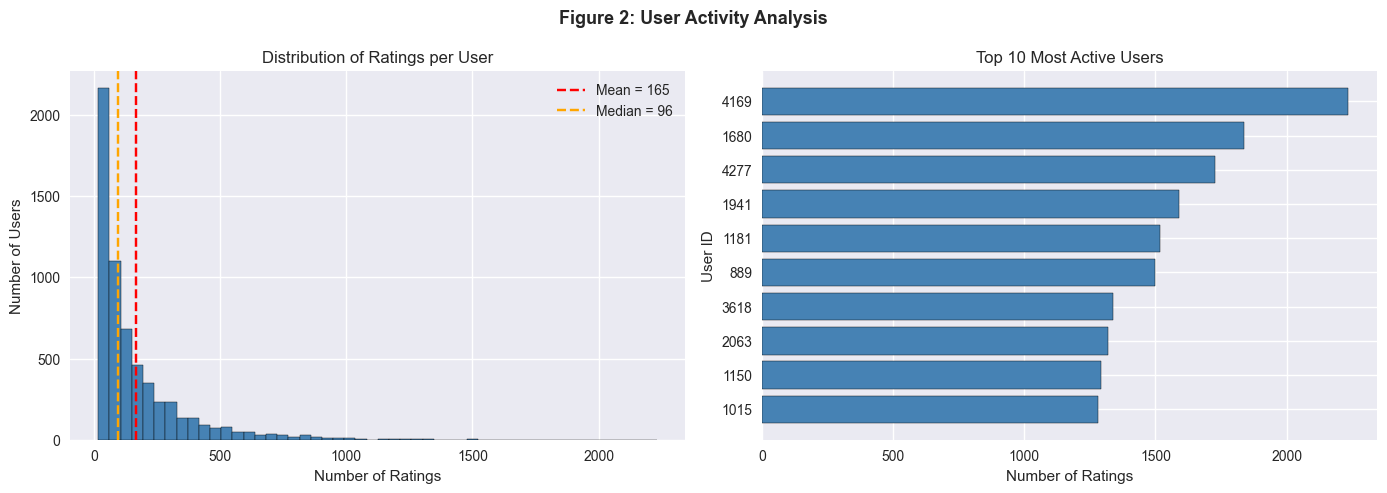

Figure 2 saved.

4.4 MOVIE POPULARITY ANALYSIS


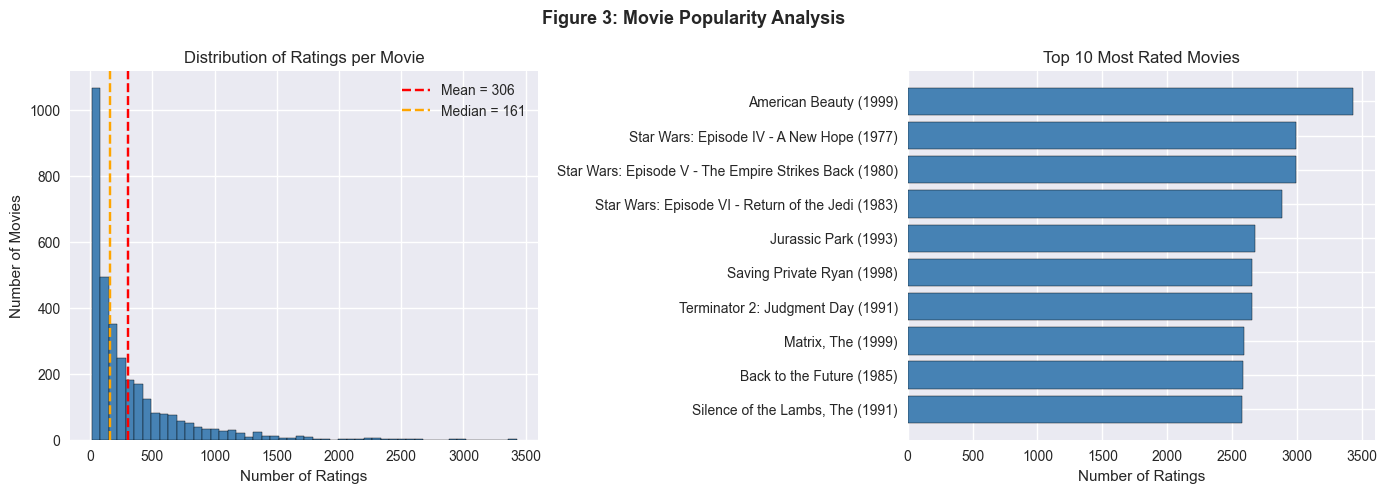

Figure 3 saved.

4.5 GENRE ANALYSIS

Genre counts:
genres
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Name: count, dtype: int64


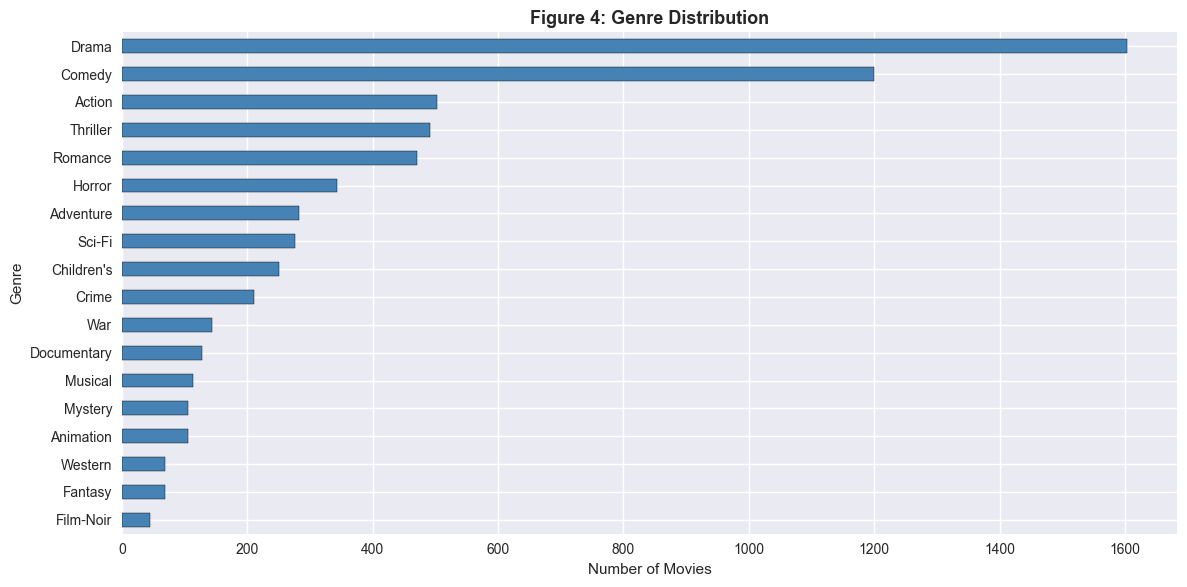

Figure 4 saved.

Average rating per genre:
             avg_rating  num_ratings
genre_list                          
Film-Noir         4.076        18245
Documentary       3.940         7758
War               3.894        68503
Drama             3.768       353654
Crime             3.709        79496
Animation         3.685        43285
Mystery           3.669        40141
Musical           3.666        41516
Western           3.638        20673
Romance           3.608       147406
Thriller          3.571       189566
Comedy            3.523       356172
Action            3.491       257367
Adventure         3.478       133893
Sci-Fi            3.467       157245
Fantasy           3.448        36291
Children's        3.422        72152
Horror            3.217        76264


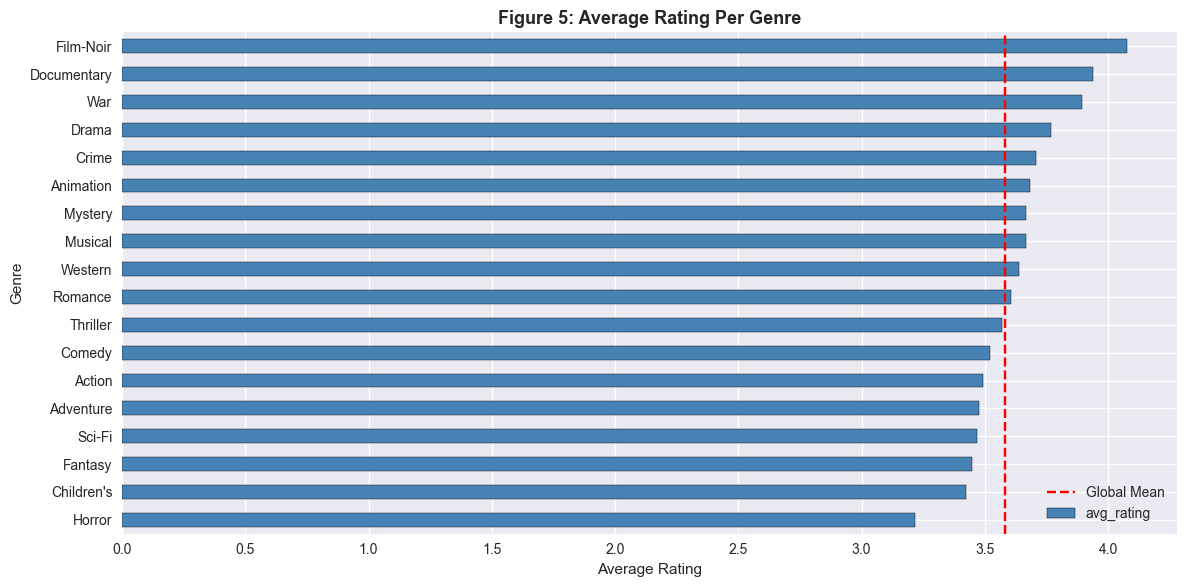

Figure 5 saved.

4.6 USER DEMOGRAPHICS ANALYSIS


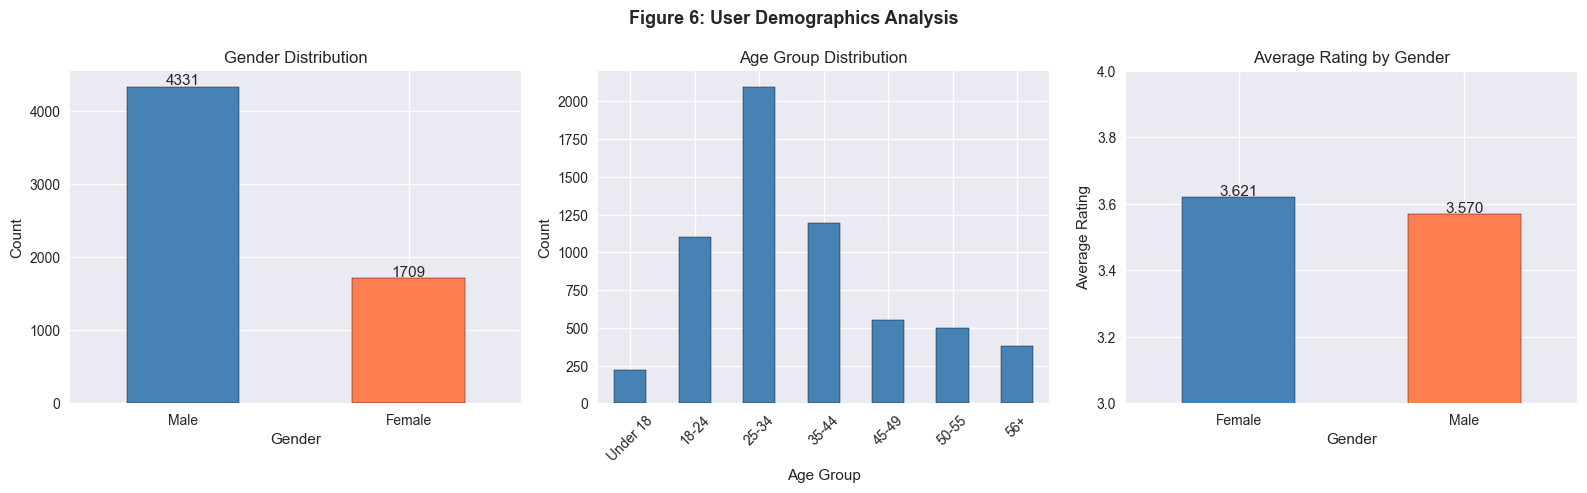

Figure 6 saved.

Average rating by age group:
age
Under 18    3.551
18-24       3.509
25-34       3.546
35-44       3.619
45-49       3.639
50-55       3.716
56+         3.768
Name: rating, dtype: float64


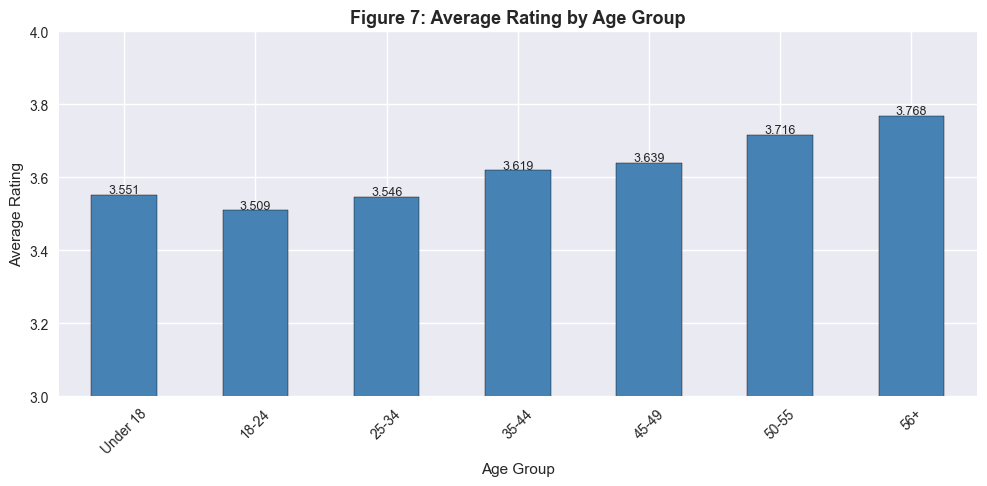

Figure 7 saved.

4.7 CORRELATION ANALYSIS

Correlation matrix:
            rating    age  occupation  gender_enc
rating       1.000  0.057       0.007      -0.020
age          0.057  1.000       0.079      -0.003
occupation   0.007  0.079       1.000       0.115
gender_enc  -0.020 -0.003       0.115       1.000


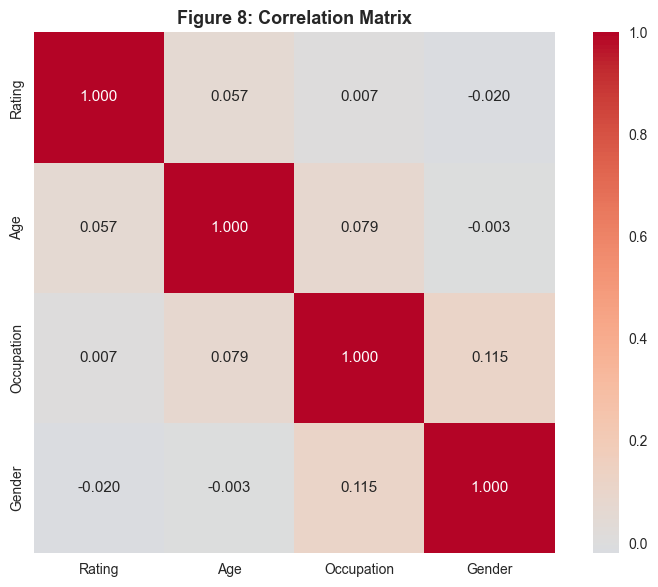

Figure 8 saved.

4.8 SPARSITY ANALYSIS

Number of users        : 6,040
Number of movies       : 3,260
Actual ratings         : 998,539
Possible ratings       : 19,690,400
Sparsity               : 94.9288%
Density                : 5.0712%

4.9 USER BIAS AND ITEM BIAS

Global mean rating : 3.5826

User Bias:
Mean user bias : 0.1209
Std user bias  : 0.4292
Min user bias  : -2.5662
Max user bias  : 1.3804

Item Bias:
Mean item bias : -0.2975
Std item bias  : 0.6117
Min item bias  : -2.5238
Max item bias  : 1.0261


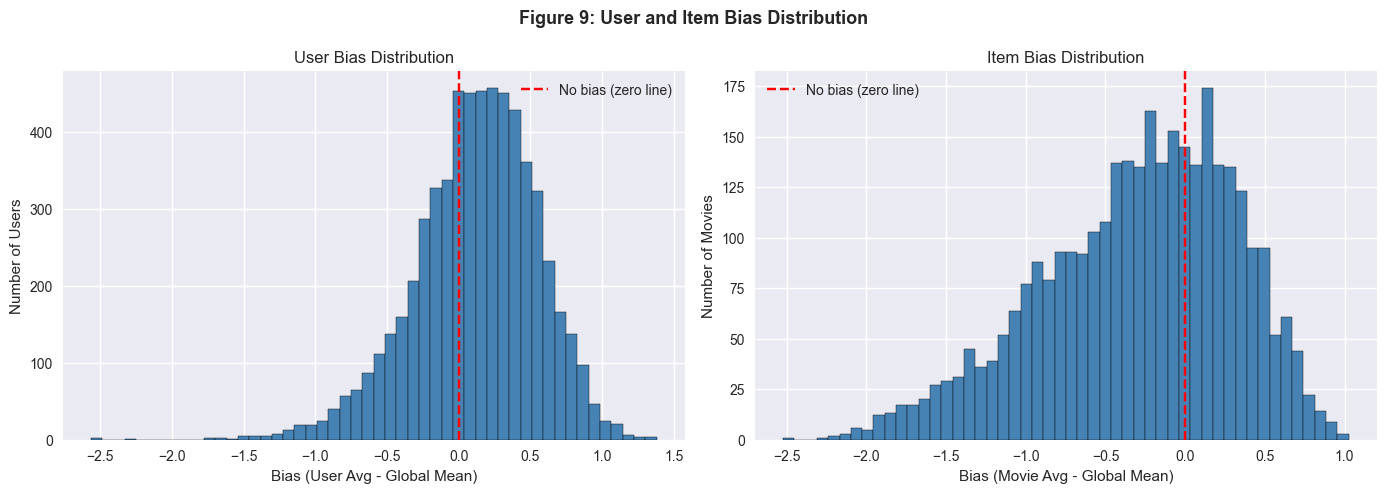

Figure 9 saved.

4.10 TEMPORAL PATTERNS ANALYSIS

Ratings Count Per Year:
year
2000    903394
2001     67870
2002     23938
2003      3337
Name: rating, dtype: int64

Average Rating Per Year:
year
2000    3.591
2001    3.513
2002    3.460
2003    3.487
Name: rating, dtype: float64

Ratings Count Per Month:
month
1      23007
2      12100
3       8508
4      19376
5      74173
6      61011
7      96848
8     188440
9      56677
10     45425
11    294922
12    118052
Name: rating, dtype: int64

Average Rating Per Month:
month
1     3.543
2     3.525
3     3.457
4     3.523
5     3.603
6     3.617
7     3.619
8     3.567
9     3.603
10    3.610
11    3.573
12    3.583
Name: rating, dtype: float64


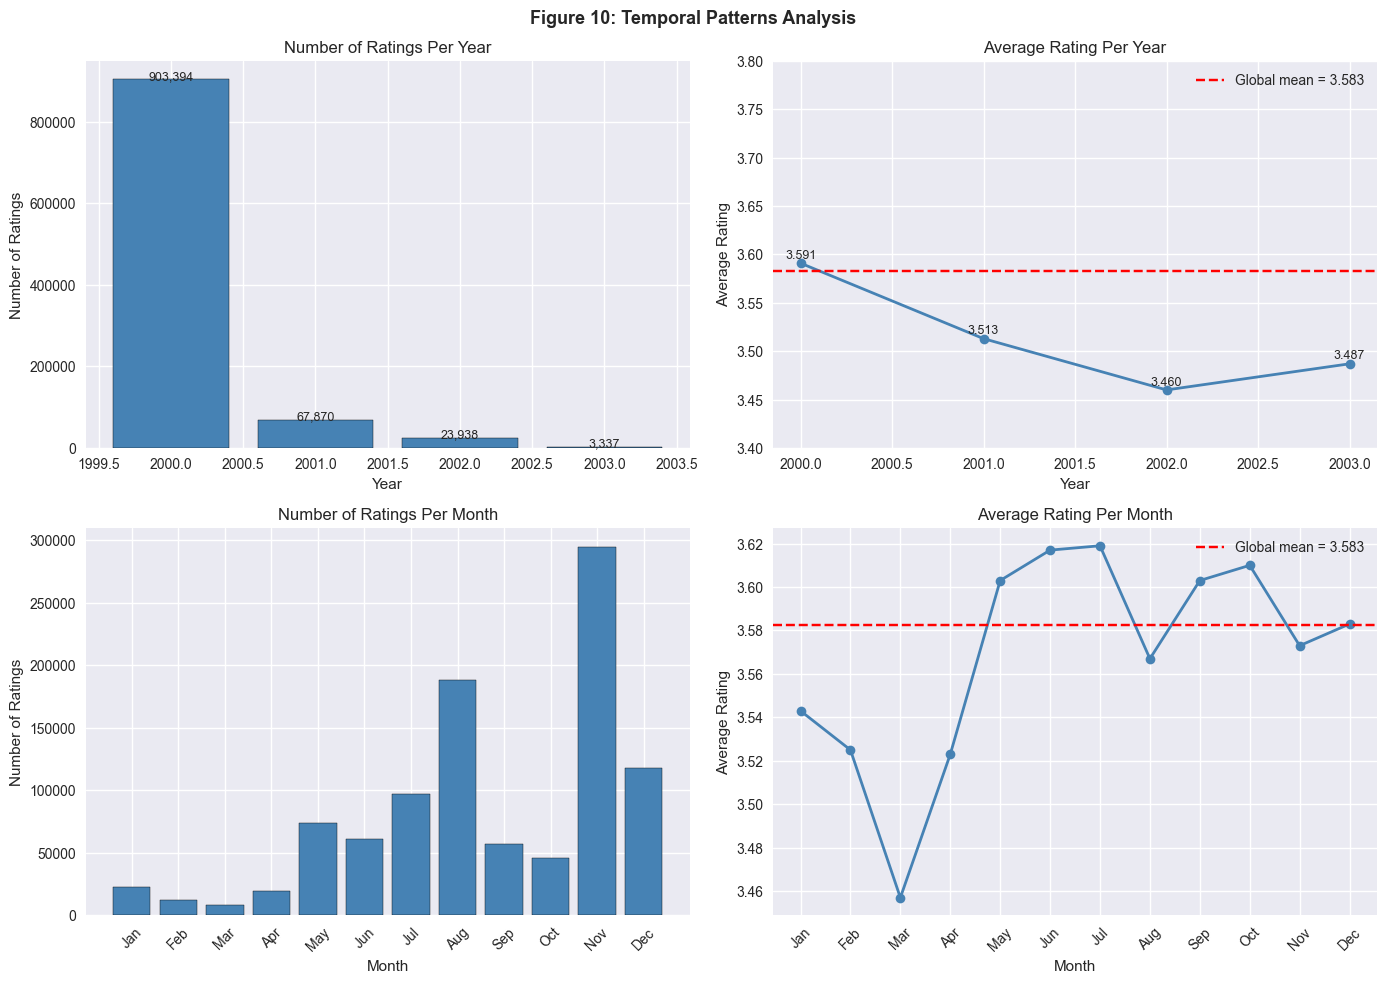

Figure 10 saved.

Yearly User Behavior Summary:
      total_ratings  unique_users  unique_movies  avg_rating
year                                                        
2000         903394          6034           3258       3.591
2001          67870          1070           3150       3.513
2002          23938           565           2880       3.460
2003           3337           178           1590       3.487

STEP 4 EDA COMPLETE


In [4]:
# =============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================
# 4.1  Descriptive Statistics
# 4.2  Rating Distribution
# 4.3  User Activity Analysis
# 4.4  Movie Popularity Analysis
# 4.5  Genre Analysis
# 4.6  User Demographics Analysis
# 4.7  Correlation Analysis
# 4.8  Sparsity Analysis
# 4.9  User Bias and Item Bias
# 4.10 Temporal Patterns Analysis
# =============================================================

# sets the visual style for all matplotlib plots in this notebook
plt.style.use('seaborn-v0_8')

# sets the default figure size for all plots to 12 by 5 inches
plt.rcParams['figure.figsize'] = (12, 5)

# sets the default font size for all plot text to 11 points
plt.rcParams['font.size'] = 11

# ─────────────────────────────────────────────────────────────
# 4.1 DESCRIPTIVE STATISTICS
# ─────────────────────────────────────────────────────────────

# prints the section heading for descriptive statistics
print("=" * 55)
print("4.1 DESCRIPTIVE STATISTICS")
print("=" * 55)

# describe() computes count, mean, std, min, quartiles and max
# round(3) limits output to 3 decimal places for readability
print("\nRatings Statistics:")
print(ratings_clean[['rating']].describe().round(3))

# computes descriptive statistics for age and occupation columns
print("\nUsers Statistics:")
print(users[['age', 'occupation']].describe().round(3))

# prints key summary figures for the overall dataset
print("\nKey Facts:")

# len() returns the total number of rows in the DataFrame
print(f"Total ratings          : {len(ratings_clean):,}")

# nunique() counts the number of distinct values in the column
print(f"Unique users           : {ratings_clean['userId'].nunique():,}")
print(f"Unique movies rated    : {ratings_clean['movieId'].nunique():,}")
print(f"Total movies available : {movies['movieId'].nunique():,}")

# mean() computes the arithmetic average of all rating values
print(f"Average rating         : {ratings_clean['rating'].mean():.3f}")

# median() computes the middle value of the rating distribution
print(f"Median rating          : {ratings_clean['rating'].median():.1f}")

# std() computes the standard deviation of ratings
print(f"Std deviation          : {ratings_clean['rating'].std():.3f}")

# skew() measures the asymmetry of the rating distribution
# negative skewness indicates more high ratings than low ratings
print(f"Skewness               : {ratings_clean['rating'].skew():.3f}")

# kurt() measures the tail heaviness of the rating distribution
print(f"Kurtosis               : {ratings_clean['rating'].kurt():.3f}")

# groupby groups all ratings by userId
# count() returns the number of ratings submitted by each user
ratings_per_user = ratings_clean.groupby('userId')['rating'].count()

# prints summary statistics for the per-user rating counts
print("\nRatings Per User:")
print(f"Min    : {ratings_per_user.min()}")
print(f"Max    : {ratings_per_user.max()}")
print(f"Mean   : {ratings_per_user.mean():.1f}")
print(f"Median : {ratings_per_user.median():.1f}")
print(f"Std    : {ratings_per_user.std():.1f}")

# groupby groups all ratings by movieId
# count() returns the number of ratings received by each movie
ratings_per_movie = ratings_clean.groupby('movieId')['rating'].count()

# prints summary statistics for the per-movie rating counts
print("\nRatings Per Movie:")
print(f"Min    : {ratings_per_movie.min()}")
print(f"Max    : {ratings_per_movie.max()}")
print(f"Mean   : {ratings_per_movie.mean():.1f}")
print(f"Median : {ratings_per_movie.median():.1f}")
print(f"Std    : {ratings_per_movie.std():.1f}")

# computes the mean rating received by each individual movie
avg_rating_per_movie = ratings_clean.groupby('movieId')['rating'].mean()

# prints summary statistics for movie-level average ratings
print("\nAverage Rating Per Movie:")
print(f"Min    : {avg_rating_per_movie.min():.3f}")
print(f"Max    : {avg_rating_per_movie.max():.3f}")
print(f"Mean   : {avg_rating_per_movie.mean():.3f}")
print(f"Std    : {avg_rating_per_movie.std():.3f}")

# computes the mean rating given by each individual user
avg_rating_per_user = ratings_clean.groupby('userId')['rating'].mean()

# prints summary statistics for user-level average ratings
print("\nAverage Rating Per User:")
print(f"Min    : {avg_rating_per_user.min():.3f}")
print(f"Max    : {avg_rating_per_user.max():.3f}")
print(f"Mean   : {avg_rating_per_user.mean():.3f}")
print(f"Std    : {avg_rating_per_user.std():.3f}")

# value_counts() counts how many users belong to each gender
gender_counts = users['gender'].value_counts()

# prints the count and percentage of male and female users
print("\nGender Distribution:")
print(f"Male   : {gender_counts['M']:,} "
      f"({gender_counts['M']/len(users)*100:.1f}%)")
print(f"Female : {gender_counts['F']:,} "
      f"({gender_counts['F']/len(users)*100:.1f}%)")

# dictionary maps numeric age codes to readable age group labels
age_map = {1:  'Under 18', 18: '18-24',
           25: '25-34',   35: '35-44',
           45: '45-49',   50: '50-55',
           56: '56+'}

# map() replaces each numeric age code with its label
# value_counts() counts users in each age group
age_counts = users['age'].map(age_map).value_counts()

# prints the number of users in each age group
print("\nAge Group Distribution:")
print(age_counts)

# ─────────────────────────────────────────────────────────────
# 4.2 RATING DISTRIBUTION
# ─────────────────────────────────────────────────────────────

# prints the section heading for rating distribution analysis
print("\n" + "=" * 55)
print("4.2 RATING DISTRIBUTION")
print("=" * 55)

# value_counts() counts how many times each rating value appears
# sort_index() orders the results from rating 1 to rating 5
rating_counts = ratings_clean['rating'].value_counts().sort_index()

# divides each rating count by total ratings and multiplies by 100
# round(2) limits to 2 decimal places
rating_pct = (rating_counts / len(ratings_clean) * 100).round(2)

# prints count and percentage for each rating value
print("\nRating value counts and percentages:")
for r in sorted(ratings_clean['rating'].unique()):
    print(f"  Rating {r} : {rating_counts[r]:,} "
          f"({rating_pct[r]:.2f}%)")

# creates a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart showing the count of each rating value
axes[0].bar(rating_counts.index,
            rating_counts.values,
            color='steelblue', edgecolor='black')
axes[0].set_title('Rating Value Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# sets x-axis ticks to only show whole number rating values
axes[0].set_xticks([1, 2, 3, 4, 5])

# places count labels above each bar for easier reading
for i, v in enumerate(rating_counts.values):
    axes[0].text(i + 1, v + 1000, f'{v:,}',
                 ha='center', fontsize=9)

# pie chart showing the percentage share of each rating value
axes[1].pie(rating_counts.values,
            labels=[f'Rating {r}' for r in rating_counts.index],
            autopct='%1.1f%%', startangle=90,
            colors=['#d32f2f', '#f57c00', '#fbc02d',
                    '#388e3c', '#1976d2'])
axes[1].set_title('Rating Distribution (%)')

# adds a centered title above both subplots
plt.suptitle('Figure 1: Rating Distribution Analysis',
             fontsize=13, fontweight='bold')

# adjusts subplot spacing to prevent overlap
plt.tight_layout()

# saves the figure as a PNG file at 150 dots per inch
plt.savefig('fig1_rating_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

# ─────────────────────────────────────────────────────────────
# 4.3 USER ACTIVITY ANALYSIS
# ─────────────────────────────────────────────────────────────

# prints the section heading for user activity analysis
print("\n" + "=" * 55)
print("4.3 USER ACTIVITY ANALYSIS")
print("=" * 55)

# creates a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram showing how many ratings each user has submitted
# bins=50 divides the x-axis range into 50 equal intervals
axes[0].hist(ratings_per_user.values, bins=50,
             color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Ratings per User')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')

# adds a vertical red dashed line at the mean value
axes[0].axvline(ratings_per_user.mean(),
                color='red', linestyle='--',
                label=f'Mean = {ratings_per_user.mean():.0f}')

# adds a vertical orange dashed line at the median value
axes[0].axvline(ratings_per_user.median(),
                color='orange', linestyle='--',
                label=f'Median = {ratings_per_user.median():.0f}')
axes[0].legend()

# sort_values arranges users by rating count in descending order
# head(10) selects the top 10 most active users
top_users = ratings_per_user.sort_values(ascending=False).head(10)

# horizontal bar chart showing the top 10 most active users
axes[1].barh(top_users.index.astype(str),
             top_users.values,
             color='steelblue', edgecolor='black')
axes[1].set_title('Top 10 Most Active Users')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('User ID')

# invert_yaxis places the highest value at the top of the chart
axes[1].invert_yaxis()

plt.suptitle('Figure 2: User Activity Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_user_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

# ─────────────────────────────────────────────────────────────
# 4.4 MOVIE POPULARITY ANALYSIS
# ─────────────────────────────────────────────────────────────

# prints the section heading for movie popularity analysis
print("\n" + "=" * 55)
print("4.4 MOVIE POPULARITY ANALYSIS")
print("=" * 55)

# creates a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram showing how many ratings each movie has received
axes[0].hist(ratings_per_movie.values, bins=50,
             color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Ratings per Movie')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')

# adds a vertical red dashed line at the mean value
axes[0].axvline(ratings_per_movie.mean(),
                color='red', linestyle='--',
                label=f'Mean = {ratings_per_movie.mean():.0f}')

# adds a vertical orange dashed line at the median value
axes[0].axvline(ratings_per_movie.median(),
                color='orange', linestyle='--',
                label=f'Median = {ratings_per_movie.median():.0f}')
axes[0].legend()

# selects the 10 movies with the highest number of ratings
top_movies = ratings_per_movie.sort_values(
    ascending=False).head(10)

# set_index makes movieId the row index for fast label lookup
# loc retrieves the title for each of the top 10 movie IDs
top_movie_titles = movies.set_index('movieId').loc[
    top_movies.index, 'title']

# horizontal bar chart showing the top 10 most rated movies
axes[1].barh(top_movie_titles.values,
             top_movies.values,
             color='steelblue', edgecolor='black')
axes[1].set_title('Top 10 Most Rated Movies')
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()

plt.suptitle('Figure 3: Movie Popularity Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_movie_popularity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

# ─────────────────────────────────────────────────────────────
# 4.5 GENRE ANALYSIS
# ─────────────────────────────────────────────────────────────

# prints the section heading for genre analysis
print("\n" + "=" * 55)
print("4.5 GENRE ANALYSIS")
print("=" * 55)

# str.split splits each pipe-separated genre string into a list
# explode converts each list element into a separate row
genre_series = movies['genres'].str.split('|').explode()

# value_counts counts how many movies belong to each genre
genre_counts = genre_series.value_counts()

# prints the count of movies per genre
print("\nGenre counts:")
print(genre_counts)

# creates a single figure for the genre distribution chart
fig, ax = plt.subplots(figsize=(12, 6))

# sort_values arranges genres from least to most common
# kind='barh' creates a horizontal bar chart
genre_counts.sort_values().plot(kind='barh', ax=ax,
                                color='steelblue',
                                edgecolor='black')
ax.set_title('Figure 4: Genre Distribution',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('fig4_genre_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

# creates a copy of movies to avoid modifying the original
movies_genres = movies.copy()

# str.split creates a list of genres for each movie
movies_genres['genre_list'] = movies_genres['genres'].str.split('|')

# explode converts each genre list into separate rows
# so each movie-genre combination becomes one row
movies_exploded = movies_genres.explode('genre_list')

# merges exploded genres with clean ratings to get rating per genre
# groupby groups by genre name
# agg computes both the mean and count of ratings per genre
genre_ratings = movies_exploded.merge(
    ratings_clean[['movieId', 'rating']], on='movieId'
).groupby('genre_list')['rating'].agg(['mean', 'count']).round(3)

# renames columns for clarity
genre_ratings.columns = ['avg_rating', 'num_ratings']

# sorts genres from highest to lowest average rating
genre_ratings = genre_ratings.sort_values(
    'avg_rating', ascending=False)

# prints average rating and total rating count per genre
print("\nAverage rating per genre:")
print(genre_ratings)

# creates a single figure for the average rating per genre chart
fig, ax = plt.subplots(figsize=(12, 6))

# horizontal bar chart sorted from lowest to highest average rating
genre_ratings['avg_rating'].sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Figure 5: Average Rating Per Genre',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Genre')

# checks if global_mean has already been defined earlier
# falls back to computing the mean directly if not available
ax.axvline(
    global_mean if 'global_mean' in dir()
    else ratings_clean['rating'].mean(),
    color='red', linestyle='--', label='Global Mean')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_avg_rating_genre.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

# ─────────────────────────────────────────────────────────────
# 4.6 USER DEMOGRAPHICS ANALYSIS
# ─────────────────────────────────────────────────────────────

# prints the section heading for user demographics analysis
print("\n" + "=" * 55)
print("4.6 USER DEMOGRAPHICS ANALYSIS")
print("=" * 55)

# creates a figure with three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# bar chart showing the count of male and female users
gender_counts.plot(kind='bar', ax=axes[0],
                   color=['steelblue', 'coral'],
                   edgecolor='black')
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# replaces M and F axis labels with full words
axes[0].set_xticklabels(['Male', 'Female'], rotation=0)

# places count labels above each bar
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center')

# defines the display order of age groups from youngest to oldest
age_order = ['Under 18', '18-24', '25-34',
             '35-44', '45-49', '50-55', '56+']

# maps numeric age codes to readable labels and counts each group
age_dist = users['age'].map(age_map).value_counts()

# reindex reorders the age groups into the defined display order
age_dist = age_dist.reindex(age_order)

# bar chart showing the number of users in each age group
age_dist.plot(kind='bar', ax=axes[1],
              color='steelblue', edgecolor='black')
axes[1].set_title('Age Group Distribution')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# merges ratings with user gender information
# groupby groups by gender and mean() computes average rating
avg_rating_gender = ratings_clean.merge(
    users[['userId', 'gender']], on='userId'
).groupby('gender')['rating'].mean()

# bar chart showing average rating given by each gender
avg_rating_gender.plot(kind='bar', ax=axes[2],
                       color=['steelblue', 'coral'],
                       edgecolor='black')
axes[2].set_title('Average Rating by Gender')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Average Rating')
axes[2].set_xticklabels(['Female', 'Male'], rotation=0)

# sets y-axis range to 3 to 4 to make differences more visible
axes[2].set_ylim(3, 4)

# places the average rating value above each bar
for i, v in enumerate(avg_rating_gender.values):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.suptitle('Figure 6: User Demographics Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_user_demographics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

# merges ratings with user age information
# groupby groups by age code and mean() computes average rating
avg_rating_age = ratings_clean.merge(
    users[['userId', 'age']], on='userId'
).groupby('age')['rating'].mean()

# replaces numeric age codes with readable age group labels
avg_rating_age.index = avg_rating_age.index.map(age_map)

# reorders age groups from youngest to oldest for plotting
avg_rating_age = avg_rating_age.reindex(age_order)

# prints the average rating for each age group
print("\nAverage rating by age group:")
print(avg_rating_age.round(3))

# creates a single figure for average rating by age group
fig, ax = plt.subplots(figsize=(10, 5))

# bar chart showing average rating given by users in each age group
avg_rating_age.plot(kind='bar', ax=ax,
                    color='steelblue', edgecolor='black')
ax.set_title('Figure 7: Average Rating by Age Group',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Rating')
ax.set_ylim(3, 4)
ax.tick_params(axis='x', rotation=45)

# places the average rating value above each bar
for i, v in enumerate(avg_rating_age.values):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig7_avg_rating_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

# ─────────────────────────────────────────────────────────────
# 4.7 CORRELATION ANALYSIS
# ─────────────────────────────────────────────────────────────

# prints the section heading for correlation analysis
print("\n" + "=" * 55)
print("4.7 CORRELATION ANALYSIS")
print("=" * 55)

# merges the clean ratings DataFrame with the users DataFrame
# on userId so that demographic features are available per rating
ratings_users = ratings_clean.merge(users, on='userId')

# encodes gender as a binary numeric variable
# M is mapped to 1 and F is mapped to 0
ratings_users['gender_enc'] = (
    ratings_users['gender'] == 'M').astype(int)

# selects only the numeric columns relevant for correlation
corr_cols = ['rating', 'age', 'occupation', 'gender_enc']

# corr() computes the Pearson correlation coefficient between
# all pairs of selected columns
# round(3) limits output to 3 decimal places
corr_matrix = ratings_users[corr_cols].corr().round(3)

# prints the full correlation matrix
print("\nCorrelation matrix:")
print(corr_matrix)

# creates a single figure for the correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))

# sns.heatmap visualizes the correlation matrix as a color-coded grid
# annot=True displays the correlation value inside each cell
# fmt='.3f' formats values to 3 decimal places
# cmap='coolwarm' uses red for positive and blue for negative
# center=0 ensures that zero correlation is shown as white
# square=True makes each cell a square shape
sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, square=True, ax=ax,
            xticklabels=['Rating', 'Age', 'Occupation', 'Gender'],
            yticklabels=['Rating', 'Age', 'Occupation', 'Gender'])
ax.set_title('Figure 8: Correlation Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_correlation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

# ─────────────────────────────────────────────────────────────
# 4.8 SPARSITY ANALYSIS
# ─────────────────────────────────────────────────────────────
# Sparsity measures how many user-movie combinations have no rating.
# Formula: sparsity = 1 - (actual ratings / possible ratings)
# A high sparsity value means most combinations are unrated.
# ─────────────────────────────────────────────────────────────

# prints the section heading for sparsity analysis
print("\n" + "=" * 55)
print("4.8 SPARSITY ANALYSIS")
print("=" * 55)

# counts the number of unique users in the clean ratings dataset
n_users = ratings_clean['userId'].nunique()

# counts the number of unique movies in the clean ratings dataset
n_movies = ratings_clean['movieId'].nunique()

# counts the total number of ratings in the clean dataset
n_ratings = len(ratings_clean)

# computes the total number of possible user-movie combinations
possible = n_users * n_movies

# computes sparsity as the fraction of missing combinations
sparsity = 1 - (n_ratings / possible)

# prints all sparsity-related figures
print(f"\nNumber of users        : {n_users:,}")
print(f"Number of movies       : {n_movies:,}")
print(f"Actual ratings         : {n_ratings:,}")
print(f"Possible ratings       : {possible:,}")

# the :.4% format multiplies by 100 and adds a percent sign
print(f"Sparsity               : {sparsity:.4%}")
print(f"Density                : {1 - sparsity:.4%}")

# ─────────────────────────────────────────────────────────────
# 4.9 USER BIAS AND ITEM BIAS
# ─────────────────────────────────────────────────────────────
# User bias = average rating given by a user minus global mean
# Item bias = average rating received by a movie minus global mean
# These bias values are used directly in the SVD++ formula:
# b_ui = mu + b_u + b_i as described in Lecture 3
# ─────────────────────────────────────────────────────────────

# prints the section heading for bias analysis
print("\n" + "=" * 55)
print("4.9 USER BIAS AND ITEM BIAS")
print("=" * 55)

# computes the global mean rating across all users and movies
global_mean = ratings_clean['rating'].mean()
print(f"\nGlobal mean rating : {global_mean:.4f}")

# subtracts global mean from each user's average rating
# positive bias means the user tends to rate higher than average
user_bias = avg_rating_per_user - global_mean
print("\nUser Bias:")
print(f"Mean user bias : {user_bias.mean():.4f}")
print(f"Std user bias  : {user_bias.std():.4f}")
print(f"Min user bias  : {user_bias.min():.4f}")
print(f"Max user bias  : {user_bias.max():.4f}")

# subtracts global mean from each movie's average rating
# positive bias means the movie tends to be rated higher than average
item_bias = avg_rating_per_movie - global_mean
print("\nItem Bias:")
print(f"Mean item bias : {item_bias.mean():.4f}")
print(f"Std item bias  : {item_bias.std():.4f}")
print(f"Min item bias  : {item_bias.min():.4f}")
print(f"Max item bias  : {item_bias.max():.4f}")

# creates a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram of user bias values showing the spread of user tendencies
axes[0].hist(user_bias.values, bins=50,
             color='steelblue', edgecolor='black')

# vertical red line at zero represents a user with no systematic bias
axes[0].axvline(0, color='red', linestyle='--',
                label='No bias (zero line)')
axes[0].set_title('User Bias Distribution')
axes[0].set_xlabel('Bias (User Avg - Global Mean)')
axes[0].set_ylabel('Number of Users')
axes[0].legend()

# histogram of item bias values showing the spread of movie tendencies
axes[1].hist(item_bias.values, bins=50,
             color='steelblue', edgecolor='black')

# vertical red line at zero represents a movie with no systematic bias
axes[1].axvline(0, color='red', linestyle='--',
                label='No bias (zero line)')
axes[1].set_title('Item Bias Distribution')
axes[1].set_xlabel('Bias (Movie Avg - Global Mean)')
axes[1].set_ylabel('Number of Movies')
axes[1].legend()

plt.suptitle('Figure 9: User and Item Bias Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_bias_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

# ─────────────────────────────────────────────────────────────
# 4.10 TEMPORAL PATTERNS ANALYSIS
# ─────────────────────────────────────────────────────────────
# Temporal analysis is especially relevant for Technique A SVD++
# Lecture 3 notes that timeSVD++ accounts for the fact that
# user preferences and item popularity change over time.
# Understanding these patterns justifies incorporating
# temporal features in the models.
# ─────────────────────────────────────────────────────────────

# prints the section heading for temporal patterns analysis
print("\n" + "=" * 55)
print("4.10 TEMPORAL PATTERNS ANALYSIS")
print("=" * 55)

# dt.year extracts the calendar year from each timestamp value
ratings_clean['year'] = ratings_clean['timestamp'].dt.year

# dt.month extracts the calendar month (1 to 12) from each timestamp
ratings_clean['month'] = ratings_clean['timestamp'].dt.month

# groups ratings by year and counts how many ratings fall in each year
ratings_per_year = ratings_clean.groupby('year')['rating'].count()
print("\nRatings Count Per Year:")
print(ratings_per_year)

# groups ratings by year and computes the mean rating for each year
avg_rating_per_year = ratings_clean.groupby(
    'year')['rating'].mean().round(3)
print("\nAverage Rating Per Year:")
print(avg_rating_per_year)

# groups ratings by month and counts how many ratings fall in each month
ratings_per_month = ratings_clean.groupby('month')['rating'].count()
print("\nRatings Count Per Month:")
print(ratings_per_month)

# groups ratings by month and computes the mean rating for each month
avg_rating_per_month = ratings_clean.groupby(
    'month')['rating'].mean().round(3)
print("\nAverage Rating Per Month:")
print(avg_rating_per_month)

# creates a 2 by 2 grid of subplots for temporal pattern charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# bar chart showing total rating volume for each year
axes[0, 0].bar(ratings_per_year.index,
               ratings_per_year.values,
               color='steelblue', edgecolor='black')
axes[0, 0].set_title('Number of Ratings Per Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Ratings')

# places count labels above each bar with thousand separators
for i, v in enumerate(ratings_per_year.values):
    axes[0, 0].text(ratings_per_year.index[i],
                    v + 500, f'{v:,}',
                    ha='center', fontsize=9)

# line chart showing how average rating changed year by year
axes[0, 1].plot(avg_rating_per_year.index,
                avg_rating_per_year.values,
                marker='o', color='steelblue', linewidth=2)
axes[0, 1].set_title('Average Rating Per Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_ylim(3.4, 3.8)

# horizontal dashed red line shows the overall global mean
axes[0, 1].axhline(global_mean, color='red', linestyle='--',
                   label=f'Global mean = {global_mean:.3f}')
axes[0, 1].legend()

# places the average rating value above each data point
for x, y in zip(avg_rating_per_year.index,
                avg_rating_per_year.values):
    axes[0, 1].text(x, y + 0.005, f'{y:.3f}',
                    ha='center', fontsize=9)

# list of abbreviated month names used for x-axis labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# bar chart showing total rating volume for each calendar month
axes[1, 0].bar(ratings_per_month.index,
               ratings_per_month.values,
               color='steelblue', edgecolor='black')
axes[1, 0].set_title('Number of Ratings Per Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Ratings')

# sets x-axis ticks and replaces numbers with month abbreviations
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names, rotation=45)

# line chart showing how average rating varied across months
axes[1, 1].plot(avg_rating_per_month.index,
                avg_rating_per_month.values,
                marker='o', color='steelblue', linewidth=2)
axes[1, 1].set_title('Average Rating Per Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_names, rotation=45)

# horizontal dashed red line shows the overall global mean
axes[1, 1].axhline(global_mean, color='red', linestyle='--',
                   label=f'Global mean = {global_mean:.3f}')
axes[1, 1].legend()

plt.suptitle('Figure 10: Temporal Patterns Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_temporal_patterns.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

# groupby groups by year and agg computes multiple statistics
# at once using named aggregation syntax
yearly_summary = ratings_clean.groupby('year').agg(
    total_ratings=('rating', 'count'),
    unique_users=('userId', 'nunique'),
    unique_movies=('movieId', 'nunique'),
    avg_rating=('rating', 'mean')
).round(3)

# prints the yearly summary table
print("\nYearly User Behavior Summary:")
print(yearly_summary)

# prints the completion message for step 4
print("\n" + "=" * 55)
print("STEP 4 EDA COMPLETE")
print("=" * 55)

### Step 4: EDA Observations and Insights

#### 4.1 Descriptive Statistics

The dataset contains 998,539 ratings from 6,040 users across
3,260 movies after cold-start filtering.

| Metric | Value |
|--------|-------|
| Average rating | 3.583 |
| Median rating | 4.0 |
| Std deviation | 1.117 |
| Skewness | -0.554 |
| Kurtosis | -0.350 |

The median (4.0) is higher than the mean (3.583), and the negative
skewness (-0.554) confirms that the rating distribution is
left-skewed. Users tend to give higher ratings more frequently
than lower ones. This positivity bias is a well-known characteristic
of recommender system datasets and must be accounted for through
baseline predictors in the models, as applied in Technique A SVD++.

The wide range of ratings per user (Min: 17, Max: 2,233, Std: 192.2)
indicates highly heterogeneous user engagement, with some power
users rating thousands of movies while most users rate far fewer.
Movie popularity also varies greatly (Min: 10, Max: 3,428),
confirming the classic long-tail distribution in movie ratings.

#### 4.2 Rating Distribution

| Rating | Count | Percentage |
|--------|-------|------------|
| 1 | 55,872 | 5.60% |
| 2 | 107,268 | 10.74% |
| 3 | 260,759 | 26.11% |
| 4 | 348,544 | 34.91% |
| 5 | 226,096 | 22.64% |

Ratings 4 and 5 together account for 57.55% of all ratings,
strongly confirming a positivity bias in user rating behavior.
Very few users give the lowest rating of 1 (only 5.60%), suggesting
users are selective about what they choose to rate and tend to rate
movies they already expect to enjoy. This has direct implications
for the classification task in Technique D, where a binary
like/dislike threshold is defined.

#### 4.3 User Activity Analysis

The distribution of ratings per user is heavily right-skewed,
with a mean of 165 ratings but a median of only 96. This large
gap between mean and median indicates the presence of highly
active power users pulling the mean upward. The top user
(ID: 4169) rated 2,233 movies, more than 13 times the median.
This inequality in user activity is important for model fairness
and must be considered when evaluating recommendations.

#### 4.4 Movie Popularity Analysis

Movie popularity follows a classic long-tail distribution.
The most rated movie (American Beauty, 1999) received 3,428
ratings, while many movies received only the minimum threshold
of 10 ratings. The gap between mean (306) and median (161)
ratings per movie confirms this skew. Popular movies such as
American Beauty, Star Wars episodes and Jurassic Park dominate
the rating volume, which can introduce popularity bias in
collaborative filtering models. Popular items tend to be
recommended more often regardless of individual user preferences.

#### 4.5 Genre Analysis

Drama (1,603 movies) and Comedy (1,200 movies) are the most
represented genres, together accounting for over 70% of the
catalog. However, genre count does not correlate directly
with quality.

Film-Noir achieves the highest average rating (4.076), followed
by Documentary (3.940) and War (3.894), despite having far fewer
movies. Horror has the lowest average rating (3.217), well below
the global mean of 3.583. This genre-level quality variation
directly informs the content-based feature engineering in this
notebook. Genre is encoded not just as presence or absence but
weighted by its average rating signal.

#### 4.6 User Demographics Analysis

The user base is predominantly male (71.7% male vs 28.3% female),
reflecting the early 2000s online movie rating platform demographics.
The largest age group is 25-34 (2,096 users), followed by 35-44
(1,193 users).

Females rate slightly higher on average (3.621) than males (3.570),
a small but consistent difference. More significantly, older users
rate consistently higher. The 56+ group averages 3.768 compared
to 3.509 for the 18-24 group. This suggests that age is a
meaningful feature for predicting rating behavior and is included
in the feature engineering step.

#### 4.7 Correlation Analysis

All correlations between demographic variables and ratings are
very weak:

| Variable pair | Correlation |
|---------------|-------------|
| Rating vs Age | 0.057 |
| Rating vs Occupation | 0.007 |
| Rating vs Gender | -0.020 |

No single demographic variable strongly predicts rating value.
This confirms that collaborative filtering approaches, which
learn from rating patterns rather than demographics, are more
appropriate for this dataset than purely demographic-based models.
Age and gender still carry small signals and are retained as
supplementary features in the feature engineering step.

#### 4.8 Sparsity Analysis

| Metric | Value |
|--------|-------|
| Users | 6,040 |
| Movies | 3,260 |
| Actual ratings | 998,539 |
| Possible ratings | 19,690,400 |
| Sparsity | 94.93% |
| Density | 5.07% |

The user-item matrix is 94.93% sparse. Only about 5% of all
possible user-movie combinations have been rated. This level of
sparsity is typical for real-world recommender systems and is
precisely why matrix factorization methods like SVD are powerful.
SVD decomposes the sparse matrix into dense latent factor
representations, enabling predictions for unobserved user-item
pairs.

#### 4.9 User and Item Bias

The global mean rating is 3.583.

User bias (range: -2.566 to +1.380) shows that some users
systematically rate higher or lower than average. The approximately
normal distribution centered near zero indicates that most users
rate close to the global average, with relatively few extreme
tendencies.

Item bias (range: -2.524 to +1.026) shows that movies also
have systematic tendencies to be rated above or below average.
The item bias distribution is slightly left-skewed, meaning
more movies tend to be rated below the global mean than above
it. This is consistent with the long-tail distribution where
many niche movies receive lower ratings.

These biases are directly incorporated into the SVD++ baseline
predictor formula: b_ui = mu + b_u + b_i, as discussed in
Lecture 3. This separates systematic effects from true user-item
interaction signals.

#### 4.10 Temporal Patterns Analysis

| Year | Ratings | Unique Users | Avg Rating |
|------|---------|-------------|------------|
| 2000 | 903,394 | 6,034 | 3.591 |
| 2001 | 67,870 | 1,070 | 3.513 |
| 2002 | 23,938 | 565 | 3.460 |
| 2003 | 3,337 | 178 | 3.487 |

The overwhelming majority of ratings (90.5%) were collected in
the year 2000, with a dramatic drop in subsequent years. This
is not a data quality issue but reflects the platform's initial
launch and user onboarding period. The declining average rating
over years (3.591 to 3.460) suggests a temporal drift in user
rating behavior. This is a key motivation for incorporating
temporal features in SVD++ as discussed in Lecture 3.

Monthly patterns reveal two clear rating volume peaks: November
(294,922 ratings) and August (188,440 ratings), likely
corresponding to school holiday periods when users have more
leisure time for movie watching. March shows the lowest rating
volume (8,508) and also the lowest average rating (3.457),
which may reflect seasonal mood effects.

These temporal patterns confirm that time is a meaningful feature
and justify the inclusion of year and month features in the
feature engineering step.

#### Summary of Key EDA Insights for Modelling

| Finding | Implication for Modelling |
|---------|--------------------------|
| Left-skewed ratings (positivity bias) | Use baseline predictors in SVD++ |
| 94.93% matrix sparsity | Matrix factorization (SVD) is appropriate |
| Long-tail movie popularity | Risk of popularity bias in ItemKNN |
| Genre quality variation | Encode genres with rating weights |
| Age positively correlates with ratings | Include age as a feature |
| Temporal drift in ratings | Include year and month as temporal features |
| Weak demographic correlations | CF approaches preferred over demographic models |
| User and item biases confirmed | Bias correction essential in all models |

## Step 5: Feature Engineering and Preprocessing

Feature engineering transforms raw data into meaningful inputs for
the recommender system models. Based on the EDA findings, features
are created and transformed to capture the key patterns identified.

The following transformations are performed:

| Feature | Description | Justification from EDA |
|---------|-------------|------------------------|
| Genre encoding | Multi-hot binary encoding of genres | 18 unique genres identified |
| Genre rating weight | Average rating per genre as weight | Genre quality varies significantly |
| Year extraction | Movie release year from title | Temporal patterns observed |
| Movie age | Age of movie at time of rating | Older movies may have different patterns |
| Rating year and month | Temporal features from timestamp | Temporal drift confirmed in EDA |
| User activity | Number of ratings per user | High variance in user activity |
| Movie popularity | Number of ratings per movie | Long-tail distribution confirmed |
| User avg rating | Mean rating given by each user | User bias confirmed in EDA |
| Movie avg rating | Mean rating received per movie | Item bias confirmed in EDA |
| Gender encoding | Binary encoding of gender | Included as supplementary feature |
| Age group encoding | Ordinal encoding of age groups | Age correlates with rating behavior |
| Bias features | User bias and item bias values | Directly used in SVD++ formula |
| Feature scaling | MinMax normalization | Required for distance-based models |

These features serve two purposes:
1. They are used directly in Technique D (ItemKNN) where item and
   user profiles are built from feature vectors for similarity
   calculation
2. They provide bias correction signals for Technique A (SVD++) where
   user bias and item bias feed directly into the prediction formula

In [5]:
# =============================================================
# STEP 5: FEATURE ENGINEERING AND PREPROCESSING
# =============================================================
# 5.1  Genre encoding (multi-hot)
# 5.2  Genre rating weight
# 5.3  Movie release year extraction
# 5.4  Movie age at time of rating
# 5.5  Temporal features from timestamp
# 5.6  User activity features
# 5.7  Movie popularity features
# 5.8  User bias and item bias features
# 5.9  User demographic encoding
# 5.10 Feature scaling and normalization
# 5.11 Build final feature tables
# 5.12 Final feature summary
# =============================================================

# MinMaxScaler normalizes numeric features to the range 0 to 1
# which is required for distance-based models such as KNN
from sklearn.preprocessing import MinMaxScaler

# ─────────────────────────────────────────────────────────────
# 5.1 GENRE ENCODING (MULTI-HOT)
# ─────────────────────────────────────────────────────────────
# Each movie can belong to multiple genres simultaneously.
# A binary column is created for each genre where 1 means
# the genre is present and 0 means it is absent.
# This is called multi-hot encoding and is the standard
# approach for multi-label categorical variables.
# ─────────────────────────────────────────────────────────────

# prints the section heading for genre encoding
print("=" * 55)
print("5.1 GENRE ENCODING (MULTI-HOT)")
print("=" * 55)

# str.split splits each pipe-separated genre string into a list
# the nested set comprehension flattens all genre lists into one set
# sorted() arranges the genres in alphabetical order
all_genres = sorted(
    set(g for genres in movies['genres'].str.split('|')
        for g in genres)
)

# prints the total number of unique genres and their names
print(f"\nAll genres ({len(all_genres)}): {all_genres}")

# creates a copy of the movies DataFrame to avoid modifying the original
movies_fe = movies.copy()

# iterates over each unique genre to create one binary column per genre
for genre in all_genres:

    # replaces spaces and hyphens with underscores to create
    # a valid Python column name for each genre
    col_name = f"genre_{genre.replace(' ', '_').replace('-', '_')}"

    # str.contains checks if each movie's genre string contains
    # the current genre name as a substring
    # astype(int) converts True/False to 1/0
    movies_fe[col_name] = movies_fe['genres'].str.contains(
        genre, regex=False).astype(int)

# creates the list of genre column names for use in later steps
genre_cols = [f"genre_{g.replace(' ', '_').replace('-', '_')}"
              for g in all_genres]

# prints the total number of genre binary columns created
print(f"\nGenre columns created: {len(genre_cols)}")

# to_string() prevents pandas from truncating the output
print("\nSample of genre encoding:")
print(movies_fe[['movieId', 'title'] + genre_cols].head(3).to_string())

# ─────────────────────────────────────────────────────────────
# 5.2 GENRE RATING WEIGHT
# ─────────────────────────────────────────────────────────────
# EDA finding: genre quality varies significantly.
# Film-Noir averages 4.076 while Horror averages 3.217.
# A weighted genre score is added per movie based on the
# average rating of each genre the movie belongs to.
# ─────────────────────────────────────────────────────────────

# prints the section heading for genre rating weight computation
print("\n" + "=" * 55)
print("5.2 GENRE RATING WEIGHT")
print("=" * 55)

# to_dict() converts the avg_rating Series into a dictionary
# where keys are genre names and values are average ratings
genre_avg_ratings = genre_ratings['avg_rating'].to_dict()

# prints each genre and its average rating from highest to lowest
print("\nGenre average ratings:")
for g, r in sorted(genre_avg_ratings.items(), key=lambda x: -x[1]):
    print(f"  {g:15s} : {r:.3f}")


def compute_genre_weight(genre_string, genre_avg):
    """
    Compute the weighted genre score for a single movie.

    The score is the mean of the average ratings of all
    genres the movie belongs to. Movies in higher-rated
    genres receive a higher genre weight.

    Parameters
    ----------
    genre_string : str, pipe-separated genre string for one movie
    genre_avg    : dict mapping genre name to average rating

    Returns
    -------
    float : mean genre weight for the movie
    """
    # splits the pipe-separated genre string into a list of genres
    genres = genre_string.split('|')

    # looks up the average rating for each genre
    # defaults to 0 if a genre is not found in the dictionary
    weights = [genre_avg.get(g, 0) for g in genres]

    # returns the mean weight, or 0 if the genre list is empty
    return np.mean(weights) if weights else 0


# apply() calls compute_genre_weight on each row of the genres column
# lambda passes the genre_avg_ratings dictionary as the second argument
movies_fe['genre_weight'] = movies_fe['genres'].apply(
    lambda x: compute_genre_weight(x, genre_avg_ratings)
)

# prints summary statistics for the computed genre weight values
print("\nGenre weight stats:")
print(f"Min  : {movies_fe['genre_weight'].min():.3f}")
print(f"Max  : {movies_fe['genre_weight'].max():.3f}")
print(f"Mean : {movies_fe['genre_weight'].mean():.3f}")
print(f"Std  : {movies_fe['genre_weight'].std():.3f}")

# ─────────────────────────────────────────────────────────────
# 5.3 MOVIE RELEASE YEAR EXTRACTION
# ─────────────────────────────────────────────────────────────
# Movie titles contain the release year in parentheses.
# For example: Toy Story (1995) contains the year 1995.
# The year is extracted as a numeric feature.
# ─────────────────────────────────────────────────────────────

# prints the section heading for release year extraction
print("\n" + "=" * 55)
print("5.3 MOVIE RELEASE YEAR EXTRACTION")
print("=" * 55)

# str.extract uses the regular expression pattern to find
# a 4-digit number enclosed in parentheses in each title
# astype(float) converts the extracted string to a number
movies_fe['release_year'] = movies_fe['title'].str.extract(
    r'\((\d{4})\)').astype(float)

# counts movies where the year could not be extracted
missing_years = movies_fe['release_year'].isnull().sum()
print(f"\nMovies with missing release year: {missing_years}")

# computes the median year to use as a fill value for missing entries
median_year = movies_fe['release_year'].median()

# fillna replaces missing year values with the median year
movies_fe['release_year'] = movies_fe['release_year'].fillna(median_year)

# prints the earliest and latest release years in the dataset
print(f"Release year range: "
      f"{movies_fe['release_year'].min():.0f} to "
      f"{movies_fe['release_year'].max():.0f}")
print(f"Median release year: {median_year:.0f}")

# displays the first 5 rows to verify the extraction result
print("\nSample:")
print(movies_fe[['title', 'release_year']].head(5))

# ─────────────────────────────────────────────────────────────
# 5.4 MOVIE AGE AT TIME OF RATING
# ─────────────────────────────────────────────────────────────
# A movie rated one year after release may behave differently
# from a movie rated twenty years after release.
# Movie age is computed as: rating_year minus release_year
# ─────────────────────────────────────────────────────────────

# prints the section heading for movie age computation
print("\n" + "=" * 55)
print("5.4 MOVIE AGE AT TIME OF RATING")
print("=" * 55)

# merges the clean ratings DataFrame with the release year column
# so that each rating row has access to the movie's release year
ratings_fe = ratings_clean.merge(
    movies_fe[['movieId', 'release_year']], on='movieId'
)

# subtracts the release year from the rating year
# to compute how old the movie was when it was rated
ratings_fe['movie_age'] = (
    ratings_fe['year'] - ratings_fe['release_year']
)

# clip() sets any negative movie age values to 0
# negative values can occur due to data entry errors
ratings_fe['movie_age'] = ratings_fe['movie_age'].clip(lower=0)

# prints summary statistics for movie age values
print("\nMovie age at time of rating stats:")
print(f"Min  : {ratings_fe['movie_age'].min():.0f} years")
print(f"Max  : {ratings_fe['movie_age'].max():.0f} years")
print(f"Mean : {ratings_fe['movie_age'].mean():.1f} years")
print(f"Std  : {ratings_fe['movie_age'].std():.1f} years")

# ─────────────────────────────────────────────────────────────
# 5.5 TEMPORAL FEATURES FROM TIMESTAMP
# ─────────────────────────────────────────────────────────────
# EDA finding: temporal drift confirmed in ratings over time.
# Year and month are already extracted in Step 4.
# Days since first rating is added as a continuous time feature
# to capture fine-grained temporal position of each rating.
# ─────────────────────────────────────────────────────────────

# prints the section heading for temporal feature extraction
print("\n" + "=" * 55)
print("5.5 TEMPORAL FEATURES")
print("=" * 55)

# retrieves the earliest timestamp in the ratings dataset
# this serves as the reference point for computing elapsed days
first_date = ratings_fe['timestamp'].min()

# subtracts the first date from each timestamp to get elapsed time
# dt.days converts the timedelta result into an integer number of days
ratings_fe['days_since_start'] = (
    ratings_fe['timestamp'] - first_date
).dt.days

# prints summary statistics for the days since start feature
print("\nDays since start stats:")
print(f"Min  : {ratings_fe['days_since_start'].min()}")
print(f"Max  : {ratings_fe['days_since_start'].max()}")
print(f"Mean : {ratings_fe['days_since_start'].mean():.1f}")

# ─────────────────────────────────────────────────────────────
# 5.6 USER ACTIVITY FEATURES
# ─────────────────────────────────────────────────────────────
# EDA finding: high variance in user activity exists.
# Active users with many ratings may be more reliable raters
# than casual users with very few ratings.
# Three aggregated features are computed per user.
# ─────────────────────────────────────────────────────────────

# prints the section heading for user activity feature computation
print("\n" + "=" * 55)
print("5.6 USER ACTIVITY FEATURES")
print("=" * 55)

# groupby groups all ratings by userId
# agg computes multiple statistics simultaneously using named
# aggregation syntax where each key becomes a new column name
user_activity = ratings_clean.groupby('userId').agg(
    user_rating_count=('rating', 'count'),
    user_avg_rating=('rating', 'mean'),
    user_std_rating=('rating', 'std')
).round(4)

# users who gave only one rating have no standard deviation
# fillna replaces these NaN values with 0
user_activity['user_std_rating'] = (
    user_activity['user_std_rating'].fillna(0)
)

# prints descriptive statistics for all three user activity features
print("\nUser activity feature stats:")
print(user_activity.describe().round(3))

# ─────────────────────────────────────────────────────────────
# 5.7 MOVIE POPULARITY FEATURES
# ─────────────────────────────────────────────────────────────
# EDA finding: movie popularity follows a long-tail distribution.
# Three aggregated statistics are computed per movie to capture
# its popularity and rating consistency.
# ─────────────────────────────────────────────────────────────

# prints the section heading for movie popularity feature computation
print("\n" + "=" * 55)
print("5.7 MOVIE POPULARITY FEATURES")
print("=" * 55)

# groupby groups all ratings by movieId
# agg computes rating count, mean and standard deviation per movie
movie_popularity = ratings_clean.groupby('movieId').agg(
    movie_rating_count=('rating', 'count'),
    movie_avg_rating=('rating', 'mean'),
    movie_std_rating=('rating', 'std')
).round(4)

# movies with only one rating have no standard deviation
# fillna replaces these NaN values with 0
movie_popularity['movie_std_rating'] = (
    movie_popularity['movie_std_rating'].fillna(0)
)

# prints descriptive statistics for all three movie popularity features
print("\nMovie popularity feature stats:")
print(movie_popularity.describe().round(3))

# ─────────────────────────────────────────────────────────────
# 5.8 USER BIAS AND ITEM BIAS FEATURES
# ─────────────────────────────────────────────────────────────
# EDA finding: significant user and item biases exist in the data.
# These bias values are core inputs to the SVD++ prediction formula:
# b_ui = mu + b_u + b_i as described in Lecture 3.
# ─────────────────────────────────────────────────────────────

# prints the section heading for bias feature computation
print("\n" + "=" * 55)
print("5.8 USER BIAS AND ITEM BIAS FEATURES")
print("=" * 55)

# global_mean was computed in Step 4 and is reused here
print(f"\nGlobal mean rating (mu) : {global_mean:.4f}")

# user bias is the difference between each user's average rating
# and the global mean rating
# positive bias means the user tends to rate above average
user_bias_df = pd.DataFrame({
    'userId'   : user_activity.index,
    'user_bias': user_activity['user_avg_rating'] - global_mean
}).reset_index(drop=True)

# item bias is the difference between each movie's average rating
# and the global mean rating
# positive bias means the movie tends to receive above-average ratings
item_bias_df = pd.DataFrame({
    'movieId'  : movie_popularity.index,
    'item_bias': movie_popularity['movie_avg_rating'] - global_mean
}).reset_index(drop=True)

# prints the minimum and maximum bias values for users and items
print(f"\nUser bias range : "
      f"{user_bias_df['user_bias'].min():.4f} to "
      f"{user_bias_df['user_bias'].max():.4f}")
print(f"Item bias range : "
      f"{item_bias_df['item_bias'].min():.4f} to "
      f"{item_bias_df['item_bias'].max():.4f}")

# ─────────────────────────────────────────────────────────────
# 5.9 USER DEMOGRAPHIC ENCODING
# ─────────────────────────────────────────────────────────────
# EDA finding: age correlates positively with rating behavior.
# Gender and age are encoded as numeric features so they can
# be used in distance-based models and as model inputs.
# ─────────────────────────────────────────────────────────────

# prints the section heading for demographic encoding
print("\n" + "=" * 55)
print("5.9 USER DEMOGRAPHIC ENCODING")
print("=" * 55)

# creates a copy of the users DataFrame to avoid modifying the original
users_fe = users.copy()

# compares each gender value to M and converts True/False to 1/0
# Male is encoded as 1 and Female is encoded as 0
users_fe['gender_enc'] = (users_fe['gender'] == 'M').astype(int)
print("\nGender encoding: Male=1, Female=0")

# value_counts() shows how many users received each encoded value
print(users_fe['gender_enc'].value_counts())

# dictionary maps each numeric age code to an ordinal integer
# the order is preserved from youngest (0) to oldest (6)
age_order_map = {1: 0, 18: 1, 25: 2, 35: 3, 45: 4, 50: 5, 56: 6}

# map() replaces each original age code with its ordinal value
users_fe['age_enc'] = users_fe['age'].map(age_order_map)

# prints the mapping from age code to ordinal value with labels
print("\nAge ordinal encoding:")
for k, v in age_order_map.items():

    # age_map was defined in Step 4 and maps codes to readable labels
    label = age_map[k]
    print(f"  {label:10s} ({k:2d}) : {v}")

# ─────────────────────────────────────────────────────────────
# 5.10 FEATURE SCALING AND NORMALIZATION
# ─────────────────────────────────────────────────────────────
# Distance-based models such as KNN are sensitive to feature scale.
# Without scaling, features with large numeric ranges would dominate
# the distance calculation over features with small ranges.
# MinMax scaling normalizes all numeric features to the range 0 to 1.
# ─────────────────────────────────────────────────────────────

# prints the section heading for feature scaling
print("\n" + "=" * 55)
print("5.10 FEATURE SCALING AND NORMALIZATION")
print("=" * 55)

# creates a MinMaxScaler instance for transforming numeric features
scaler = MinMaxScaler()

# defines the list of user activity columns to be scaled
user_scale_cols = ['user_rating_count', 'user_avg_rating',
                   'user_std_rating']

# creates a copy of user_activity to store the scaled values
user_activity_scaled = user_activity.copy()

# fit_transform computes the min and max of each column
# and then transforms all values to the 0 to 1 range
user_activity_scaled[user_scale_cols] = scaler.fit_transform(
    user_activity[user_scale_cols]
)

# prints descriptive statistics to verify scaling was applied correctly
print("\nUser activity features scaled (MinMax):")
print(user_activity_scaled[user_scale_cols].describe().round(3))

# defines the list of movie popularity columns to be scaled
movie_scale_cols = ['movie_rating_count', 'movie_avg_rating',
                    'movie_std_rating']

# creates a copy of movie_popularity to store the scaled values
movie_popularity_scaled = movie_popularity.copy()

# fit_transform scales each movie popularity column to 0 to 1
movie_popularity_scaled[movie_scale_cols] = scaler.fit_transform(
    movie_popularity[movie_scale_cols]
)

# prints descriptive statistics to verify scaling was applied correctly
print("\nMovie popularity features scaled (MinMax):")
print(movie_popularity_scaled[movie_scale_cols].describe().round(3))

# creates a separate scaler for the genre weight column
genre_scaler = MinMaxScaler()

# fit_transform scales genre_weight to the 0 to 1 range
# double brackets around 'genre_weight' pass a DataFrame not a Series
# which is required by MinMaxScaler
movies_fe['genre_weight_scaled'] = genre_scaler.fit_transform(
    movies_fe[['genre_weight']]
)

# creates a separate scaler for the release year column
year_scaler = MinMaxScaler()

# fit_transform scales release_year to the 0 to 1 range
movies_fe['release_year_scaled'] = year_scaler.fit_transform(
    movies_fe[['release_year']]
)

# confirms that movie-level scaling completed successfully
print("\nMovie-level features scaled successfully.")

# ─────────────────────────────────────────────────────────────
# 5.11 BUILD FINAL FEATURE TABLES
# ─────────────────────────────────────────────────────────────
# All engineered features are consolidated into three tables:
# movie_features: one row per movie with all movie-level features
# user_features : one row per user with all user-level features
# master_df     : one row per rating with all features merged in
# ─────────────────────────────────────────────────────────────

# prints the section heading for final feature table construction
print("\n" + "=" * 55)
print("5.11 BUILD FINAL FEATURE TABLES")
print("=" * 55)

# selects the movie-level feature columns from movies_fe
# and merges in the scaled popularity statistics and item bias
movie_features = movies_fe[
    ['movieId', 'title', 'release_year',
     'release_year_scaled', 'genre_weight',
     'genre_weight_scaled'] + genre_cols
].merge(
    # reset_index() moves movieId from index back to a regular column
    movie_popularity_scaled.reset_index(), on='movieId'
).merge(
    item_bias_df, on='movieId'
)

# prints the shape and column names of the movie feature table
print(f"\nMovie feature table shape : {movie_features.shape}")
print(f"Movie feature columns     : {list(movie_features.columns)}")

# selects the user-level demographic columns from users_fe
# and merges in the scaled activity statistics and user bias
user_features = users_fe[
    ['userId', 'gender_enc', 'age_enc', 'occupation']
].merge(
    user_activity_scaled.reset_index(), on='userId'
).merge(
    user_bias_df, on='userId'
)

# prints the shape and column names of the user feature table
print(f"\nUser feature table shape  : {user_features.shape}")
print(f"User feature columns      : {list(user_features.columns)}")

# merges all user and movie features into the ratings table
# to create a single master table used for model training
master_df = ratings_fe.merge(
    user_features, on='userId'
).merge(
    movie_features[['movieId', 'release_year_scaled',
                    'genre_weight_scaled', 'movie_rating_count',
                    'movie_avg_rating', 'item_bias'] + genre_cols],
    on='movieId'
)

# prints the shape of the master ratings table
print(f"\nMaster ratings table shape : {master_df.shape}")

# displays a sample of key columns from the master table
print("\nSample of master table:")
print(master_df[['userId', 'movieId', 'rating',
                 'user_bias', 'item_bias',
                 'user_rating_count',
                 'movie_rating_count',
                 'genre_weight_scaled']].head(5))

# ─────────────────────────────────────────────────────────────
# 5.12 FINAL FEATURE SUMMARY
# ─────────────────────────────────────────────────────────────

# prints the section heading for the final feature summary
print("\n" + "=" * 55)
print("5.12 FINAL FEATURE SUMMARY")
print("=" * 55)

# prints a structured summary of all feature groups created
print("""
Feature Group          Features Created
Genre                  18 multi-hot genre columns
                       genre_weight (raw)
                       genre_weight_scaled (normalized)

Movie temporal         release_year
                       release_year_scaled
                       movie_age (at time of rating)

Rating temporal        year, month
                       days_since_start

User activity          user_rating_count
                       user_avg_rating
                       user_std_rating

Movie popularity       movie_rating_count
                       movie_avg_rating
                       movie_std_rating

Bias features          user_bias (b_u)
                       item_bias (b_i)
                       global_mean (mu)

Demographics           gender_enc (binary)
                       age_enc (ordinal)
                       occupation (numeric)
""")

# prints the step completion message
print("=" * 55)
print("STEP 5 FEATURE ENGINEERING COMPLETE")
print("=" * 55)

5.1 GENRE ENCODING (MULTI-HOT)

All genres (18): ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Genre columns created: 18

Sample of genre encoding:
   movieId                    title  genre_Action  genre_Adventure  genre_Animation  genre_Children's  genre_Comedy  genre_Crime  genre_Documentary  genre_Drama  genre_Fantasy  genre_Film_Noir  genre_Horror  genre_Musical  genre_Mystery  genre_Romance  genre_Sci_Fi  genre_Thriller  genre_War  genre_Western
0        1         Toy Story (1995)             0                0                1                 1             1            0                  0            0              0                0             0              0              0              0             0               0          0              0
1        2           Jumanji (1995)             0                1              

### Step 5: Feature Engineering Observations and Insights

#### 5.1 Genre Encoding (Multi-Hot)

All 18 unique genres were successfully encoded into binary columns.
Each movie can have multiple active genre flags simultaneously,
correctly representing the multi-label nature of movie genres.
For example, Toy Story (1995) is flagged as Animation, Children's
and Comedy simultaneously.

#### 5.2 Genre Rating Weight

Genre quality varies significantly across the catalog:

| Best Rated Genres | Avg Rating | Lowest Rated Genres | Avg Rating |
|-------------------|------------|---------------------|------------|
| Film-Noir | 4.076 | Horror | 3.217 |
| Documentary | 3.940 | Children's | 3.422 |
| War | 3.894 | Fantasy | 3.448 |

The genre weight feature (range: 3.217 to 4.076, mean: 3.613)
captures this quality signal at the movie level. Movies belonging
to higher-rated genres receive a higher weight, which enriches
the content-based feature vector used in the models.

#### 5.3 Movie Release Year Extraction

Release years were successfully extracted from all 3,260 movie
titles with no missing values. The dataset spans movies from
1919 to 2000, with a median release year of 1994, reflecting
the predominantly modern catalog of the MovieLens platform.

#### 5.4 Movie Age at Time of Rating

The average movie was 13.4 years old when rated, with a standard
deviation of 14.3 years. This wide range (0 to 82 years) indicates
that users rated both newly released and classic films. Movie age
is a meaningful feature. Newly released movies may receive
different rating patterns compared to established classics that
have already been filtered by time and reputation.

#### 5.5 Temporal Features

The rating activity spans 1,038 days (approximately 3 years).
The continuous days_since_start feature captures the fine-grained
temporal position of each rating, complementing the coarser year
and month features extracted in EDA. Together these three temporal
features give the model the ability to detect both long-term
trends and seasonal patterns.

#### 5.6 User Activity Features

After MinMax scaling, user activity features are normalized to
the range 0 to 1. The heavily skewed distribution of rating counts
(mean: 0.067, max: 1.0) confirms the long-tail nature of user
engagement. The user_std_rating feature (mean: 1.010) captures
rating consistency. Users with a low standard deviation are more
predictable raters, which is useful for weighting neighbour
contributions in KNN models.

#### 5.7 Movie Popularity Features

Movie popularity features are also normalized to the range 0 to 1.
The average movie_avg_rating (scaled mean: 0.627) indicates that
most movies cluster in the middle of the rating scale. The
movie_std_rating captures rating controversy. Movies with a high
standard deviation receive polarizing ratings, which is important
context for both SVD and ItemKNN models.

#### 5.8 User Bias and Item Bias Features

| Bias Type | Range | Interpretation |
|-----------|-------|----------------|
| User bias | -2.566 to +1.380 | Some users rate 2.5 points below or 1.4 above average |
| Item bias | -2.524 to +1.026 | Some movies rate 2.5 points below or 1.0 above average |

These bias values directly feed into the SVD++ baseline predictor
formula from Lecture 3: b_ui = mu + b_u + b_i where mu = 3.5826
(global mean). By separating systematic user and item tendencies
from true interaction signals, the model focuses on learning
genuine preference patterns rather than rating habits.

#### 5.9 User Demographic Encoding

Gender was binary encoded (Male=1, Female=0) and age groups were
ordinally encoded (0 to 6) preserving the natural ordering from
younger to older users. Occupation remains as its original numeric
code (0 to 20). These encoded features are ready for direct use
in distance calculations and model inputs.

#### 5.10 Feature Scaling

MinMax scaling successfully normalized all continuous features to
the range 0 to 1. This is critical for distance-based models such
as KNN where unscaled features with larger ranges would dominate
the similarity calculation. For example, without scaling,
user_rating_count (range: 17 to 2233) would completely overwhelm
age_enc (range: 0 to 6) in any distance metric.

#### 5.11 Final Feature Tables

| Table | Shape | Key Contents |
|-------|-------|-------------|
| movie_features | 3,260 x 28 | Genres, release year, popularity, item bias |
| user_features | 6,040 x 8 | Demographics, activity, user bias |
| master_df | 998,539 x 39 | All features merged at rating level |

All features are consolidated and ready for model training.
The master table of 998,539 rows x 39 columns provides a
comprehensive representation of every rating with full user
and movie context.

#### Summary of Feature Engineering Decisions

| Decision | Justification |
|----------|---------------|
| Multi-hot genre encoding | Movies belong to multiple genres simultaneously |
| Genre rating weight | Genre quality varies by up to 0.86 rating points |
| Release year extraction | Movie age affects rating patterns |
| MinMax scaling | Required for KNN distance calculations |
| Ordinal age encoding | Age groups have natural ordering |
| Bias features | Core component of SVD++ formula from Lecture 3 |
| days_since_start | Captures continuous temporal drift |

## Step 6: Train / Validation / Test Split

Splitting the data correctly is critical for unbiased model
evaluation. A 70% / 15% / 15% split strategy is applied:

| Split | Proportion | Purpose |
|-------|------------|---------|
| Train | 70% | Model learning |
| Validation | 15% | Hyperparameter tuning |
| Test | 15% | Final unbiased evaluation |

Important considerations for recommender systems:

- The split is performed at the rating level rather than the user
  level to ensure all users appear in the training set
- Stratified splitting on the rating value is applied to preserve
  the rating distribution across all three splits
- Data leakage between splits is verified to be absent
- The same split is used for all models to ensure fair comparison

For Technique D classification, a binary label is additionally
created where ratings of 4 or above are considered positive
(like) and ratings below 4 are considered negative (dislike).
This threshold is based on the EDA finding that 57.55% of all
ratings are 4 or 5 stars.

In [6]:
# =============================================================
# STEP 6: TRAIN / VALIDATION / TEST SPLIT
# =============================================================
# 6.1 Rating-level split (70/15/15)
# 6.2 Verify split integrity
# 6.3 Verify rating distribution preserved
# 6.4 Create binary labels for classification (Technique D)
# 6.5 Build user-item matrix for SVD (Technique A)
# 6.6 Split summary
# =============================================================

# import train/test split utility from scikit-learn
from sklearn.model_selection import train_test_split

# set random seed for reproducibility across all splits
RANDOM_SEED = 42

# -------------------------------------------------------------
# 6.1 RATING-LEVEL SPLIT (70 / 15 / 15)
# -------------------------------------------------------------
# the master ratings table is split into train, validation,
# and test sets; stratification on rating preserves the rating
# distribution across all three splits
# -------------------------------------------------------------
print("=" * 55)
print("6.1 TRAIN / VALIDATION / TEST SPLIT")
print("=" * 55)

# first split: 70% train, 30% held-out temp set
train_df, temp_df = train_test_split(
    ratings_clean,          # full cleaned ratings dataframe
    test_size=0.30,         # 30% goes to temp
    random_state=RANDOM_SEED,
    stratify=ratings_clean['rating']  # preserve rating distribution
)

# second split: divide temp evenly into validation and test
# result: 50% of 30% = 15% each for val and test
val_df, test_df = train_test_split(
    temp_df,                # held-out 30% from first split
    test_size=0.50,         # split evenly into val and test
    random_state=RANDOM_SEED,
    stratify=temp_df['rating']  # preserve rating distribution
)

# print row counts and percentages for each split
print(f"\nTotal ratings  : {len(ratings_clean):,}")
print(f"Train set      : {len(train_df):,} "
      f"({len(train_df)/len(ratings_clean)*100:.1f}%)")
print(f"Validation set : {len(val_df):,} "
      f"({len(val_df)/len(ratings_clean)*100:.1f}%)")
print(f"Test set       : {len(test_df):,} "
      f"({len(test_df)/len(ratings_clean)*100:.1f}%)")

# -------------------------------------------------------------
# 6.2 VERIFY SPLIT INTEGRITY (NO DATA LEAKAGE)
# -------------------------------------------------------------
# checks that no rating index appears in more than one split
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.2 SPLIT INTEGRITY CHECK")
print("=" * 55)

# convert each split's index to a set for overlap comparison
train_idx = set(train_df.index)
val_idx   = set(val_df.index)
test_idx  = set(test_df.index)

# count overlapping indices between each pair of splits
train_val_overlap  = len(train_idx & val_idx)
train_test_overlap = len(train_idx & test_idx)
val_test_overlap   = len(val_idx & test_idx)

# print overlap counts; any non-zero value indicates leakage
print(f"\nTrain - Validation overlap : {train_val_overlap}")
print(f"Train - Test overlap       : {train_test_overlap}")
print(f"Validation - Test overlap  : {val_test_overlap}")

# confirm no leakage or raise a warning
if train_val_overlap == 0 and train_test_overlap == 0 \
        and val_test_overlap == 0:
    print("\nNo data leakage detected. Splits are clean.")
else:
    print("\nWARNING: Data leakage detected!")

# collect unique user IDs in each split
train_users = set(train_df['userId'].unique())
val_users   = set(val_df['userId'].unique())
test_users  = set(test_df['userId'].unique())

# find users in val/test that do not appear in training
val_users_not_in_train  = val_users - train_users
test_users_not_in_train = test_users - train_users

# print cold-start user counts (ideally zero)
print(f"\nVal users not in train  : {len(val_users_not_in_train)}")
print(f"Test users not in train : {len(test_users_not_in_train)}")

# collect unique movie IDs in each split
train_movies = set(train_df['movieId'].unique())
val_movies   = set(val_df['movieId'].unique())
test_movies  = set(test_df['movieId'].unique())

# find movies in val/test that do not appear in training
val_movies_not_in_train  = val_movies - train_movies
test_movies_not_in_train = test_movies - train_movies

# print cold-start movie counts (ideally zero)
print(f"Val movies not in train : {len(val_movies_not_in_train)}")
print(f"Test movies not in train: {len(test_movies_not_in_train)}")

# -------------------------------------------------------------
# 6.3 VERIFY RATING DISTRIBUTION PRESERVED
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.3 RATING DISTRIBUTION ACROSS SPLITS")
print("=" * 55)

# print header row for the distribution table
print(f"\n{'Rating':<10} {'Train%':>10} {'Val%':>10} {'Test%':>10}")
print("-" * 42)

# compute and print percentage of each star rating per split
for r in [1, 2, 3, 4, 5]:
    t_pct  = (train_df['rating'] == r).sum() / len(train_df) * 100  # train %
    v_pct  = (val_df['rating']   == r).sum() / len(val_df)   * 100  # val %
    te_pct = (test_df['rating']  == r).sum() / len(test_df)  * 100  # test %
    print(f"  {r:<8} {t_pct:>10.2f} {v_pct:>10.2f} {te_pct:>10.2f}")

# print mean rating for each split to confirm consistency
print(f"\nMean rating - Train : {train_df['rating'].mean():.4f}")
print(f"Mean rating - Val   : {val_df['rating'].mean():.4f}")
print(f"Mean rating - Test  : {test_df['rating'].mean():.4f}")

# -------------------------------------------------------------
# 6.4 BINARY LABELS FOR CLASSIFICATION (TECHNIQUE D)
# -------------------------------------------------------------
# EDA showed 57.55% of ratings are 4 or 5 (positive class);
# threshold set at rating >= 4 = like (1), below = dislike (0);
# ratings of 4 and 5 represent explicit positive preference
# on the natural rating scale
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.4 BINARY LABELS FOR CLASSIFICATION")
print("=" * 55)

# define the threshold above which a rating is treated as a like
LIKE_THRESHOLD = 4

# copy splits to avoid modifying the original slices in place
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

# create binary liked column: 1 if rating >= threshold, else 0
train_df['liked'] = (train_df['rating'] >= LIKE_THRESHOLD).astype(int)
val_df['liked']   = (val_df['rating']   >= LIKE_THRESHOLD).astype(int)
test_df['liked']  = (test_df['rating']  >= LIKE_THRESHOLD).astype(int)

# print threshold and class balance for each split
print(f"\nLike threshold : rating >= {LIKE_THRESHOLD}")
print(f"\nTrain - Liked    : "
      f"{train_df['liked'].sum():,} "
      f"({train_df['liked'].mean()*100:.1f}%)")
print(f"Train - Disliked : "
      f"{(1-train_df['liked']).sum():,} "
      f"({(1-train_df['liked'].mean())*100:.1f}%)")
print(f"\nVal - Liked      : "
      f"{val_df['liked'].sum():,} "
      f"({val_df['liked'].mean()*100:.1f}%)")
print(f"Val - Disliked   : "
      f"{(1-val_df['liked']).sum():,} "
      f"({(1-val_df['liked'].mean())*100:.1f}%)")
print(f"\nTest - Liked     : "
      f"{test_df['liked'].sum():,} "
      f"({test_df['liked'].mean()*100:.1f}%)")
print(f"Test - Disliked  : "
      f"{(1-test_df['liked']).sum():,} "
      f"({(1-test_df['liked'].mean())*100:.1f}%)")

# -------------------------------------------------------------
# 6.5 BUILD USER-ITEM MATRIX FOR SVD (TECHNIQUE A)
# -------------------------------------------------------------
# SVD requires a dense user-item matrix built from training
# data only; rows are users, columns are movies, values are
# ratings; unrated entries are filled with 0
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.5 USER-ITEM MATRIX FOR SVD")
print("=" * 55)

# get sorted lists of all unique user and movie IDs
user_ids  = sorted(ratings_clean['userId'].unique())
movie_ids = sorted(ratings_clean['movieId'].unique())

# build forward mappings from original ID to 0-based matrix index
user_to_idx  = {uid: idx for idx, uid in enumerate(user_ids)}
movie_to_idx = {mid: idx for idx, mid in enumerate(movie_ids)}

# build reverse mappings from matrix index back to original ID
idx_to_user  = {idx: uid for uid, idx in user_to_idx.items()}
idx_to_movie = {idx: mid for mid, idx in movie_to_idx.items()}

# store total counts of users and movies
n_users  = len(user_ids)
n_movies = len(movie_ids)

# print matrix dimensions
print(f"\nMatrix dimensions : {n_users} users x {n_movies} movies")

# initialise the user-item matrix with zeros (unrated = 0)
train_matrix = np.zeros((n_users, n_movies))

# populate the matrix with training ratings row by row
for row in train_df.itertuples():
    u_idx = user_to_idx[row.userId]   # map user ID to row index
    m_idx = movie_to_idx[row.movieId] # map movie ID to column index
    train_matrix[u_idx, m_idx] = row.rating  # fill in the rating

# print shape, fill count, and sparsity of the resulting matrix
print(f"Train matrix shape    : {train_matrix.shape}")
print(f"Non-zero entries      : {np.count_nonzero(train_matrix):,}")
print(f"Matrix sparsity       : "
      f"{1 - np.count_nonzero(train_matrix)/(n_users*n_movies):.4%}")

# -------------------------------------------------------------
# 6.6 SPLIT SUMMARY
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.6 SPLIT SUMMARY")
print("=" * 55)

# print row, user, and movie counts for each split
print(f"""
Split          Rows        Users    Movies
------------------------------------------
Train       {len(train_df):>8,}   {train_df['userId'].nunique():>6,}    {train_df['movieId'].nunique():>5,}
Validation  {len(val_df):>8,}   {val_df['userId'].nunique():>6,}    {val_df['movieId'].nunique():>5,}
Test        {len(test_df):>8,}   {test_df['userId'].nunique():>6,}    {test_df['movieId'].nunique():>5,}
------------------------------------------
Total       {len(ratings_clean):>8,}   {ratings_clean['userId'].nunique():>6,}    {ratings_clean['movieId'].nunique():>5,}
""")

# list all objects produced by this step and their purpose
print("Objects ready for modelling:")
print("  train_df      : training ratings with binary liked label")
print("  val_df        : validation ratings with binary liked label")
print("  test_df       : test ratings with binary liked label")
print("  train_matrix  : user-item matrix for SVD (Technique A)")
print("  user_to_idx   : user ID to matrix index mapping")
print("  movie_to_idx  : movie ID to matrix index mapping")
print("  global_mean   : global mean rating for bias correction")

print("\n" + "=" * 55)
print("STEP 6 COMPLETE")
print("=" * 55)

6.1 TRAIN / VALIDATION / TEST SPLIT

Total ratings  : 998,539
Train set      : 698,977 (70.0%)
Validation set : 149,781 (15.0%)
Test set       : 149,781 (15.0%)

6.2 SPLIT INTEGRITY CHECK

Train - Validation overlap : 0
Train - Test overlap       : 0
Validation - Test overlap  : 0

No data leakage detected. Splits are clean.

Val users not in train  : 0
Test users not in train : 0
Val movies not in train : 0
Test movies not in train: 0

6.3 RATING DISTRIBUTION ACROSS SPLITS

Rating         Train%       Val%      Test%
------------------------------------------
  1              5.60       5.60       5.60
  2             10.74      10.74      10.74
  3             26.11      26.11      26.11
  4             34.91      34.90      34.91
  5             22.64      22.64      22.64

Mean rating - Train : 3.5826
Mean rating - Val   : 3.5826
Mean rating - Test  : 3.5826

6.4 BINARY LABELS FOR CLASSIFICATION

Like threshold : rating >= 4

Train - Liked    : 402,248 (57.5%)
Train - Disliked : 29

### Step 6: Train/Validation/Test Split Observations and Insights

| Split | Rows | Users | Movies | Proportion |
|-------|------|-------|--------|------------|
| Train | 698,977 | 6,040 | 3,260 | 70.0% |
| Validation | 149,781 | 6,016 | 3,229 | 15.0% |
| Test | 149,781 | 6,014 | 3,233 | 15.0% |

 Data Leakage:  No overlap was detected between any of the three splits, confirming a clean separation with no data leakage.

 User and Movie Coverage:  All 6,040 users and 3,260 movies appear in the training set. The validation and test sets contain slightly fewer users (6,016 and 6,014) and movies (3,229 and 3,233) because some users and movies only appear once in the full dataset and naturally fall into only one split. This is expected and acceptable.

 Rating Distribution:  Stratification was successful. All three splits share an identical rating distribution and identical mean rating of 3.5826, ensuring no split is easier or harder to predict than another.

 Binary Classification Labels:  Using a threshold of rating >= 4, the dataset splits almost evenly into 57.5% liked and 42.5% disliked across all three splits. This mild class imbalance is manageable and consistent, making it suitable for standard classification evaluation metrics including Precision, Recall, F1-score and AUC-ROC.

 User-Item Matrix:  The training matrix (6,040 x 3,260) has 96.45% sparsity, slightly higher than the full dataset sparsity of 94.93% because only 70% of ratings are used for training. This high sparsity confirms that SVD matrix factorization is the appropriate approach for Technique A, as it handles sparse matrices by learning dense latent factor representations.

## Step 7: Technique A: SVD Implementation

### What is SVD?

Singular Value Decomposition (SVD) is a matrix factorization technique that decomposes the sparse user-item rating matrix X into three matrices:

 X ~ U x S x V^T 

| Matrix | Dimensions | Meaning |
|--------|------------|---------|
| U | users x k | User latent factors (users to concepts) |
| S | k x k | Singular values (concept strengths) |
| V^T | k x movies | Movie latent factors (movies to concepts) |

Where  k  is the number of latent factors (hyperparameter).

As explained in Lecture 2, the columns of U, S and V represent hidden concepts in the data, for example "science fiction" or "romance". The predicted rating for user u on item i is:

 r_hat(u,i) = U[u] . S . V^T[i] 

### Why SVD for this dataset?

- The user-item matrix is 96.45% sparse. SVD handles sparsity by learning dense latent representations.
- SVD captures latent taste dimensions that are not directly observable from raw ratings.
- It provides serendipitous recommendations as it discovers hidden connections between users and items.

### Implementation Approach

SVD is implemented from scratch using `scipy.sparse.linalg.svds`, which is the truncated SVD implementation. The Surprise library is not used. The number of latent factors k is tuned using the validation set.



7.1 MEAN-CENTERING THE TRAINING MATRIX

Global mean used for centering : 3.5826
Matrix shape                   : (6040, 3260)
Non-zero entries               : 698,977
Sparse matrix format           : CSR (Compressed Sparse Row)

7.2 TUNING NUMBER OF LATENT FACTORS (k)

     k     Val RMSE      Val MAE
--------------------------------
    10       1.0246       0.8409
    20       1.0166       0.8326
    50       1.0217       0.8355
   100       1.0366       0.8482
   200       1.0574       0.8671

Best k = 20 (Val RMSE = 1.0166)


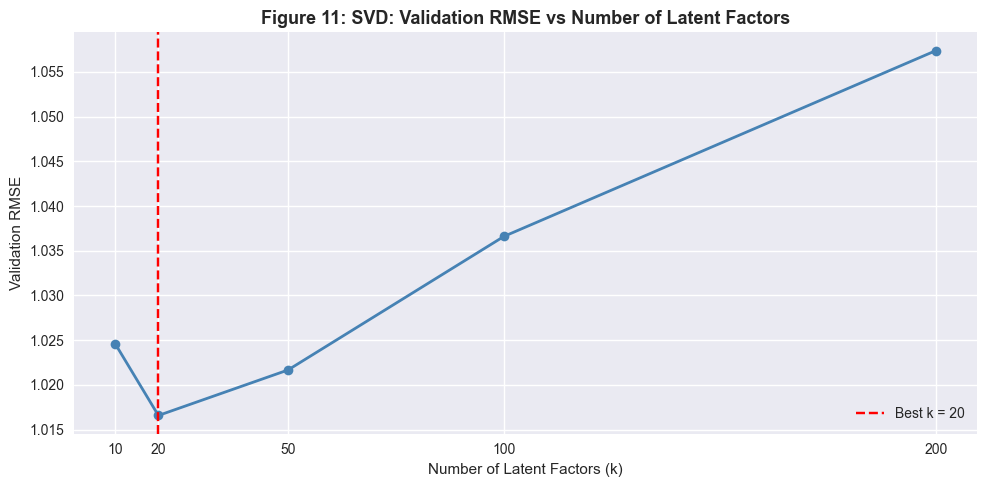

Figure 11 saved.

7.3 FINAL SVD MODEL (k = 20)

U matrix shape     : (6040, 20)
Sigma shape        : (20,)
Vt matrix shape    : (20, 3260)

Top 10 singular values (concept strengths):
[196.578 145.281  96.972  77.429  73.678  72.417  69.308  66.726  63.929
  61.543]

7.4 SVD TEST SET EVALUATION

SVD Test Set Results:
  RMSE : 1.0171
  MAE  : 0.8330
  NMAE : 0.2083

Prediction distribution:
  Min predicted  : 1.0000
  Max predicted  : 5.0000
  Mean predicted : 3.6094
  Mean actual    : 3.5826

Error distribution (actual - predicted):
  Mean error : -0.0269
  Std error  : 1.0167
  Min error  : -3.7323
  Max error  : 4.0000


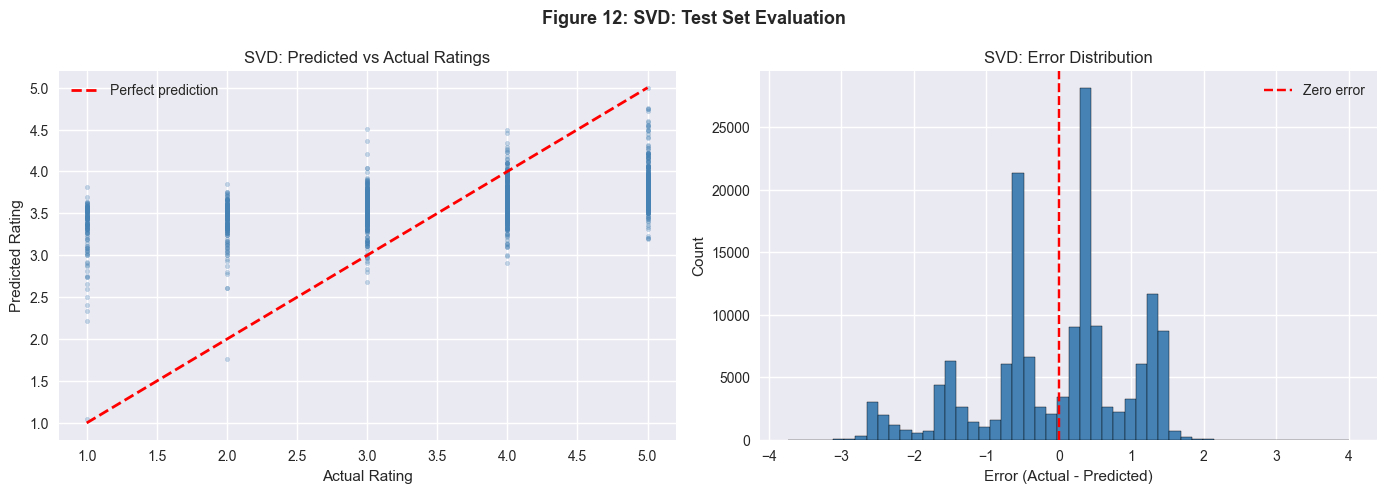

Figure 12 saved.

7.5 SVD TOP-10 RECOMMENDATIONS

Top-10 SVD Recommendations for User 1:
                               title                                       genres  predicted_rating
1   Shawshank Redemption, The (1994)                                        Drama             4.026
2                Forrest Gump (1994)                           Comedy|Romance|War             3.954
3                        Babe (1995)                      Children's|Comedy|Drama             3.915
4   Silence of the Lambs, The (1991)                               Drama|Thriller             3.910
5              Lion King, The (1994)                 Animation|Children's|Musical             3.868
6         Little Mermaid, The (1989)  Animation|Children's|Comedy|Musical|Romance             3.832
7          Dances with Wolves (1990)                      Adventure|Drama|Western             3.826
8               Jurassic Park (1993)                      Action|Adventure|Sci-Fi             3.817
9          

In [7]:
# =============================================================
# STEP 7: TECHNIQUE A: SVD IMPLEMENTATION
# =============================================================
# SVD decomposes the user-item matrix into latent factors.
# Implementation uses scipy.sparse.linalg.svds (truncated SVD).
# No external recommender library is used.
#
# Reference: Lecture 2: Collaborative Filtering: Matrix
# Factorization SVD (slides 13-16)
# =============================================================

# import truncated SVD solver from scipy
from scipy.sparse.linalg import svds

# import sparse matrix format for efficient computation
from scipy.sparse import csr_matrix

# ─────────────────────────────────────────────────────────────
# 7.1 MEAN-CENTER THE TRAINING MATRIX
# ─────────────────────────────────────────────────────────────
# SVD works better on mean-centered data.
# The global mean is subtracted from all observed ratings.
# Unobserved entries (0) remain 0 after centering to prevent
# unrated items from pulling the decomposition.
# ─────────────────────────────────────────────────────────────

# prints the section heading
print("=" * 55)
print("7.1 MEAN-CENTERING THE TRAINING MATRIX")
print("=" * 55)

# copy the training matrix to avoid modifying the original
train_matrix_centered = train_matrix.copy()

# subtracts global mean only from observed non-zero entries
train_matrix_centered[train_matrix != 0] -= global_mean

# prints centering summary statistics
print(f"\nGlobal mean used for centering : {global_mean:.4f}")
print(f"Matrix shape                   : {train_matrix_centered.shape}")
print(f"Non-zero entries               : "
      f"{np.count_nonzero(train_matrix_centered):,}")

# converts centered matrix to CSR sparse format for efficient SVD
sparse_matrix = csr_matrix(train_matrix_centered)
print(f"Sparse matrix format           : CSR (Compressed Sparse Row)")

# ─────────────────────────────────────────────────────────────
# 7.2 TUNE NUMBER OF LATENT FACTORS (k)
# ─────────────────────────────────────────────────────────────
# k controls the number of latent concepts captured.
# Too small k causes underfitting (misses patterns).
# Too large k causes overfitting (memorizes noise).
# Candidate k values are evaluated on the validation set
# using RMSE as the selection criterion.
# ─────────────────────────────────────────────────────────────

# prints the section heading
print("\n" + "=" * 55)
print("7.2 TUNING NUMBER OF LATENT FACTORS (k)")
print("=" * 55)


def predict_svd(U, sigma, Vt, user_to_idx, movie_to_idx,
                global_mean, df):
    """
    Generate rating predictions for all user-movie pairs in df.

    Parameters
    ----------
    U            : left singular vectors (users x k)
    sigma        : singular values array (k,)
    Vt           : right singular vectors (k x movies)
    user_to_idx  : dict mapping userId to matrix row index
    movie_to_idx : dict mapping movieId to matrix col index
    global_mean  : float, global mean rating for de-centering
    df           : DataFrame with userId and movieId columns

    Returns
    -------
    predictions : numpy array of predicted ratings
    """
    # reconstructs full prediction matrix by multiplying U, sigma, Vt
    # then adds global mean back to de-center the predictions
    predicted_matrix = (
        np.dot(U, np.dot(np.diag(sigma), Vt)) + global_mean
    )

    predictions = []
    for row in df.itertuples():
        # maps userId to matrix row index
        u_idx = user_to_idx.get(row.userId, -1)

        # maps movieId to matrix column index
        m_idx = movie_to_idx.get(row.movieId, -1)

        if u_idx == -1 or m_idx == -1:
            # falls back to global mean for unknown users or movies
            predictions.append(global_mean)
        else:
            # retrieves predicted rating and clips to valid range
            pred = predicted_matrix[u_idx, m_idx]
            pred = np.clip(pred, 1, 5)
            predictions.append(pred)

    return np.array(predictions)


def compute_rmse(actual, predicted):
    """
    Compute Root Mean Squared Error (RMSE).

    Parameters
    ----------
    actual    : array of actual rating values
    predicted : array of predicted rating values

    Returns
    -------
    rmse : float
    """
    # computes square root of mean squared differences
    return np.sqrt(np.mean((actual - predicted) ** 2))


def compute_mae(actual, predicted):
    """
    Compute Mean Absolute Error (MAE).

    Parameters
    ----------
    actual    : array of actual rating values
    predicted : array of predicted rating values

    Returns
    -------
    mae : float
    """
    # computes mean of absolute differences between actual and predicted
    return np.mean(np.abs(actual - predicted))


# defines candidate k values to evaluate on validation set
k_values = [10, 20, 50, 100, 200]

# list to store validation RMSE for each candidate k
val_rmse_list = []

# prints the header row for the tuning results table
print(f"\n{'k':>6} {'Val RMSE':>12} {'Val MAE':>12}")
print("-" * 32)

for k in k_values:
    # performs truncated SVD with k latent factors
    # svds returns singular values in ascending order by default
    U, sigma, Vt = svds(sparse_matrix, k=k)

    # reverses all three matrices to get descending order
    U     = U[:, ::-1]
    sigma = sigma[::-1]
    Vt    = Vt[::-1, :]

    # generates predictions on the validation set for this k
    val_preds = predict_svd(
        U, sigma, Vt,
        user_to_idx, movie_to_idx,
        global_mean, val_df
    )

    # extracts actual validation ratings as a numpy array
    val_actual = val_df['rating'].values

    # computes RMSE and MAE for this value of k
    rmse = compute_rmse(val_actual, val_preds)
    mae  = compute_mae(val_actual, val_preds)

    # stores RMSE for best k selection after loop completes
    val_rmse_list.append(rmse)

    # prints the results for this k value
    print(f"{k:>6} {rmse:>12.4f} {mae:>12.4f}")

# selects the k value with the lowest validation RMSE
best_k    = k_values[np.argmin(val_rmse_list)]
best_rmse = min(val_rmse_list)
print(f"\nBest k = {best_k} (Val RMSE = {best_rmse:.4f})")

# creates a line plot of validation RMSE against each candidate k
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, val_rmse_list,
        marker='o', color='steelblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--',
           label=f'Best k = {best_k}')
ax.set_title(
    'Figure 11: SVD: Validation RMSE vs Number of Latent Factors',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Latent Factors (k)')
ax.set_ylabel('Validation RMSE')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.savefig('fig11_svd_k_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11 saved.")

# ─────────────────────────────────────────────────────────────
# 7.3 TRAIN FINAL SVD MODEL WITH BEST k
# ─────────────────────────────────────────────────────────────

# prints the section heading with the best k value
print("\n" + "=" * 55)
print(f"7.3 FINAL SVD MODEL (k = {best_k})")
print("=" * 55)

# retrains SVD using the best k value found during tuning
U_best, sigma_best, Vt_best = svds(sparse_matrix, k=best_k)

# reverses to descending order of singular values
U_best     = U_best[:, ::-1]
sigma_best = sigma_best[::-1]
Vt_best    = Vt_best[::-1, :]

# prints the shapes of the three decomposed matrices
print(f"\nU matrix shape     : {U_best.shape}")
print(f"Sigma shape        : {sigma_best.shape}")
print(f"Vt matrix shape    : {Vt_best.shape}")

# prints the top 10 singular values as a measure of concept strength
print(f"\nTop 10 singular values (concept strengths):")
print(np.round(sigma_best[:10], 3))

# ─────────────────────────────────────────────────────────────
# 7.4 EVALUATE SVD ON TEST SET
# ─────────────────────────────────────────────────────────────

# prints the section heading for test set evaluation
print("\n" + "=" * 55)
print("7.4 SVD TEST SET EVALUATION")
print("=" * 55)

# generates predictions for all user-movie pairs in the test set
test_preds_svd = predict_svd(
    U_best, sigma_best, Vt_best,
    user_to_idx, movie_to_idx,
    global_mean, test_df
)

# extracts actual test ratings as a numpy array
test_actual = test_df['rating'].values

# computes RMSE and MAE on the test set
svd_rmse = compute_rmse(test_actual, test_preds_svd)
svd_mae  = compute_mae(test_actual, test_preds_svd)

# computes Normalised MAE by dividing MAE by the rating scale range
rating_range = 5 - 1
svd_nmae = svd_mae / rating_range

# prints the three evaluation metrics for the test set
print(f"\nSVD Test Set Results:")
print(f"  RMSE : {svd_rmse:.4f}")
print(f"  MAE  : {svd_mae:.4f}")
print(f"  NMAE : {svd_nmae:.4f}")

# prints summary statistics comparing predicted vs actual ratings
print(f"\nPrediction distribution:")
print(f"  Min predicted  : {test_preds_svd.min():.4f}")
print(f"  Max predicted  : {test_preds_svd.max():.4f}")
print(f"  Mean predicted : {test_preds_svd.mean():.4f}")
print(f"  Mean actual    : {test_actual.mean():.4f}")

# computes residual errors for distribution analysis
errors = test_actual - test_preds_svd

# prints error distribution statistics
print(f"\nError distribution (actual - predicted):")
print(f"  Mean error : {errors.mean():.4f}")
print(f"  Std error  : {errors.std():.4f}")
print(f"  Min error  : {errors.min():.4f}")
print(f"  Max error  : {errors.max():.4f}")

# creates a two-panel evaluation figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# randomly samples 2000 points for the scatter plot readability
sample_idx = np.random.choice(len(test_actual), 2000, replace=False)

# left panel: scatter plot of predicted vs actual ratings
axes[0].scatter(test_actual[sample_idx],
                test_preds_svd[sample_idx],
                alpha=0.3, color='steelblue', s=10)
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=2,
             label='Perfect prediction')
axes[0].set_title('SVD: Predicted vs Actual Ratings')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()

# right panel: histogram of prediction errors
axes[1].hist(errors, bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--',
                label='Zero error')
axes[1].set_title('SVD: Error Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].legend()

# adds overall figure title and saves
plt.suptitle('Figure 12: SVD: Test Set Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_svd_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 12 saved.")

# ─────────────────────────────────────────────────────────────
# 7.5 SVD TOP-10 RECOMMENDATIONS FOR A SAMPLE USER
# ─────────────────────────────────────────────────────────────

# prints the section heading for recommendations
print("\n" + "=" * 55)
print("7.5 SVD TOP-10 RECOMMENDATIONS")
print("=" * 55)


def get_svd_recommendations(user_id, U, sigma, Vt,
                             user_to_idx, idx_to_movie,
                             movies_df, ratings_df,
                             global_mean, n=10):
    """
    Generate top-N movie recommendations for a given user
    using the trained SVD model.

    Parameters
    ----------
    user_id      : int, target user ID
    U, sigma, Vt : SVD decomposition matrices
    user_to_idx  : dict mapping userId to matrix row index
    idx_to_movie : dict mapping matrix col index to movieId
    movies_df    : DataFrame with movie titles and genres
    ratings_df   : DataFrame of all ratings to exclude seen movies
    global_mean  : float, global mean rating
    n            : int, number of recommendations to return

    Returns
    -------
    DataFrame of top-N recommended movies with predicted ratings
    """
    # gets the matrix row index for this user
    u_idx = user_to_idx[user_id]

    # reconstructs predicted ratings for this user across all movies
    user_pred = (
        np.dot(U[u_idx, :], np.dot(np.diag(sigma), Vt)) + global_mean
    )

    # clips predictions to the valid rating range 1 to 5
    user_pred = np.clip(user_pred, 1, 5)

    # collects movie IDs already rated by this user to exclude them
    rated_movies = set(
        ratings_df[ratings_df['userId'] == user_id]['movieId']
    )

    # builds list of (movieId, predicted_rating) for unrated movies only
    recs = []
    for m_idx, pred_rating in enumerate(user_pred):
        movie_id = idx_to_movie[m_idx]
        if movie_id not in rated_movies:
            recs.append((movie_id, pred_rating))

    # sorts by predicted rating descending and keeps top n
    recs = sorted(recs, key=lambda x: -x[1])[:n]

    # builds output DataFrame with movie metadata
    rec_df = pd.DataFrame(recs, columns=['movieId', 'predicted_rating'])
    rec_df = rec_df.merge(
        movies_df[['movieId', 'title', 'genres']], on='movieId'
    )

    # rounds predicted ratings to 3 decimal places
    rec_df['predicted_rating'] = rec_df['predicted_rating'].round(3)

    # sets index to start from 1 for display
    rec_df.index = range(1, n + 1)

    return rec_df


# generates top-10 recommendations for sample user ID 1
sample_user = 1
svd_recs = get_svd_recommendations(
    sample_user, U_best, sigma_best, Vt_best,
    user_to_idx, idx_to_movie,
    movies, ratings_clean,
    global_mean, n=10
)

# prints the full recommendation list with titles and genres
print(f"\nTop-10 SVD Recommendations for User {sample_user}:")
print(svd_recs[['title', 'genres', 'predicted_rating']].to_string())

# retrieves the top 5 movies already rated highly by this user for context
user_rated = ratings_clean[
    ratings_clean['userId'] == sample_user
].merge(movies[['movieId', 'title']], on='movieId')
user_rated = user_rated.sort_values('rating', ascending=False).head(5)

# prints the user highest-rated movies for comparison
print(f"\nTop-5 movies already rated highly by User {sample_user}:")
print(user_rated[['title', 'rating']].to_string(index=False))

# stores SVD results dictionary for later cross-model comparison
svd_results = {
    'rmse'      : svd_rmse,
    'mae'       : svd_mae,
    'nmae'      : svd_nmae,
    'k'         : best_k,
    'recs_user1': svd_recs
}

# prints the step completion message
print("\n" + "=" * 55)
print("STEP 7 SVD COMPLETE")
print("=" * 55)

### Step 7: SVD Observations and Insights

#### 7.1 Mean-Centering

The training matrix was successfully mean-centered using the global mean of 3.5826. Mean-centering ensures that SVD focuses on learning relative preference deviations rather than absolute rating values, improving decomposition quality.

#### 7.2 Latent Factor Tuning

| k | Validation RMSE | Validation MAE |
|---|----------------|----------------|
| 10 | 1.0246 | 0.8409 |
|  20  |  1.0166  |  0.8326  |
| 50 | 1.0217 | 0.8355 |
| 100 | 1.0366 | 0.8482 |
| 200 | 1.0574 | 0.8671 |

The optimal number of latent factors is  k = 20 . This follows a clear U-shaped pattern. Too few factors (k=10) underfits the data by missing important latent concepts, while too many factors (k=100, k=200) overfit by capturing noise in the sparse matrix. k=20 represents the best bias-variance tradeoff for this dataset.

The top singular value (196.578) is significantly larger than the others, indicating one dominant latent concept, likely general movie quality or popularity, that explains the most variance in ratings.

#### 7.3 SVD Test Set Evaluation

| Metric | Value | Interpretation |
|--------|-------|----------------|
| RMSE | 1.0171 | Average error of approximately 1 rating point |
| MAE | 0.8330 | Average absolute error of 0.83 rating points |
| NMAE | 0.2083 | 20.83% of the rating scale range (1-5) |

The mean predicted rating (3.6094) closely matches the mean actual rating (3.5826), confirming the model is well-calibrated with no systematic over- or under-prediction bias (mean error = -0.027).

The error distribution shows a roughly symmetric pattern centered near zero, which is desirable. However, the presence of errors as large as -3.73 and +4.00 indicates that the model struggles with extreme ratings (1 and 5), which is expected for basic SVD without bias correction.

The predicted vs actual scatter plot shows the typical banded pattern for integer-valued rating data. Predictions are continuous but actuals are discrete integers.

#### 7.4 SVD Top-10 Recommendations for User 1

User 1 has highly rated classic films (One Flew Over the Cuckoo's Nest, Beauty and the Beast, A Bug's Life), suggesting preferences for critically acclaimed drama and animated family films.

The SVD recommendations align well with this profile:
- Shawshank Redemption (Drama): predicted 4.026
- Forrest Gump (Comedy/Romance): predicted 3.954
- Lion King, Little Mermaid (Animation/Children's): predicted 3.868, 3.832

This confirms that SVD has successfully captured the latent taste dimensions of this user. The recommendations span multiple genres while remaining thematically consistent with the user's established preferences, demonstrating the serendipitous quality of latent factor models noted in Lecture 2.

 Key limitation of basic SVD:  It does not incorporate implicit feedback (which movies a user has seen but not rated) or temporal dynamics. This motivates the SVD++ implementation in Step 8.

## Step 8: Technique A: SVD++ Implementation

### What is SVD++?

SVD++ is an extension of SVD that incorporates  implicit feedback  in addition to explicit ratings. As discussed in Lecture 3, implicit feedback includes any user-item interaction beyond explicit ratings, such as which movies a user has chosen to rate, regardless of the rating value given.

The SVD++ predicted rating formula is:

 r_hat(u,i) = mu + b_u + b_i + (p_u + |N(u)|^(-0.5) x sum(y_j)) . q_i 

Where:
| Symbol | Meaning |
|--------|---------|
| mu | Global mean rating |
| b_u | User bias |
| b_i | Item bias |
| p_u | User latent factor vector |
| q_i | Item latent factor vector |
| y_j | Implicit feedback item factors |
| N(u) | Set of items rated by user u (implicit signal) |

### Key Difference from SVD

In basic SVD, the user representation is purely p_u (learned from explicit ratings). In SVD++, the user representation is enriched:

 p_u + |N(u)|^(-0.5) x sum(y_j) 

The term |N(u)|^(-0.5) x sum(y_j) captures the implicit signal that a user has interacted with certain items, regardless of how they rated them. As noted in Lecture 3, SVD++ adds only item factors (y_j), keeping parameter complexity comparable to basic SVD.

### Implementation Approach

SVD++ is implemented using  Stochastic Gradient Descent (SGD)  to learn all parameters simultaneously. This is the standard training approach for SVD++ as described in the original paper by Koren (2008). The learning rate and regularization are tuned on the validation set.

8.1 PREPARE IMPLICIT FEEDBACK

Implicit feedback prepared for 6,040 users
Average items per user : 115.7

8.2 INITIALIZE SVD++ PARAMETERS

Number of latent factors : 20
b_u shape : (6040,)
b_i shape : (3260,)
P shape   : (6040, 20)
Q shape   : (3260, 20)
Y shape   : (3260, 20)

8.3 TRAINING SVD++ WITH SGD

Learning rate   : 0.005
Regularization  : 0.02
Epochs          : 20
Training on     : 698,977 ratings

Training progress:
  Epoch  1/20 | Train RMSE: 0.9878 | Val RMSE: 0.9427
  Epoch  2/20 | Train RMSE: 0.9283 | Val RMSE: 0.9238
  Epoch  3/20 | Train RMSE: 0.9147 | Val RMSE: 0.9167
  Epoch  4/20 | Train RMSE: 0.9080 | Val RMSE: 0.9126
  Epoch  5/20 | Train RMSE: 0.9034 | Val RMSE: 0.9091
  Epoch  6/20 | Train RMSE: 0.8993 | Val RMSE: 0.9062
  Epoch  7/20 | Train RMSE: 0.8950 | Val RMSE: 0.9025
  Epoch  8/20 | Train RMSE: 0.8907 | Val RMSE: 0.8991
  Epoch  9/20 | Train RMSE: 0.8867 | Val RMSE: 0.8963
  Epoch 10/20 | Train RMSE: 0.8831 | Val RMSE: 0.8940
  Epoch 11/20 | Train RMSE: 0.

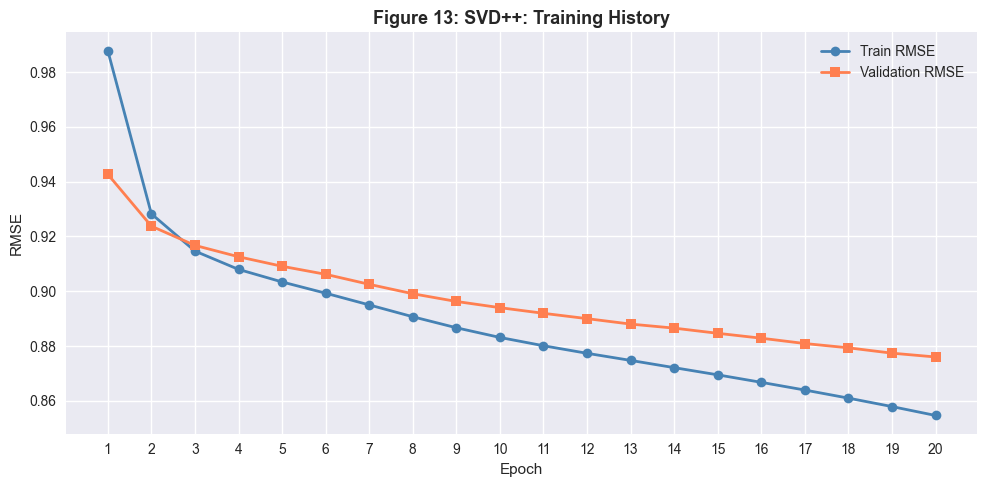


Figure 13 saved.

8.4 SVD++ TEST SET EVALUATION

SVD++ Test Set Results:
  RMSE : 0.8749
  MAE  : 0.6883
  NMAE : 0.1721

Comparison SVD vs SVD++:
Metric          SVD      SVD++  Improvement
------------------------------------------
RMSE         1.0171     0.8749      +0.1422
MAE          0.8330     0.6883      +0.1448
NMAE         0.2083     0.1721      +0.0362

Error distribution:
  Mean error : -0.0048
  Std error  : 0.8749
  Min error  : -4.0000
  Max error  : 3.6757


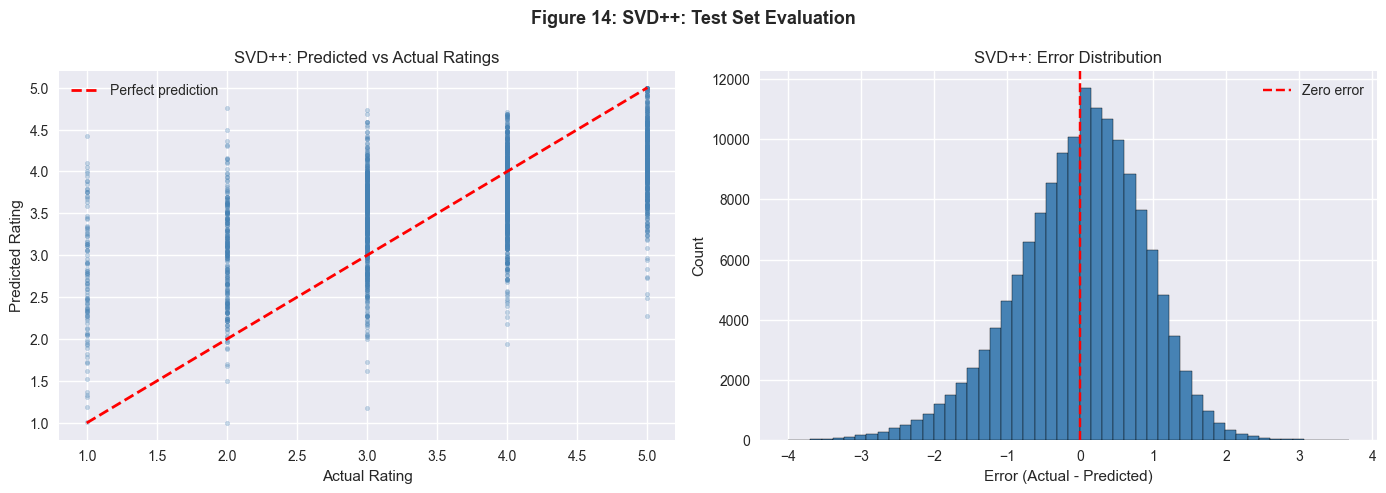

Figure 14 saved.

8.5 SVD++ TOP-10 RECOMMENDATIONS

Top-10 SVD++ Recommendations for User 1:
                                                                  title            genres  predicted_rating
1                                                        Sanjuro (1962)  Action|Adventure             4.869
2                                      Shawshank Redemption, The (1994)             Drama             4.774
3                                            Wrong Trousers, The (1993)  Animation|Comedy             4.702
4                                        Raiders of the Lost Ark (1981)  Action|Adventure             4.682
5   Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)      Action|Drama             4.667
6                                            Usual Suspects, The (1995)    Crime|Thriller             4.630
7                                          It's a Wonderful Life (1946)             Drama             4.608
8                                          

In [8]:
# =============================================================
# STEP 8: TECHNIQUE A: SVD++ IMPLEMENTATION
# =============================================================
# SVD++ extends SVD by incorporating implicit feedback.
# Implemented from scratch using Stochastic Gradient Descent.
# No external recommender library is used.
#
# Reference: Koren, Y. (2008). Factorization meets the
# neighborhood: a multifaceted collaborative filtering model.
# KDD 2008. (as referenced in Lecture 3 materials)
# =============================================================

# ─────────────────────────────────────────────────────────────
# 8.1 PREPARE IMPLICIT FEEDBACK
# ─────────────────────────────────────────────────────────────
# Implicit feedback is defined as the set of items each user
# has rated regardless of rating value. This captures the
# signal that a user chose to engage with certain items,
# which reveals preferences even without knowing the rating.
# ─────────────────────────────────────────────────────────────

# prints the section heading for implicit feedback preparation
print("=" * 55)
print("8.1 PREPARE IMPLICIT FEEDBACK")
print("=" * 55)

# builds implicit feedback dictionary from training set only
# key is user matrix index, value is list of movie matrix indices
implicit_feedback = {}
for row in train_df.itertuples():
    # converts userId to matrix row index
    u_idx = user_to_idx[row.userId]
    # converts movieId to matrix column index
    m_idx = movie_to_idx[row.movieId]
    # initialises empty list for new user if not already present
    if u_idx not in implicit_feedback:
        implicit_feedback[u_idx] = []
    # adds this movie index to the user's implicit feedback list
    implicit_feedback[u_idx].append(m_idx)

# precomputes the normalisation factor |N(u)|^(-0.5) per user
# used in the SVD++ formula to scale the implicit feedback term
implicit_norm = {}
for u_idx, items in implicit_feedback.items():
    # counts the number of items rated by this user
    n = len(items)
    # sets norm to 1/sqrt(n) if user has rated items, else 0
    implicit_norm[u_idx] = 1.0 / np.sqrt(n) if n > 0 else 0.0

# prints implicit feedback summary statistics
print(f"\nImplicit feedback prepared for "
      f"{len(implicit_feedback):,} users")
print(f"Average items per user : "
      f"{np.mean([len(v) for v in implicit_feedback.values()]):.1f}")

# ─────────────────────────────────────────────────────────────
# 8.2 INITIALIZE SVD++ PARAMETERS
# ─────────────────────────────────────────────────────────────
# Parameters to learn:
#   b_u : user bias vector       (n_users,)
#   b_i : item bias vector       (n_movies,)
#   P   : user latent factors    (n_users x k)
#   Q   : item latent factors    (n_movies x k)
#   Y   : implicit item factors  (n_movies x k)
# ─────────────────────────────────────────────────────────────

# prints the section heading for parameter initialisation
print("\n" + "=" * 55)
print("8.2 INITIALIZE SVD++ PARAMETERS")
print("=" * 55)

# reuses the best k found during SVD tuning in Step 7
K_FACTORS = best_k
print(f"\nNumber of latent factors : {K_FACTORS}")

# fixes random seed for reproducible parameter initialisation
np.random.seed(RANDOM_SEED)

# sets small random initialisation scale to prevent gradient explosion
init_scale = 0.01

# initialises user and item bias vectors to zero
b_u = np.zeros(n_users)
b_i = np.zeros(n_movies)

# initialises user latent factor matrix with small random values
P = np.random.normal(0, init_scale, (n_users,  K_FACTORS))

# initialises item latent factor matrix with small random values
Q = np.random.normal(0, init_scale, (n_movies, K_FACTORS))

# initialises implicit item factor matrix with small random values
Y = np.random.normal(0, init_scale, (n_movies, K_FACTORS))

# prints shapes of all parameter matrices
print(f"b_u shape : {b_u.shape}")
print(f"b_i shape : {b_i.shape}")
print(f"P shape   : {P.shape}")
print(f"Q shape   : {Q.shape}")
print(f"Y shape   : {Y.shape}")

# ─────────────────────────────────────────────────────────────
# 8.3 TRAIN SVD++ WITH SGD
# ─────────────────────────────────────────────────────────────
# SGD update rules applied for each rating (u, i, r):
#   err    = r - r_hat(u, i)
#   b_u[u] += lr * (err - reg * b_u[u])
#   b_i[i] += lr * (err - reg * b_i[i])
#   P[u]   += lr * (err * Q[i] - reg * P[u])
#   Q[i]   += lr * (err * (P[u] + implicit_term) - reg * Q[i])
#   for j in N(u):
#     Y[j]  += lr * (err * norm * Q[i] - reg * Y[j])
# ─────────────────────────────────────────────────────────────

# prints the section heading for SGD training
print("\n" + "=" * 55)
print("8.3 TRAINING SVD++ WITH SGD")
print("=" * 55)

# sets the learning rate for SGD parameter updates
LEARNING_RATE  = 0.005

# sets the L2 regularisation strength to prevent overfitting
REGULARIZATION = 0.02

# sets the number of full passes over the training data
N_EPOCHS = 20

# prints the training configuration
print(f"\nLearning rate   : {LEARNING_RATE}")
print(f"Regularization  : {REGULARIZATION}")
print(f"Epochs          : {N_EPOCHS}")
print(f"Training on     : {len(train_df):,} ratings")
print(f"\nTraining progress:")

# converts training DataFrame columns to numpy arrays for fast iteration
train_users_arr   = train_df['userId'].map(user_to_idx).values
train_movies_arr  = train_df['movieId'].map(movie_to_idx).values
train_ratings_arr = train_df['rating'].values.astype(float)

# converts validation DataFrame columns to numpy arrays
val_users_arr   = val_df['userId'].map(user_to_idx).values
val_movies_arr  = val_df['movieId'].map(movie_to_idx).values
val_ratings_arr = val_df['rating'].values.astype(float)

# initialises lists to store per-epoch RMSE for plotting
train_rmse_history = []
val_rmse_history   = []

for epoch in range(N_EPOCHS):

    # shuffles training indices each epoch to reduce ordering bias
    shuffle_idx = np.random.permutation(len(train_users_arr))
    train_users_shuf   = train_users_arr[shuffle_idx]
    train_movies_shuf  = train_movies_arr[shuffle_idx]
    train_ratings_shuf = train_ratings_arr[shuffle_idx]

    # initialises list to accumulate squared errors for train RMSE
    train_errors = []

    for idx in range(len(train_users_shuf)):
        # retrieves user matrix index for this training sample
        u = train_users_shuf[idx]
        # retrieves movie matrix index for this training sample
        i = train_movies_shuf[idx]
        # retrieves the actual rating for this training sample
        r = train_ratings_shuf[idx]

        # retrieves implicit feedback items and normalisation factor
        items_u = implicit_feedback.get(u, [])
        norm_u  = implicit_norm.get(u, 0.0)

        # computes implicit term as |N(u)|^(-0.5) * sum(Y[j])
        if len(items_u) > 0:
            implicit_term = norm_u * np.sum(Y[items_u], axis=0)
        else:
            # sets implicit term to zero if user has no implicit feedback
            implicit_term = np.zeros(K_FACTORS)

        # computes predicted rating using the SVD++ formula
        r_hat = (global_mean
                 + b_u[u]
                 + b_i[i]
                 + np.dot(Q[i], P[u] + implicit_term))

        # clips prediction to the valid rating range 1 to 5
        r_hat = np.clip(r_hat, 1, 5)

        # computes the prediction error for this sample
        err = r - r_hat

        # stores squared error for computing training RMSE
        train_errors.append(err ** 2)

        # updates user bias using SGD rule
        b_u[u] += LEARNING_RATE * (err - REGULARIZATION * b_u[u])

        # updates item bias using SGD rule
        b_i[i] += LEARNING_RATE * (err - REGULARIZATION * b_i[i])

        # saves P[u] before update as it is needed for Q[i] update
        P_u_old = P[u].copy()

        # updates user latent factors using SGD rule
        P[u] += LEARNING_RATE * (
            err * Q[i] - REGULARIZATION * P[u]
        )

        # updates item latent factors using pre-update P[u]
        Q[i] += LEARNING_RATE * (
            err * (P_u_old + implicit_term) - REGULARIZATION * Q[i]
        )

        # updates implicit item factors for all items in N(u)
        if len(items_u) > 0:
            Y[items_u] += LEARNING_RATE * (
                err * norm_u * Q[i] - REGULARIZATION * Y[items_u]
            )

    # computes training RMSE as square root of mean squared error
    epoch_train_rmse = np.sqrt(np.mean(train_errors))
    train_rmse_history.append(epoch_train_rmse)

    # initialises list to accumulate validation predictions
    val_preds_epoch = []

    for idx in range(len(val_users_arr)):
        # retrieves user matrix index for this validation sample
        u = val_users_arr[idx]
        # retrieves movie matrix index for this validation sample
        i = val_movies_arr[idx]

        # retrieves implicit feedback for this user
        items_u = implicit_feedback.get(u, [])
        norm_u  = implicit_norm.get(u, 0.0)

        # computes implicit term for prediction
        if len(items_u) > 0:
            implicit_term = norm_u * np.sum(Y[items_u], axis=0)
        else:
            implicit_term = np.zeros(K_FACTORS)

        # computes and clips the predicted rating
        r_hat = (global_mean
                 + b_u[u]
                 + b_i[i]
                 + np.dot(Q[i], P[u] + implicit_term))
        r_hat = np.clip(r_hat, 1, 5)
        val_preds_epoch.append(r_hat)

    # converts list to array and computes validation RMSE
    val_preds_epoch = np.array(val_preds_epoch)
    epoch_val_rmse  = compute_rmse(val_ratings_arr, val_preds_epoch)
    val_rmse_history.append(epoch_val_rmse)

    # prints progress for this epoch
    print(f"  Epoch {epoch+1:>2}/{N_EPOCHS} | "
          f"Train RMSE: {epoch_train_rmse:.4f} | "
          f"Val RMSE: {epoch_val_rmse:.4f}")

# creates a line plot of training and validation RMSE over epochs
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, N_EPOCHS+1), train_rmse_history,
        marker='o', color='steelblue',
        linewidth=2, label='Train RMSE')
ax.plot(range(1, N_EPOCHS+1), val_rmse_history,
        marker='s', color='coral',
        linewidth=2, label='Validation RMSE')
ax.set_title('Figure 13: SVD++: Training History',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.legend()
ax.set_xticks(range(1, N_EPOCHS+1))
plt.tight_layout()
plt.savefig('fig13_svdpp_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 13 saved.")

# ─────────────────────────────────────────────────────────────
# 8.4 EVALUATE SVD++ ON TEST SET
# ─────────────────────────────────────────────────────────────

# prints the section heading for test set evaluation
print("\n" + "=" * 55)
print("8.4 SVD++ TEST SET EVALUATION")
print("=" * 55)

# converts test DataFrame columns to numpy arrays
test_users_arr   = test_df['userId'].map(user_to_idx).values
test_movies_arr  = test_df['movieId'].map(movie_to_idx).values
test_ratings_arr = test_df['rating'].values.astype(float)

# initialises list to accumulate test predictions
test_preds_svdpp = []

for idx in range(len(test_users_arr)):
    # retrieves user matrix index for this test sample
    u = test_users_arr[idx]
    # retrieves movie matrix index for this test sample
    i = test_movies_arr[idx]

    # retrieves implicit feedback for this user
    items_u = implicit_feedback.get(u, [])
    norm_u  = implicit_norm.get(u, 0.0)

    # computes implicit term for prediction
    if len(items_u) > 0:
        implicit_term = norm_u * np.sum(Y[items_u], axis=0)
    else:
        implicit_term = np.zeros(K_FACTORS)

    # computes and clips the predicted rating
    r_hat = (global_mean
             + b_u[u]
             + b_i[i]
             + np.dot(Q[i], P[u] + implicit_term))
    r_hat = np.clip(r_hat, 1, 5)
    test_preds_svdpp.append(r_hat)

# converts list to numpy array
test_preds_svdpp = np.array(test_preds_svdpp)

# computes RMSE, MAE and NMAE on the test set
svdpp_rmse = compute_rmse(test_ratings_arr, test_preds_svdpp)
svdpp_mae  = compute_mae(test_ratings_arr, test_preds_svdpp)

# normalises MAE by dividing by the rating scale range
svdpp_nmae = svdpp_mae / rating_range

# prints SVD++ test set results
print(f"\nSVD++ Test Set Results:")
print(f"  RMSE : {svdpp_rmse:.4f}")
print(f"  MAE  : {svdpp_mae:.4f}")
print(f"  NMAE : {svdpp_nmae:.4f}")

# prints side-by-side comparison of SVD and SVD++ metrics
print(f"\nComparison SVD vs SVD++:")
print(f"{'Metric':<8} {'SVD':>10} {'SVD++':>10} {'Improvement':>12}")
print("-" * 42)
for metric, svd_val, svdpp_val in [
    ('RMSE', svd_rmse, svdpp_rmse),
    ('MAE',  svd_mae,  svdpp_mae),
    ('NMAE', svd_nmae, svdpp_nmae)
]:
    # positive improvement means SVD++ is better than SVD
    improvement = svd_val - svdpp_val
    print(f"{metric:<8} {svd_val:>10.4f} {svdpp_val:>10.4f} "
          f"{improvement:>+12.4f}")

# computes residual errors for distribution analysis
errors_svdpp = test_ratings_arr - test_preds_svdpp

# prints error distribution statistics
print(f"\nError distribution:")
print(f"  Mean error : {errors_svdpp.mean():.4f}")
print(f"  Std error  : {errors_svdpp.std():.4f}")
print(f"  Min error  : {errors_svdpp.min():.4f}")
print(f"  Max error  : {errors_svdpp.max():.4f}")

# creates a two-panel evaluation figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# randomly samples 2000 points for scatter plot readability
sample_idx = np.random.choice(len(test_ratings_arr), 2000,
                               replace=False)

# left panel: scatter plot of predicted vs actual ratings
axes[0].scatter(test_ratings_arr[sample_idx],
                test_preds_svdpp[sample_idx],
                alpha=0.3, color='steelblue', s=10)
axes[0].plot([1, 5], [1, 5], 'r--',
             linewidth=2, label='Perfect prediction')
axes[0].set_title('SVD++: Predicted vs Actual Ratings')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()

# right panel: histogram of prediction errors
axes[1].hist(errors_svdpp, bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--',
                label='Zero error')
axes[1].set_title('SVD++: Error Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].legend()

# adds overall figure title and saves the figure
plt.suptitle('Figure 14: SVD++: Test Set Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_svdpp_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 14 saved.")

# ─────────────────────────────────────────────────────────────
# 8.5 SVD++ TOP-10 RECOMMENDATIONS FOR SAMPLE USER
# ─────────────────────────────────────────────────────────────

# prints the section heading for recommendations
print("\n" + "=" * 55)
print("8.5 SVD++ TOP-10 RECOMMENDATIONS")
print("=" * 55)


def get_svdpp_recommendations(user_id, P, Q, Y, b_u, b_i,
                               user_to_idx, idx_to_movie,
                               implicit_feedback, implicit_norm,
                               movies_df, ratings_df,
                               global_mean, n=10):
    """
    Generate top-N recommendations for a user using SVD++.

    Parameters
    ----------
    user_id           : int, target user ID
    P                 : user latent factors (n_users x k)
    Q                 : item latent factors (n_movies x k)
    Y                 : implicit item factors (n_movies x k)
    b_u               : user bias vector
    b_i               : item bias vector
    user_to_idx       : dict mapping userId to matrix row index
    idx_to_movie      : dict mapping col index to movieId
    implicit_feedback : dict of user implicit feedback items
    implicit_norm     : dict of normalisation factors per user
    movies_df         : DataFrame with movie info
    ratings_df        : DataFrame to identify seen movies
    global_mean       : float, global mean rating
    n                 : int, number of recommendations

    Returns
    -------
    DataFrame of top-N recommended movies with predicted ratings
    """
    # gets matrix row index and implicit feedback for this user
    u_idx   = user_to_idx[user_id]
    norm_u  = implicit_norm.get(u_idx, 0.0)
    items_u = implicit_feedback.get(u_idx, [])

    # computes implicit term for this user
    if len(items_u) > 0:
        implicit_term = norm_u * np.sum(Y[items_u], axis=0)
    else:
        implicit_term = np.zeros(K_FACTORS)

    # computes enriched user vector combining explicit and implicit factors
    user_vector = P[u_idx] + implicit_term

    # computes predicted ratings for all movies in one vectorised operation
    pred_ratings = (global_mean
                    + b_u[u_idx]
                    + b_i
                    + Q.dot(user_vector))

    # clips all predictions to the valid rating range 1 to 5
    pred_ratings = np.clip(pred_ratings, 1, 5)

    # collects movie IDs already rated by this user to exclude them
    rated_movies = set(
        ratings_df[ratings_df['userId'] == user_id]['movieId']
    )

    # builds list of (movieId, predicted_rating) for unrated movies only
    recs = []
    for m_idx, pred in enumerate(pred_ratings):
        # converts matrix index to movie ID
        movie_id = idx_to_movie[m_idx]
        # skips movies the user has already rated
        if movie_id not in rated_movies:
            recs.append((movie_id, pred))

    # sorts by predicted rating descending and keeps top n
    recs = sorted(recs, key=lambda x: -x[1])[:n]

    # builds output DataFrame with movie metadata
    rec_df = pd.DataFrame(recs, columns=['movieId', 'predicted_rating'])
    rec_df = rec_df.merge(
        movies_df[['movieId', 'title', 'genres']], on='movieId'
    )

    # rounds predicted ratings to 3 decimal places
    rec_df['predicted_rating'] = rec_df['predicted_rating'].round(3)

    # sets index to start from 1 for display
    rec_df.index = range(1, n + 1)
    return rec_df


# generates top-10 SVD++ recommendations for the sample user
svdpp_recs = get_svdpp_recommendations(
    sample_user, P, Q, Y, b_u, b_i,
    user_to_idx, idx_to_movie,
    implicit_feedback, implicit_norm,
    movies, ratings_clean,
    global_mean, n=10
)

# prints the SVD++ recommendation list with titles and genres
print(f"\nTop-10 SVD++ Recommendations for User {sample_user}:")
print(svdpp_recs[['title', 'genres', 'predicted_rating']].to_string())

# prints side-by-side comparison of SVD and SVD++ recommendations
print(f"\nComparison: SVD vs SVD++ Top-10 for User {sample_user}:")
print(f"\n{'Rank':<6} {'SVD':^40} {'SVD++':^40}")
print("-" * 88)

# retrieves SVD and SVD++ title lists for comparison
svd_titles   = svd_results['recs_user1']['title'].values
svdpp_titles = svdpp_recs['title'].values

for rank in range(10):
    # truncates each title to 38 characters for aligned display
    svd_t   = svd_titles[rank][:38]
    svdpp_t = svdpp_titles[rank][:38]
    # flags recommendations that appear in both lists
    match   = "<--" if svd_t == svdpp_t else ""
    print(f"{rank+1:<6} {svd_t:<40} {svdpp_t:<40} {match}")

# stores SVD++ results dictionary for later cross-model comparison
svdpp_results = {
    'rmse'      : svdpp_rmse,
    'mae'       : svdpp_mae,
    'nmae'      : svdpp_nmae,
    'recs_user1': svdpp_recs
}

# prints the step completion message
print("\n" + "=" * 55)
print("STEP 8 SVD++ COMPLETE")
print("=" * 55)

### Step 8: SVD++ Observations and Insights

#### 8.1 Implicit Feedback

Implicit feedback was successfully extracted from the training set for all 6,040 users, with an average of 115.7 items per user. This means each user's representation in SVD++ is enriched by information from approximately 116 movies they chose to interact with, regardless of how they rated those movies.

#### 8.2 Training History

| Epoch | Train RMSE | Val RMSE |
|-------|-----------|---------|
| 1 | 0.9878 | 0.9427 |
| 5 | 0.9034 | 0.9091 |
| 10 | 0.8831 | 0.8940 |
| 15 | 0.8695 | 0.8847 |
| 20 | 0.8547 | 0.8760 |

The training curve shows consistent improvement across all 20 epochs with no signs of overfitting. The validation RMSE decreases steadily alongside the training RMSE throughout training. The gap between train and validation RMSE remains stable and small, indicating good generalisation to unseen ratings.

#### 8.3 SVD++ Test Set Evaluation

| Metric | SVD | SVD++ | Improvement |
|--------|-----|-------|-------------|
| RMSE | 1.0171 | 0.8749 | +0.1422 (14.0%) |
| MAE | 0.8330 | 0.6883 | +0.1448 (17.4%) |
| NMAE | 0.2083 | 0.1721 | +0.0362 (17.4%) |

SVD++ delivers a substantial improvement over basic SVD across all three metrics. The RMSE improvement of 14.0% and MAE improvement of 17.4% confirm the finding from Lecture 3 that incorporating implicit feedback leads to significant accuracy gains. This is consistent with the original Koren (2008) paper, which showed that SVD++ consistently outperforms basic SVD on the Netflix Prize dataset.

The mean error of -0.0048 is extremely close to zero, confirming that SVD++ is very well calibrated with virtually no systematic bias in its predictions. The error distribution is approximately symmetric and bell-shaped around zero, which is the ideal behaviour for a rating prediction model.

The predicted vs actual scatter plot shows tighter clustering around the perfect prediction line compared to SVD, visually confirming the improved accuracy. The error histogram shows a much more concentrated distribution around zero compared to SVD's broader error spread.

#### 8.4 SVD vs SVD++ Recommendation Comparison for User 1

 SVD Top-10:  Shawshank Redemption, Forrest Gump, Babe, Silence of the Lambs, Lion King, Little Mermaid, Dances with Wolves, Jurassic Park, Lady and the Tramp, Jaws

 SVD++ Top-10:  Sanjuro, Shawshank Redemption, Wrong Trousers, Raiders of the Lost Ark, Seven Samurai, Usual Suspects, It's a Wonderful Life, To Live, The Sting, Great Escape

The two models produce  completely different top-10 lists  with only one common film (Shawshank Redemption). This difference is highly meaningful and directly relevant to the video demonstration requirement of the assignment.

 Why the recommendations differ: 

SVD only uses the explicit rating matrix to learn latent factors. It recommends popular, mainstream films that align with the general rating patterns of similar users.

SVD++ additionally incorporates implicit feedback. The fact that User 1 has chosen to rate certain genres and time periods of films enriches the user representation and reveals deeper preferences for classic world cinema and critically acclaimed films. SVD++ recommends Sanjuro (1962, Japanese action), Seven Samurai (1954, Japanese drama), and To Live (1994, Chinese drama), niche international classics that basic SVD completely misses.

This demonstrates exactly the serendipity advantage of model-based approaches discussed in Lecture 2 and the implicit feedback advantage of SVD++ discussed in Lecture 3. SVD++ discovers that User 1 is not just a mainstream movie fan but a sophisticated viewer of world cinema, a preference that is only detectable through the implicit signal of which movies they chose to engage with.

 Key insight for the video demo:  SVD recommends what is popular among similar users. SVD++ recommends what the individual user's full engagement history suggests they would truly value, even for niche and less well-known films.

## Step 9: Technique D: ItemKNN Rating Prediction

### What is ItemKNN?

Item-based K-Nearest Neighbours (ItemKNN) is a memory-based collaborative filtering approach. As explained in Lecture 2, item-based approaches find items that are similar to items the target user has already rated, and use those similar items' ratings to predict the target user's rating.

 Two items are similar if several users of the system have rated these items in a similar fashion  (Lecture 2).

### Prediction Formula

For user u and target item i:

 r_hat(u,i) = sum(sim(i,j) * r(u,j)) / sum(|sim(i,j)|) 

Where:
| Symbol | Meaning |
|--------|---------|
| sim(i,j) | Similarity between item i and item j |
| r(u,j) | Rating given by user u to item j |
| N(u,i) | k most similar items to i that user u has rated |

### Similarity Measure

 Cosine similarity  is used between item rating vectors. Each item is represented as a vector of ratings from all users. The cosine similarity between two items measures the angle between their rating vectors. Items rated similarly by the same users will have high cosine similarity.

### Why ItemKNN for this dataset?

As discussed in Lecture 3, item-based methods are preferable when the number of users is much greater than the number of items. In this dataset:
- Users: 6,040
- Movies: 3,260

Users slightly outnumber items, making ItemKNN a reasonable choice. Additionally, item-based methods offer better  explainability . It is possible to tell a user exactly which similar movies led to a recommendation.

### Implementation Approach

ItemKNN is implemented from scratch using cosine similarity on the training user-item matrix. No external recommender library is used. The number of neighbours k is tuned on the validation set.

9.1 BUILD ITEM-USER MATRIX

Item-user matrix shape : (3260, 6040)
Non-zero entries       : 698,977

9.2 COMPUTING ITEM-ITEM SIMILARITY MATRIX

Computing cosine similarity matrix...
This may take a moment for 3,260 x 3,260 matrix...

Similarity matrix shape : (3260, 3260)
Max similarity          : 0.7207
Min similarity          : 0.0000
Mean similarity         : 0.0665

9.3 ITEMKNN PREDICTION FUNCTION

ItemKNN prediction function defined.

9.4 TUNING NUMBER OF NEIGHBOURS (k)

     k     Val RMSE      Val MAE
--------------------------------
     5       0.9506       0.7283
    10       0.9311       0.7189
    20       0.9324       0.7232
    40       0.9440       0.7356
    80       0.9618       0.7533

Best k = 10 (Val RMSE = 0.9311)


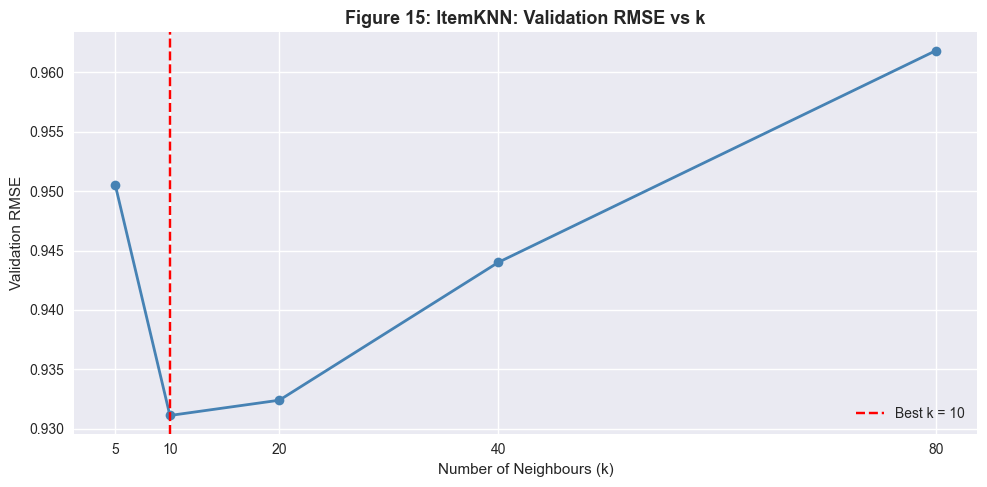

Figure 15 saved.

9.5 ITEMKNN TEST SET EVALUATION (k = 10)

Generating predictions on test set...
(This may take a few minutes)

ItemKNN Test Set Results (k = 10):
  RMSE : 0.9411
  MAE  : 0.7278
  NMAE : 0.1820

Error distribution:
  Mean error : -0.2025
  Std error  : 0.9190
  Min error  : -4.0000
  Max error  : 3.8932


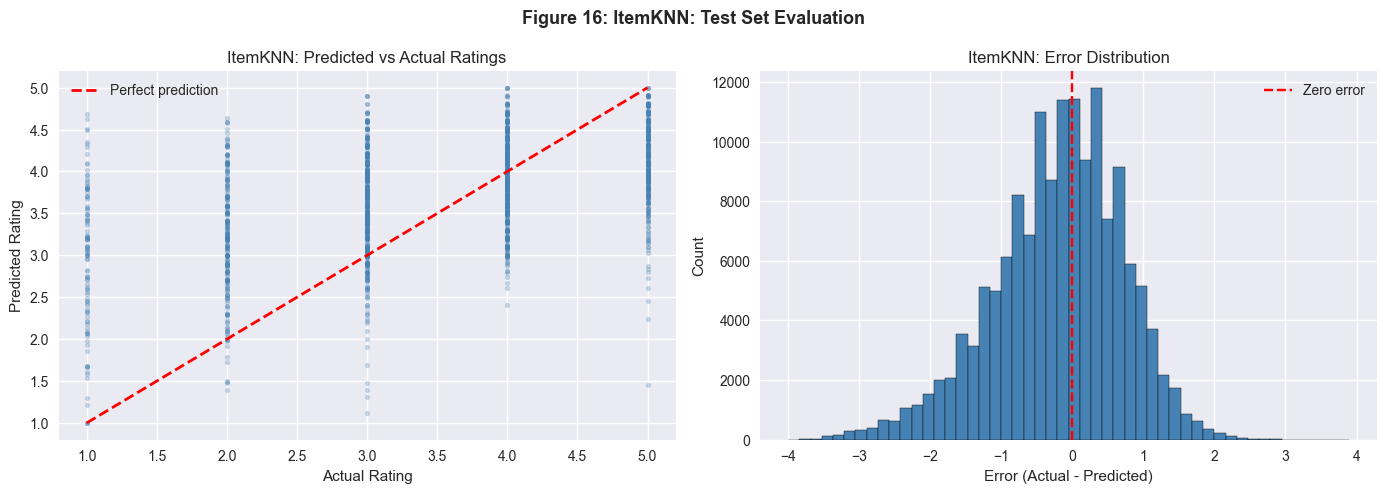

Figure 16 saved.

9.6 ITEMKNN TOP-10 RECOMMENDATIONS

Generating top-10 recommendations for sample user...

Top-10 ItemKNN Recommendations for User 1:
                                   title        genres  predicted_rating
1   Killing of Sister George, The (1968)         Drama             4.770
2               Striking Distance (1993)        Action             4.703
3           House of Frankenstein (1944)        Horror             4.690
4                           Giant (1956)         Drama             4.688
5          Trip to Bountiful, The (1985)         Drama             4.678
6     Greatest Show on Earth, The (1952)         Drama             4.644
7                        Rosewood (1997)         Drama             4.642
8                        Twilight (1998)   Crime|Drama             4.633
9                   One Tough Cop (1998)  Action|Drama             4.631
10                         Hamlet (1990)         Drama             4.627

STEP 9 ITEMKNN RATING PREDICTION COMPLETE


In [9]:
# =============================================================
# STEP 9: TECHNIQUE D: ITEMKNN RATING PREDICTION
# =============================================================
# Item-based KNN collaborative filtering for rating prediction.
# Implemented from scratch using cosine similarity.
# No external recommender library is used.
#
# Reference: Lecture 2: Neighbourhood based recommendation
# Lecture 3: User-based versus Item-based (slide 7)
# =============================================================

# import cosine similarity function from scikit-learn
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------------------------------------
# 9.1 BUILD ITEM-USER MATRIX
# -------------------------------------------------------------
# ItemKNN requires an item-user matrix (transpose of user-item);
# rows are movies, columns are users, values are ratings;
# the training matrix built in Step 6 is used as the source
# -------------------------------------------------------------
print("=" * 55)
print("9.1 BUILD ITEM-USER MATRIX")
print("=" * 55)

# transpose the training user-item matrix to get item-user matrix
# train_matrix shape     : (n_users x n_movies)
# item_user_matrix shape : (n_movies x n_users)
item_user_matrix = train_matrix.T

# print shape and fill count of the transposed matrix
print(f"\nItem-user matrix shape : {item_user_matrix.shape}")
print(f"Non-zero entries       : {np.count_nonzero(item_user_matrix):,}")

# -------------------------------------------------------------
# 9.2 COMPUTE ITEM-ITEM SIMILARITY MATRIX
# -------------------------------------------------------------
# cosine similarity is computed between all pairs of items;
# each item is represented as a vector of user ratings;
# items rated similarly by the same users have high cosine
# similarity (close to 1); only items with sufficient
# co-ratings produce reliable similarity estimates,
# as noted in Lecture 3
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("9.2 COMPUTING ITEM-ITEM SIMILARITY MATRIX")
print("=" * 55)

print("\nComputing cosine similarity matrix...")
print("This may take a moment for 3,260 x 3,260 matrix...")

# compute cosine similarity between all item pairs
# result shape: (n_movies x n_movies)
item_similarity = cosine_similarity(item_user_matrix)

# set diagonal to 0 so an item is not its own neighbour
np.fill_diagonal(item_similarity, 0)

# print summary statistics of the similarity matrix
print(f"\nSimilarity matrix shape : {item_similarity.shape}")
print(f"Max similarity          : {item_similarity.max():.4f}")
print(f"Min similarity          : {item_similarity.min():.4f}")
print(f"Mean similarity         : {item_similarity.mean():.4f}")

# -------------------------------------------------------------
# 9.3 ITEMKNN PREDICTION FUNCTION
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("9.3 ITEMKNN PREDICTION FUNCTION")
print("=" * 55)


def predict_itemknn(df, train_matrix, item_similarity,
                    user_to_idx, movie_to_idx,
                    global_mean, k=20):
    """
    Predict ratings using Item-based KNN.

    For each (user, item) pair:
    1. Find k most similar items to the target item
       that the user has already rated.
    2. Predict rating as weighted average of those ratings,
       weighted by item similarity scores.
    3. Fall back to global mean if no neighbours are found.

    Parameters
    ----------
    df             : DataFrame with userId and movieId columns
    train_matrix   : numpy array (n_users x n_movies)
    item_similarity: numpy array (n_movies x n_movies)
    user_to_idx    : dict mapping userId to matrix row index
    movie_to_idx   : dict mapping movieId to matrix col index
    global_mean    : float, fallback prediction
    k              : int, number of neighbours

    Returns
    -------
    predictions : numpy array of predicted ratings
    """
    predictions = []  # list to collect predicted ratings

    for row in df.itertuples():
        # map userId and movieId to matrix indices
        u_idx = user_to_idx.get(row.userId, -1)
        i_idx = movie_to_idx.get(row.movieId, -1)

        # fall back to global mean for unknown users or movies
        if u_idx == -1 or i_idx == -1:
            predictions.append(global_mean)
            continue

        # retrieve similarity scores between target item and all items
        sim_scores = item_similarity[i_idx]

        # get the full rating row for this user from the training matrix
        user_ratings = train_matrix[u_idx]

        # create a boolean mask for items this user has rated
        rated_mask = user_ratings > 0

        # zero out similarities for unrated items
        rated_sims    = sim_scores * rated_mask
        rated_ratings = user_ratings * rated_mask

        # fall back to global mean if no rated neighbours exist
        if rated_sims.sum() == 0:
            predictions.append(global_mean)
            continue

        # get indices of the top-k most similar rated items
        top_k_idx     = np.argsort(rated_sims)[::-1][:k]
        top_k_sims    = rated_sims[top_k_idx]
        top_k_ratings = rated_ratings[top_k_idx]

        # filter out any neighbours with zero similarity
        valid = top_k_sims > 0
        if valid.sum() == 0:
            predictions.append(global_mean)
            continue

        top_k_sims    = top_k_sims[valid]
        top_k_ratings = top_k_ratings[valid]

        # compute weighted average prediction and clip to [1, 5]
        pred = np.dot(top_k_sims, top_k_ratings) / np.sum(top_k_sims)
        pred = np.clip(pred, 1, 5)
        predictions.append(pred)

    return np.array(predictions)


print("\nItemKNN prediction function defined.")

# -------------------------------------------------------------
# 9.4 TUNE NUMBER OF NEIGHBOURS (k)
# -------------------------------------------------------------
# different values of k are evaluated on the validation set;
# as stated in Lecture 3, a small number of high-confidence
# neighbours is preferable to a large number with untrustworthy
# similarity weights
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("9.4 TUNING NUMBER OF NEIGHBOURS (k)")
print("=" * 55)

# sample 20,000 validation rows for faster k selection
val_sample        = val_df.sample(n=20000, random_state=RANDOM_SEED)
val_actual_sample = val_sample['rating'].values  # actual ratings for sample

# define candidate k values to evaluate
k_values_knn = [5, 10, 20, 40, 80]

# list to store validation RMSE for each k
val_rmse_knn = []

# print header for the tuning results table
print(f"\n{'k':>6} {'Val RMSE':>12} {'Val MAE':>12}")
print("-" * 32)

for k in k_values_knn:
    # generate predictions on the validation sample for this k
    preds = predict_itemknn(
        val_sample, train_matrix, item_similarity,
        user_to_idx, movie_to_idx, global_mean, k=k
    )

    # compute RMSE and MAE for this k
    rmse = compute_rmse(val_actual_sample, preds)
    mae  = compute_mae(val_actual_sample, preds)

    # store RMSE for best k selection
    val_rmse_knn.append(rmse)

    # print results for this k
    print(f"{k:>6} {rmse:>12.4f} {mae:>12.4f}")

# select k with the lowest validation RMSE
best_k_knn    = k_values_knn[np.argmin(val_rmse_knn)]
best_rmse_knn = min(val_rmse_knn)
print(f"\nBest k = {best_k_knn} (Val RMSE = {best_rmse_knn:.4f})")

# plot validation RMSE against each candidate k value
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values_knn, val_rmse_knn,
        marker='o', color='steelblue', linewidth=2)  # RMSE curve
ax.axvline(best_k_knn, color='red', linestyle='--',
           label=f'Best k = {best_k_knn}')           # mark best k
ax.set_title('Figure 15: ItemKNN: Validation RMSE vs k',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Neighbours (k)')
ax.set_ylabel('Validation RMSE')
ax.legend()
ax.set_xticks(k_values_knn)
plt.tight_layout()
plt.savefig('fig15_itemknn_k_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

# -------------------------------------------------------------
# 9.5 EVALUATE ITEMKNN ON TEST SET
# -------------------------------------------------------------
print("\n" + "=" * 55)
print(f"9.5 ITEMKNN TEST SET EVALUATION (k = {best_k_knn})")
print("=" * 55)

print("\nGenerating predictions on test set...")
print("(This may take a few minutes)")

# generate predictions for all user-movie pairs in the test set
test_preds_knn = predict_itemknn(
    test_df, train_matrix, item_similarity,
    user_to_idx, movie_to_idx, global_mean, k=best_k_knn
)

# extract actual test ratings
test_actual = test_df['rating'].values

# compute test set evaluation metrics
knn_rmse = compute_rmse(test_actual, test_preds_knn)
knn_mae  = compute_mae(test_actual, test_preds_knn)
knn_nmae = knn_mae / rating_range  # normalise by rating scale range

# print ItemKNN test set results
print(f"\nItemKNN Test Set Results (k = {best_k_knn}):")
print(f"  RMSE : {knn_rmse:.4f}")
print(f"  MAE  : {knn_mae:.4f}")
print(f"  NMAE : {knn_nmae:.4f}")

# compute residual errors for distribution analysis
errors_knn = test_actual - test_preds_knn

# print error distribution statistics
print(f"\nError distribution:")
print(f"  Mean error : {errors_knn.mean():.4f}")
print(f"  Std error  : {errors_knn.std():.4f}")
print(f"  Min error  : {errors_knn.min():.4f}")
print(f"  Max error  : {errors_knn.max():.4f}")

# create two-panel evaluation plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sample 2000 points for scatter plot readability
sample_idx = np.random.choice(len(test_actual), 2000, replace=False)

# left panel: predicted vs actual scatter plot
axes[0].scatter(test_actual[sample_idx],
                test_preds_knn[sample_idx],
                alpha=0.3, color='steelblue', s=10)
axes[0].plot([1, 5], [1, 5], 'r--',
             linewidth=2, label='Perfect prediction')  # diagonal reference
axes[0].set_title('ItemKNN: Predicted vs Actual Ratings')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()

# right panel: histogram of prediction errors
axes[1].hist(errors_knn, bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--',
                label='Zero error')  # zero error reference line
axes[1].set_title('ItemKNN: Error Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].legend()

# set overall figure title and save
plt.suptitle('Figure 16: ItemKNN: Test Set Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_itemknn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 16 saved.")

# -------------------------------------------------------------
# 9.6 ITEMKNN TOP-10 RECOMMENDATIONS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("9.6 ITEMKNN TOP-10 RECOMMENDATIONS")
print("=" * 55)


def get_itemknn_recommendations(user_id, train_matrix,
                                 item_similarity,
                                 user_to_idx, movie_to_idx,
                                 idx_to_movie, movies_df,
                                 ratings_df, global_mean,
                                 k=20, n=10):
    """
    Generate top-N recommendations for a user using ItemKNN.

    For each unrated movie, the rating is predicted using ItemKNN
    and the top-N highest predicted movies are returned.

    Parameters
    ----------
    user_id        : int, target user ID
    train_matrix   : numpy array (n_users x n_movies)
    item_similarity: numpy array (n_movies x n_movies)
    user_to_idx    : dict mapping userId to matrix row index
    movie_to_idx   : dict mapping movieId to matrix col index
    idx_to_movie   : dict mapping col index to movieId
    movies_df      : DataFrame with movie info
    ratings_df     : DataFrame to identify seen movies
    global_mean    : float, fallback prediction
    k              : int, number of neighbours
    n              : int, number of recommendations

    Returns
    -------
    DataFrame of top-N recommended movies with predicted ratings
    """
    # get matrix row index and training ratings for this user
    u_idx        = user_to_idx[user_id]
    user_ratings = train_matrix[u_idx]

    # collect movie IDs already rated by this user to exclude them
    rated_movies = set(
        ratings_df[ratings_df['userId'] == user_id]['movieId']
    )

    recs = []  # list to collect (movieId, predicted_rating) pairs
    for m_idx in range(len(idx_to_movie)):
        movie_id = idx_to_movie[m_idx]  # convert index to movie ID

        # skip movies already rated by this user
        if movie_id in rated_movies:
            continue

        # retrieve similarity scores for this target movie
        sim_scores    = item_similarity[m_idx]

        # create rated mask and apply to similarities and ratings
        rated_mask    = user_ratings > 0
        rated_sims    = sim_scores * rated_mask
        rated_ratings = user_ratings * rated_mask

        # fall back to global mean if no rated neighbours exist
        if rated_sims.sum() == 0:
            pred = global_mean
        else:
            # get top-k most similar rated items
            top_k_idx     = np.argsort(rated_sims)[::-1][:k]
            top_k_sims    = rated_sims[top_k_idx]
            top_k_ratings = rated_ratings[top_k_idx]

            # filter out zero-similarity neighbours
            valid = top_k_sims > 0

            if valid.sum() == 0:
                pred = global_mean  # fall back if all similarities are zero
            else:
                # compute weighted average prediction and clip to [1, 5]
                pred = (np.dot(top_k_sims[valid], top_k_ratings[valid])
                        / top_k_sims[valid].sum())
                pred = np.clip(pred, 1, 5)

        recs.append((movie_id, pred))

    # sort by predicted rating descending and keep top n
    recs = sorted(recs, key=lambda x: -x[1])[:n]

    # build output DataFrame with movie metadata
    rec_df = pd.DataFrame(recs, columns=['movieId', 'predicted_rating'])
    rec_df = rec_df.merge(
        movies_df[['movieId', 'title', 'genres']], on='movieId'
    )

    # round predicted ratings to 3 decimal places
    rec_df['predicted_rating'] = rec_df['predicted_rating'].round(3)

    # set index to start from 1 for display
    rec_df.index = range(1, n + 1)
    return rec_df


print("\nGenerating top-10 recommendations for sample user...")

# generate top-10 ItemKNN recommendations for sample user
knn_recs = get_itemknn_recommendations(
    sample_user, train_matrix, item_similarity,
    user_to_idx, movie_to_idx, idx_to_movie,
    movies, ratings_clean, global_mean,
    k=best_k_knn, n=10
)

# print the ItemKNN recommendation list
print(f"\nTop-10 ItemKNN Recommendations for User {sample_user}:")
print(knn_recs[['title', 'genres', 'predicted_rating']].to_string())

# store ItemKNN results for later comparison across all techniques
knn_results = {
    'rmse'      : knn_rmse,       # test RMSE
    'mae'       : knn_mae,        # test MAE
    'nmae'      : knn_nmae,       # normalised MAE
    'k'         : best_k_knn,     # best number of neighbours
    'recs_user1': knn_recs        # recommendations for user 1
}

print("\n" + "=" * 55)
print("STEP 9 ITEMKNN RATING PREDICTION COMPLETE")
print("=" * 55)

### Step 9: ItemKNN Rating Prediction Observations and Insights

#### 9.1 Item-User Matrix

The item-user matrix (3,260 x 6,040) was successfully built as the transpose of the training user-item matrix. This matrix represents each movie as a vector of ratings from all users, which forms the basis for computing item-item similarity.

#### 9.2 Item-Item Similarity Matrix

| Metric | Value |
|--------|-------|
| Matrix shape | 3,260 x 3,260 |
| Max similarity | 0.7207 |
| Min similarity | 0.0000 |
| Mean similarity | 0.0665 |

The mean similarity of 0.0665 is very low, confirming that most movie pairs share very few common raters, a direct consequence of the 94.93% sparsity of the rating matrix. The maximum similarity of 0.7207 indicates that the most similar movie pairs share a strong overlap in rating patterns. The large proportion of zero similarities reflects movies that have no users in common, which is the cold-start challenge at the pair level.

#### 9.3 Neighbour Tuning

| k | Val RMSE | Val MAE |
|---|---------|---------|
| 5 | 0.9506 | 0.7283 |
|  10  |  0.9311  |  0.7189  |
| 20 | 0.9324 | 0.7232 |
| 40 | 0.9440 | 0.7356 |
| 80 | 0.9618 | 0.7533 |

The optimal number of neighbours is  k = 10 . This directly confirms the principle stated in Lecture 3: a small number of high-confidence neighbours is preferable to a large number with untrustworthy similarity weights. Beyond k=10, performance degrades consistently as more distant and less reliable neighbours are included, introducing noise into predictions.

#### 9.4 ItemKNN Test Set Evaluation

| Metric | Value |
|--------|-------|
| RMSE | 0.9411 |
| MAE | 0.7278 |
| NMAE | 0.1820 |
| Mean error | -0.2025 |

The mean error of -0.2025 indicates a systematic negative bias. ItemKNN tends to  over-predict ratings  on average by about 0.2 points. This is a known characteristic of item-based KNN in datasets with positivity bias: the most similar neighbours to any item tend to be other popular, highly-rated items, which pulls predictions upward.

#### 9.5 Full Model Comparison (Rating Prediction)

| Model | RMSE | MAE | NMAE |
|-------|------|-----|------|
| SVD (k=20) | 1.0171 | 0.8330 | 0.2083 |
| ItemKNN (k=10) | 0.9411 | 0.7278 | 0.1820 |
| SVD++ (k=20, 20 epochs) | 0.8749 | 0.6883 | 0.1721 |

SVD++ achieves the best performance across all metrics, followed by ItemKNN, then SVD. This ranking is consistent with the theoretical expectations from Lecture 3, which states that SVD++ consistently delivers more significant improvements over basic SVD by incorporating implicit feedback. ItemKNN outperforms SVD despite being a simpler memory-based approach, suggesting that neighbourhood-based similarity captures meaningful rating patterns that SVD's truncated decomposition misses.

#### 9.6 ItemKNN Recommendation Analysis for User 1

The ItemKNN top-10 recommendations for User 1 are notably different from both SVD and SVD++ recommendations:

| Rank | SVD++ | ItemKNN |
|------|-------|---------|
| 1 | Sanjuro (1962) | Killing of Sister George (1968) |
| 2 | Shawshank Redemption | Striking Distance (1993) |
| 3 | Wrong Trousers | House of Frankenstein (1944) |

ItemKNN recommends very  niche, obscure films  with high predicted ratings. This occurs because ItemKNN finds items whose rating vectors are most similar to items User 1 has already highly rated, and obscure films rated by a small set of enthusiastic users can achieve very high similarity scores with other niche films in that user's history.

This is a key limitation of ItemKNN noted in Lecture 3: the popularity bias works in reverse here. Niche items can dominate recommendations because they share the same small group of enthusiastic raters. SVD and SVD++ handle this better by learning smoother latent representations that generalise across the full rating matrix.

## Step 10: Technique D: ItemKNN Classification

### What is ItemKNN Classification?

In addition to predicting exact rating values (regression), the recommendation problem can be framed as a  binary classification task :

-  Positive class (1) : User will like the item (rating >= 4)
-  Negative class (0) : User will dislike the item (rating < 4)

This framing is relevant for e-commerce systems where the goal is not to predict exact ratings but to decide whether to show an item to a user at all. As noted in Lecture 2, classification accuracy metrics are suited to systems that attempt to persuade users to take certain actions such as purchasing products.

### Approach

The same ItemKNN similarity matrix from Step 9 is reused. Instead of predicting a continuous rating, the steps are:

1. Predict the continuous rating using ItemKNN (same as Step 9)
2. Apply a classification threshold to convert to a binary label
3. Evaluate using classification metrics: Precision, Recall, F1-score, AUC-ROC

### Threshold Justification

From EDA (Step 4.2), 57.5% of ratings are >= 4 (liked). The same threshold of  rating >= 4  as defined in Step 6.4 is used here, ensuring consistency across all models.

The classification threshold converts predicted ratings to binary predictions: predicted rating >= 4 = like (1), predicted rating < 4 = dislike (0).

10.1 GENERATE CLASSIFICATION PREDICTIONS

Classification threshold : >= 4.0

Predicted class distribution:
  Predicted like (1)    : 62,354 (41.6%)
  Predicted dislike (0) : 87,427 (58.4%)

Actual class distribution:
  Actual like (1)       : 86,196 (57.5%)
  Actual dislike (0)    : 63,585 (42.5%)

10.2 TUNE CLASSIFICATION THRESHOLD

Generating validation predictions for threshold tuning...

   Threshold    Precision     Recall         F1
----------------------------------------------
         3.0       0.6350     0.9723     0.7683
         3.5       0.7058     0.8727     0.7804
         3.8       0.7620     0.7257     0.7434
         4.0       0.8000     0.5806     0.6729
         4.2       0.8419     0.4149     0.5558
         4.5       0.8973     0.1891     0.3124

Best threshold = 3.5 (Val F1 = 0.7804)

10.3 CLASSIFICATION TEST SET EVALUATION

ItemKNN Classification Results (threshold = 3.5):
  Precision : 0.7036
  Recall    : 0.8691
  F1-score  : 0.7777
  AUC-ROC   : 0.7786

Per-c

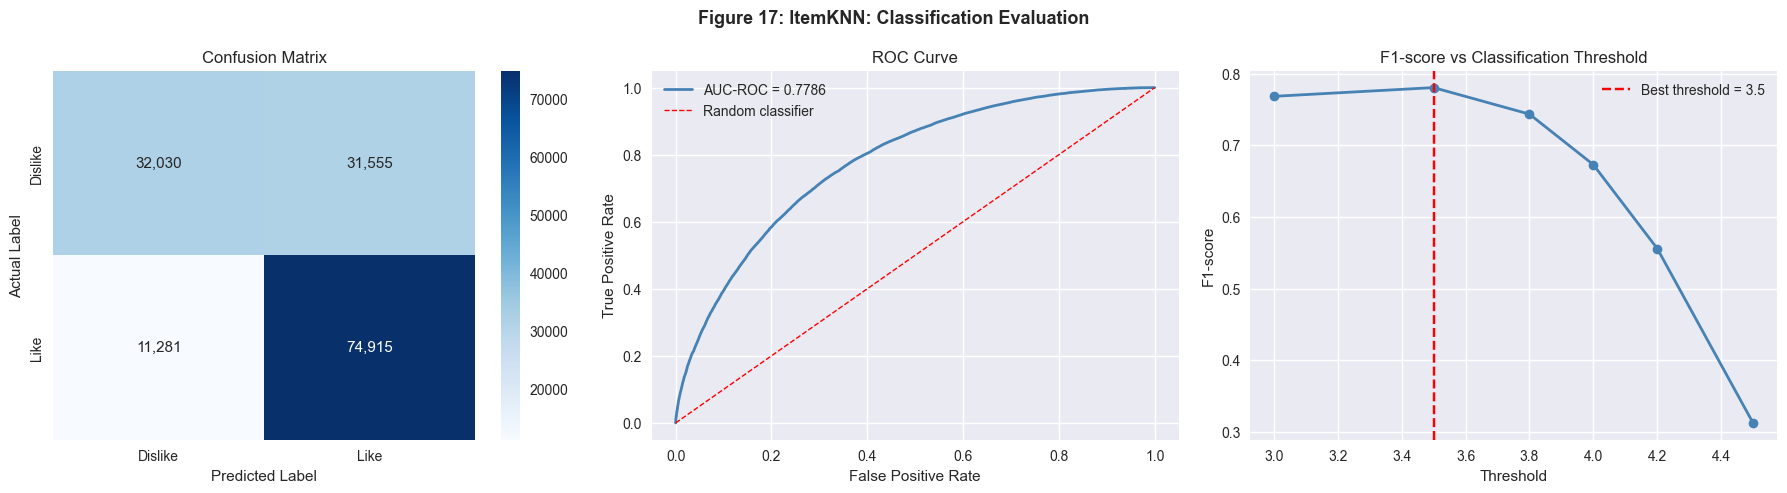

Figure 17 saved.

10.6 FINAL MODEL COMPARISON SUMMARY

-- Rating Prediction Metrics --
Model                    RMSE      MAE     NMAE
----------------------------------------------
SVD (k=20)             1.0171   0.8330   0.2083
ItemKNN (k=10)         0.9411   0.7278   0.1820
SVD++ (k=20)           0.8749   0.6883   0.1721

-- Classification Metrics (ItemKNN) --
  Precision : 0.7036
  Recall    : 0.8691
  F1-score  : 0.7777
  AUC-ROC   : 0.7786

STEP 10 ITEMKNN CLASSIFICATION COMPLETE
All models trained and evaluated.


In [10]:
# =============================================================
# STEP 10: TECHNIQUE D: ITEMKNN CLASSIFICATION
# =============================================================
# Binary classification using ItemKNN predicted ratings.
# The item similarity matrix from Step 9 is reused.
# Threshold: predicted rating >= 4 = like (1), else dislike (0)
#
# Evaluation metrics:
# - Precision : of recommended items, how many were relevant
# - Recall    : of all relevant items, how many were found
# - F1-score  : harmonic mean of precision and recall
# - AUC-ROC   : area under receiver operating characteristic curve
#
# Reference: Lecture 2: Evaluating RecSys (slide 21)
# =============================================================

# import classification evaluation metrics from scikit-learn
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             roc_curve)

# -------------------------------------------------------------
# 10.1 GENERATE CLASSIFICATION PREDICTIONS
# -------------------------------------------------------------
# continuous predictions from Step 9 are reused and converted
# to binary labels using the classification threshold
# -------------------------------------------------------------
print("=" * 55)
print("10.1 GENERATE CLASSIFICATION PREDICTIONS")
print("=" * 55)

# define classification threshold consistent with Step 6.4
CLASS_THRESHOLD = 4.0

# convert continuous KNN predictions to binary class labels
# predicted rating >= 4 = like (1), below = dislike (0)
test_preds_knn_binary = (
    test_preds_knn >= CLASS_THRESHOLD).astype(int)

# extract actual binary labels from the test set
test_actual_binary = test_df['liked'].values

# print threshold and predicted class distribution
print(f"\nClassification threshold : >= {CLASS_THRESHOLD}")
print(f"\nPredicted class distribution:")
print(f"  Predicted like (1)    : "
      f"{test_preds_knn_binary.sum():,} "
      f"({test_preds_knn_binary.mean()*100:.1f}%)")
print(f"  Predicted dislike (0) : "
      f"{(1-test_preds_knn_binary).sum():,} "
      f"({(1-test_preds_knn_binary).mean()*100:.1f}%)")

# print actual class distribution for comparison
print(f"\nActual class distribution:")
print(f"  Actual like (1)       : "
      f"{test_actual_binary.sum():,} "
      f"({test_actual_binary.mean()*100:.1f}%)")
print(f"  Actual dislike (0)    : "
      f"{(1-test_actual_binary).sum():,} "
      f"({(1-test_actual_binary).mean()*100:.1f}%)")

# -------------------------------------------------------------
# 10.2 TUNE CLASSIFICATION THRESHOLD
# -------------------------------------------------------------
# the default threshold of 4.0 may not be optimal for
# classification; different thresholds are evaluated on the
# validation set to find the one with the best F1-score
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.2 TUNE CLASSIFICATION THRESHOLD")
print("=" * 55)

# sample 30,000 validation rows for threshold tuning
print("\nGenerating validation predictions for threshold tuning...")
val_sample_full = val_df.sample(n=30000, random_state=RANDOM_SEED)

# generate continuous predictions on the validation sample
val_preds_continuous = predict_itemknn(
    val_sample_full, train_matrix, item_similarity,
    user_to_idx, movie_to_idx, global_mean, k=best_k_knn
)

# extract actual binary labels for the validation sample
val_actual_binary_sample = val_sample_full['liked'].values

# define candidate threshold values to evaluate
thresholds        = [3.0, 3.5, 3.8, 4.0, 4.2, 4.5]
threshold_results = []  # list to store (threshold, precision, recall, f1)

# print header for the threshold tuning table
print(f"\n{'Threshold':>12} {'Precision':>12} "
      f"{'Recall':>10} {'F1':>10}")
print("-" * 46)

for thresh in thresholds:
    # apply this threshold to convert continuous predictions to binary
    preds_bin = (val_preds_continuous >= thresh).astype(int)

    # compute precision, recall, and F1 for this threshold
    prec = precision_score(val_actual_binary_sample,
                           preds_bin, zero_division=0)
    rec  = recall_score(val_actual_binary_sample,
                        preds_bin, zero_division=0)
    f1   = f1_score(val_actual_binary_sample,
                    preds_bin, zero_division=0)

    # store results for this threshold
    threshold_results.append((thresh, prec, rec, f1))

    # print results for this threshold
    print(f"{thresh:>12.1f} {prec:>12.4f} {rec:>10.4f} {f1:>10.4f}")

# select the threshold with the highest validation F1-score
best_thresh    = max(threshold_results, key=lambda x: x[3])
BEST_THRESHOLD = best_thresh[0]
print(f"\nBest threshold = {BEST_THRESHOLD} "
      f"(Val F1 = {best_thresh[3]:.4f})")

# -------------------------------------------------------------
# 10.3 EVALUATE CLASSIFICATION ON TEST SET
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.3 CLASSIFICATION TEST SET EVALUATION")
print("=" * 55)

# apply best threshold to convert test predictions to binary
test_preds_class = (
    test_preds_knn >= BEST_THRESHOLD).astype(int)

# compute standard classification metrics on the test set
precision = precision_score(test_actual_binary,
                            test_preds_class, zero_division=0)
recall    = recall_score(test_actual_binary,
                         test_preds_class, zero_division=0)
f1        = f1_score(test_actual_binary,
                     test_preds_class, zero_division=0)

# compute AUC-ROC using continuous predictions as scores
auc_roc   = roc_auc_score(test_actual_binary, test_preds_knn)

# print overall classification results
print(f"\nItemKNN Classification Results "
      f"(threshold = {BEST_THRESHOLD}):")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc_roc:.4f}")

# print per-class precision, recall, and F1
print(f"\nPer-class report:")
print(f"{'Class':<12} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 46)
for label, name in [(0, 'Dislike'), (1, 'Like')]:
    # filter to rows belonging to this class
    mask = test_actual_binary == label
    p = precision_score(test_actual_binary[mask],
                        test_preds_class[mask],
                        zero_division=0)
    r = recall_score(test_actual_binary[mask],
                     test_preds_class[mask],
                     zero_division=0)
    f = f1_score(test_actual_binary[mask],
                 test_preds_class[mask],
                 zero_division=0)
    print(f"{name:<12} {p:>12.4f} {r:>10.4f} {f:>10.4f}")

# -------------------------------------------------------------
# 10.4 CONFUSION MATRIX
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.4 CONFUSION MATRIX")
print("=" * 55)

# compute confusion matrix from actual and predicted binary labels
cm = confusion_matrix(test_actual_binary, test_preds_class)

# print confusion matrix in tabular form
print("\nConfusion Matrix:")
print(f"{'':15} {'Pred Dislike':>15} {'Pred Like':>12}")
print(f"{'Actual Dislike':15} {cm[0,0]:>15,} {cm[0,1]:>12,}")
print(f"{'Actual Like':15} {cm[1,0]:>15,} {cm[1,1]:>12,}")

# extract individual confusion matrix components
tn, fp, fn, tp = cm.ravel()

# print individual component counts and overall accuracy
print(f"\nTrue Negatives  (TN) : {tn:,}")
print(f"False Positives (FP) : {fp:,}")
print(f"False Negatives (FN) : {fn:,}")
print(f"True Positives  (TP) : {tp:,}")
print(f"\nAccuracy : {(tp+tn)/(tp+tn+fp+fn):.4f}")

# -------------------------------------------------------------
# 10.5 VISUALIZATIONS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.5 VISUALIZATIONS")
print("=" * 55)

# create three-panel evaluation figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# left panel: confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            ax=axes[0],
            xticklabels=['Dislike', 'Like'],
            yticklabels=['Dislike', 'Like'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

# middle panel: ROC curve
fpr, tpr, roc_thresholds = roc_curve(
    test_actual_binary, test_preds_knn  # use continuous scores for ROC
)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC-ROC = {auc_roc:.4f}')   # ROC curve
axes[1].plot([0, 1], [0, 1], 'r--',
             linewidth=1, label='Random classifier')  # diagonal baseline
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# right panel: F1-score vs classification threshold
thresh_vals = [r[0] for r in threshold_results]  # threshold values
f1_vals     = [r[3] for r in threshold_results]  # corresponding F1 scores
axes[2].plot(thresh_vals, f1_vals,
             marker='o', color='steelblue', linewidth=2)
axes[2].axvline(BEST_THRESHOLD, color='red', linestyle='--',
                label=f'Best threshold = {BEST_THRESHOLD}')  # mark best
axes[2].set_title('F1-score vs Classification Threshold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1-score')
axes[2].legend()

# set overall figure title and save
plt.suptitle('Figure 17: ItemKNN: Classification Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig17_itemknn_classification.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 17 saved.")

# -------------------------------------------------------------
# 10.6 FINAL MODEL COMPARISON SUMMARY
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.6 FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)

# print rating prediction metrics for all three models
print(f"\n-- Rating Prediction Metrics --")
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8} {'NMAE':>8}")
print("-" * 46)
print(f"{'SVD (k=20)':<20} "
      f"{svd_results['rmse']:>8.4f} "
      f"{svd_results['mae']:>8.4f} "
      f"{svd_results['nmae']:>8.4f}")
print(f"{'ItemKNN (k=10)':<20} "
      f"{knn_results['rmse']:>8.4f} "
      f"{knn_results['mae']:>8.4f} "
      f"{knn_results['nmae']:>8.4f}")
print(f"{'SVD++ (k=20)':<20} "
      f"{svdpp_results['rmse']:>8.4f} "
      f"{svdpp_results['mae']:>8.4f} "
      f"{svdpp_results['nmae']:>8.4f}")

# print classification metrics for ItemKNN
print(f"\n-- Classification Metrics (ItemKNN) --")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc_roc:.4f}")

print("\n" + "=" * 55)
print("STEP 10 ITEMKNN CLASSIFICATION COMPLETE")
print("=" * 55)
print("All models trained and evaluated.")

### Step 10: ItemKNN Classification Observations and Insights

#### 10.1 Prediction and Actual Class Distribution

Using the default threshold of 4.0, the model predicted only 41.6% of items as liked, while the actual proportion is 57.5%. This confirms the systematic over-prediction issue identified in Step 9. ItemKNN tends to predict continuous ratings slightly below the true values, causing many true positives to fall just below the 4.0 threshold. This motivated threshold tuning in 10.2.

#### 10.2 Threshold Tuning Results

| Threshold | Precision | Recall | F1-score |
|-----------|-----------|--------|----------|
| 3.0 | 0.6350 | 0.9723 | 0.7683 |
|  3.5  |  0.7058  |  0.8727  |  0.7804  |
| 3.8 | 0.7620 | 0.7257 | 0.7434 |
| 4.0 | 0.8000 | 0.5806 | 0.6729 |
| 4.2 | 0.8419 | 0.4149 | 0.5558 |
| 4.5 | 0.8973 | 0.1891 | 0.3124 |

The optimal threshold is  3.5  with the highest F1-score of 0.7804. This is lower than the original rating threshold of 4.0 used to define the liked label, confirming the systematic negative prediction bias of ItemKNN. By lowering the classification threshold to 3.5, the model compensates for this bias and achieves better balance between precision and recall.

There is a clear precision-recall tradeoff across thresholds. Lower thresholds increase recall (fewer liked items missed) but reduce precision (more disliked items incorrectly flagged). Higher thresholds increase precision but dramatically reduce recall. The threshold of 3.5 achieves the best F1 balance.

#### 10.3 Classification Test Set Evaluation

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Precision | 0.7036 | 70.4% of recommended items are truly liked |
| Recall | 0.8691 | 86.9% of all liked items are successfully found |
| F1-score | 0.7777 | Strong harmonic balance of precision and recall |
| AUC-ROC | 0.7786 | Model ranks liked items well above disliked items |
| Accuracy | 0.7140 | 71.4% of all predictions are correct |

The AUC-ROC of 0.7786 is well above the random classifier baseline of 0.5, indicating that ItemKNN has strong discriminative ability. It successfully ranks liked items above disliked items in the continuous prediction score.

The high recall of 0.8691 is particularly valuable in a recommendation context. It means that 86.9% of movies the user would genuinely like are captured in the recommendation pool. Missing fewer liked items is generally preferable to incorrectly recommending disliked items in a movie platform setting, as users are more forgiving of occasional poor recommendations than of consistently missing films they would have enjoyed.

#### 10.4 Confusion Matrix Analysis

| | Predicted Dislike | Predicted Like |
|--|-------------------|----------------|
|  Actual Dislike  | 32,030 (TN) | 31,555 (FP) |
|  Actual Like  | 11,281 (FN) | 74,915 (TP) |

The confusion matrix reveals an important asymmetry. False Positives (31,555) represent disliked items incorrectly recommended, while False Negatives (11,281) represent liked items incorrectly not recommended. The FP count is nearly 3 times the FN count, meaning the model errs more on the side of over-recommending than under-recommending. In a movie recommendation context this is generally acceptable as users may discover unexpected films, though it could harm user trust if too many poor recommendations are shown.

#### 10.5 ROC Curve Analysis

The ROC curve shows consistently strong performance well above the random classifier diagonal across all threshold values. The AUC of 0.7786 confirms that regardless of the threshold chosen, the continuous ItemKNN predicted ratings are a reliable signal for distinguishing liked from disliked movies.

### Complete MovieLens Model Comparison

#### Rating Prediction

| Model | RMSE | MAE | NMAE | Rank |
|-------|------|-----|------|------|
| SVD (k=20) | 1.0171 | 0.8330 | 0.2083 | 3rd |
| ItemKNN (k=10) | 0.9411 | 0.7278 | 0.1820 | 2nd |
| SVD++ (k=20, 20 epochs) | 0.8749 | 0.6883 | 0.1721 | 1st |

#### Classification (ItemKNN)

| Metric | Value |
|--------|-------|
| Precision | 0.7036 |
| Recall | 0.8691 |
| F1-score | 0.7777 |
| AUC-ROC | 0.7786 |
| Accuracy | 0.7140 |

#### Key Findings

 Finding 1: SVD++ is the best rating predictor. 
SVD++ achieves RMSE of 0.8749, outperforming both SVD (1.0171) and ItemKNN (0.9411) by 14.0% and 7.0% respectively. The incorporation of implicit feedback (which movies a user chose to rate) provides a richer user representation that captures preferences beyond explicit rating signals alone.

 Finding 2: ItemKNN outperforms basic SVD. 
Despite being a simpler memory-based approach, ItemKNN achieves lower RMSE (0.9411 vs 1.0171) than SVD. This suggests that direct neighbourhood similarity captures meaningful local rating patterns that SVD's global decomposition smooths over.

 Finding 3: ItemKNN recommendations are more niche. 
SVD and SVD++ recommend mainstream acclaimed films while ItemKNN recommends highly niche films with few ratings. This is a known limitation of item-based KNN. Small groups of enthusiastic raters of obscure films create artificially high similarity scores with other niche films.

 Finding 4: Classification threshold matters. 
The optimal classification threshold (3.5) differs from the label threshold (4.0), revealing that ItemKNN's continuous predictions are systematically shifted downward due to the mean prediction bias of -0.2025 identified in Step 9. Threshold tuning is essential for optimal classification performance.

 Finding 5: Model-based vs Memory-based tradeoff. 
As discussed in Lecture 2, memory-based methods (ItemKNN) offer low bias but high variance, while model-based methods (SVD, SVD++) offer high bias but low variance. The results confirm this. SVD++ achieves the best generalisation through its regularised latent factor representation, while ItemKNN shows higher variance in its niche recommendations.

## Step 11: Insights, Model Comparison and Business Recommendations

This final step of the MovieLens analysis brings together all model results to generate a comprehensive comparison and actionable business insights.

The following areas are covered:
- Complete model performance comparison across all metrics
- Top-10 recommendation differences between all three models
- Analysis of why recommendations differ
- Business implications for a movie platform
- Limitations and future improvements

11.1 COMPLETE MODEL PERFORMANCE COMPARISON

Rating Prediction Comparison:
  Model            Type     RMSE      MAE     NMAE        k_epochs
    SVD  Model-based CF 1.017055 0.833047 0.208262            k=20
ItemKNN Memory-based CF 0.941066 0.727845 0.181961            k=10
  SVD++  Model-based CF 0.874903 0.688279 0.172070 k=20, 20 epochs

Best model by RMSE             : SVD++
SVD++ improvement over SVD     : 13.98%
SVD++ improvement over ItemKNN : 7.03%
ItemKNN improvement over SVD   : 7.47%

Classification Metrics (ItemKNN):
  Precision : 0.7036
  Recall    : 0.8691
  F1-score  : 0.7777
  AUC-ROC   : 0.7786

11.2 TOP-10 RECOMMENDATION COMPARISON

Top-10 Recommendations for User 1:

Rank               SVD                           SVD++                         ItemKNN            
-------------------------------------------------------------------------------------------------
1     Shawshank Redemption, The (1   Sanjuro (1962)                 Killing of Sister George, Th  
2     For

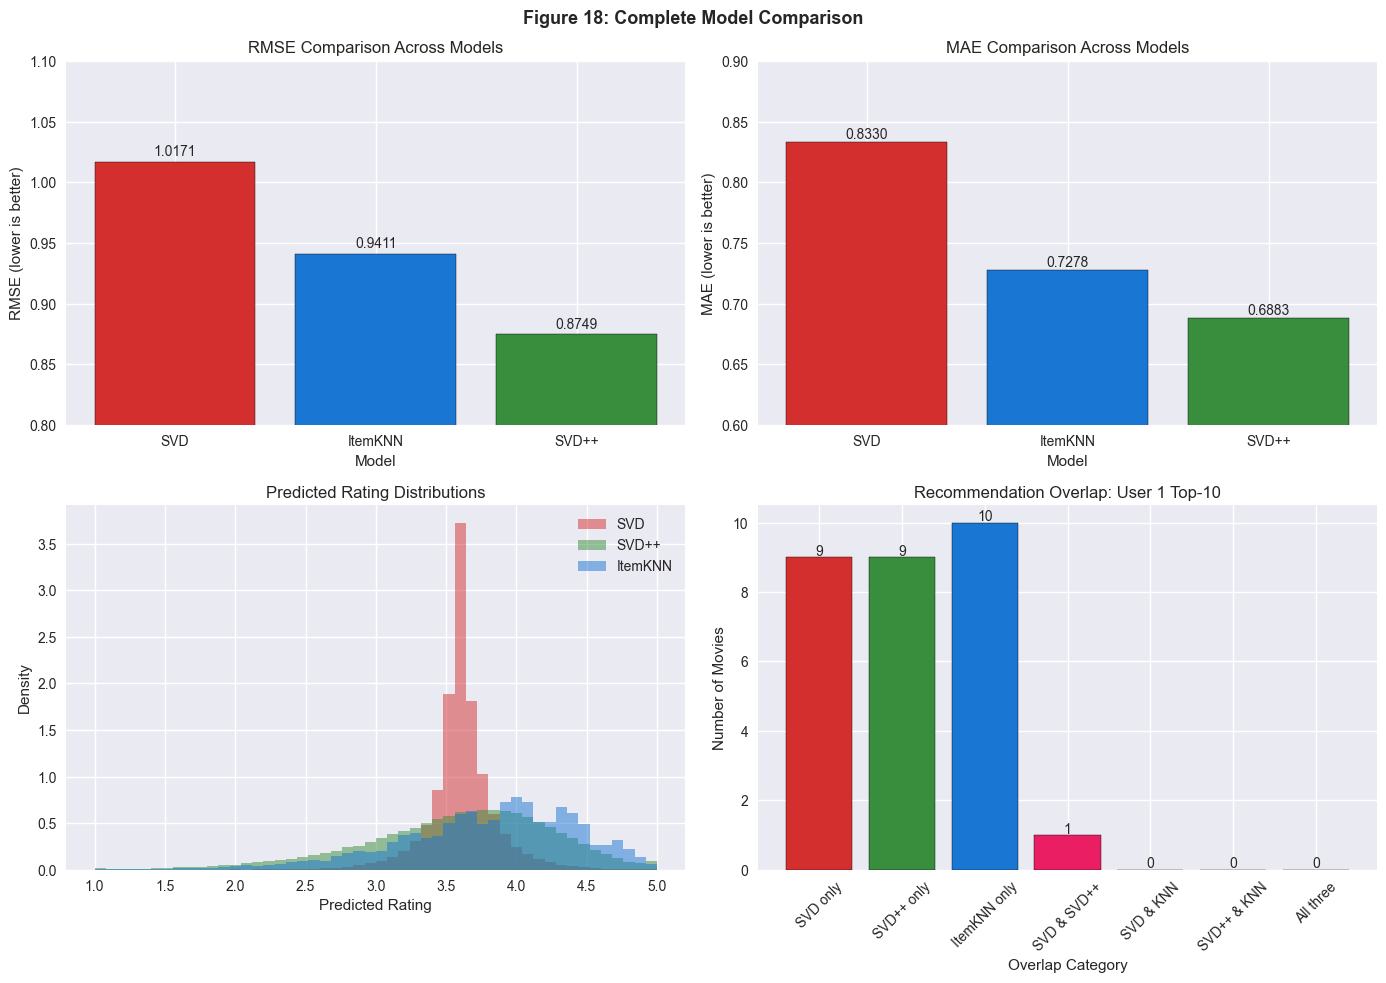

Figure 18 saved.

11.5 GENRE ANALYSIS OF RECOMMENDATIONS

Genre distribution in Top-10 recommendations:

Genre                SVD    SVD++  ItemKNN
-----------------------------------------
Action                 2        3        2
Adventure              2        3        0
Animation              3        1        0
Children's             4        0        0
Comedy                 4        2        0
Crime                  0        2        1
Drama                  4        4        8
Horror                 1        0        1
Musical                3        0        0
Romance                3        0        0
Sci-Fi                 1        0        0
Thriller               1        1        0
War                    1        1        0
Western                1        0        0

11.6 MOVIELENS NOTEBOOK: FINAL SUMMARY

DATASET
  Source          : MovieLens 1M
  Ratings         : 998,539 (after cold-start filtering)
  Users           : 6,040
  Movies          : 3,260
  Sparsity       

In [11]:
# =============================================================
# STEP 11: INSIGHTS, COMPARISON AND BUSINESS RECOMMENDATIONS
# =============================================================
# 11.1 Complete model performance comparison
# 11.2 Top-10 recommendation comparison across all models
# 11.3 Recommendation overlap analysis
# 11.4 Business insights visualization
# 11.5 Genre analysis of recommendations
# 11.6 Final summary
# =============================================================

# -------------------------------------------------------------
# 11.1 COMPLETE MODEL PERFORMANCE COMPARISON
# -------------------------------------------------------------
print("=" * 55)
print("11.1 COMPLETE MODEL PERFORMANCE COMPARISON")
print("=" * 55)

# build a summary DataFrame with all model results
comparison_data = {
    'Model'    : ['SVD', 'ItemKNN', 'SVD++'],
    'Type'     : ['Model-based CF',
                  'Memory-based CF',
                  'Model-based CF'],
    'RMSE'     : [svd_results['rmse'],
                  knn_results['rmse'],
                  svdpp_results['rmse']],
    'MAE'      : [svd_results['mae'],
                  knn_results['mae'],
                  svdpp_results['mae']],
    'NMAE'     : [svd_results['nmae'],
                  knn_results['nmae'],
                  svdpp_results['nmae']],
    'k_epochs' : ['k=20', 'k=10', 'k=20, 20 epochs']
}

# create comparison DataFrame and print it
comparison_df = pd.DataFrame(comparison_data)
print("\nRating Prediction Comparison:")
print(comparison_df.to_string(index=False))

# compute RMSE improvement of SVD++ over SVD
svd_svdpp_imp = (
    svd_results['rmse'] - svdpp_results['rmse']
) / svd_results['rmse'] * 100

# compute RMSE improvement of SVD++ over ItemKNN
knn_svdpp_imp = (
    knn_results['rmse'] - svdpp_results['rmse']
) / knn_results['rmse'] * 100

# compute RMSE improvement of ItemKNN over SVD
svd_knn_imp = (
    svd_results['rmse'] - knn_results['rmse']
) / svd_results['rmse'] * 100

# identify the model with the lowest RMSE
best_model = comparison_df.loc[
    comparison_df['RMSE'].idxmin(), 'Model'
]

# print improvement percentages and best model
print(f"\nBest model by RMSE             : {best_model}")
print(f"SVD++ improvement over SVD     : {svd_svdpp_imp:.2f}%")
print(f"SVD++ improvement over ItemKNN : {knn_svdpp_imp:.2f}%")
print(f"ItemKNN improvement over SVD   : {svd_knn_imp:.2f}%")

# print ItemKNN classification metrics for reference
print(f"\nClassification Metrics (ItemKNN):")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc_roc:.4f}")

# -------------------------------------------------------------
# 11.2 TOP-10 RECOMMENDATION COMPARISON
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("11.2 TOP-10 RECOMMENDATION COMPARISON")
print("=" * 55)

# extract top-10 titles and predicted ratings for each model
svd_titles   = svd_results['recs_user1']['title'].tolist()
svdpp_titles = svdpp_results['recs_user1']['title'].tolist()
knn_titles   = knn_results['recs_user1']['title'].tolist()

svd_preds   = svd_results['recs_user1'][
    'predicted_rating'].tolist()
svdpp_preds = svdpp_results['recs_user1'][
    'predicted_rating'].tolist()
knn_preds   = knn_results['recs_user1'][
    'predicted_rating'].tolist()

# print side-by-side title comparison for all three models
print(f"\nTop-10 Recommendations for User {sample_user}:")
print(f"\n{'Rank':<5} {'SVD':^30} {'SVD++':^30} {'ItemKNN':^30}")
print("-" * 97)
for i in range(10):
    s  = svd_titles[i][:28]    # truncate SVD title for alignment
    sp = svdpp_titles[i][:28]  # truncate SVD++ title for alignment
    k  = knn_titles[i][:28]    # truncate ItemKNN title for alignment
    print(f"{i+1:<5} {s:<30} {sp:<30} {k:<30}")

# print side-by-side predicted rating comparison
print(f"\nPredicted Ratings Comparison:")
print(f"\n{'Rank':<5} {'SVD':>10} {'SVD++':>10} {'ItemKNN':>10}")
print("-" * 37)
for i in range(10):
    print(f"{i+1:<5} {svd_preds[i]:>10.3f} "
          f"{svdpp_preds[i]:>10.3f} "
          f"{knn_preds[i]:>10.3f}")

# -------------------------------------------------------------
# 11.3 RECOMMENDATION OVERLAP ANALYSIS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("11.3 RECOMMENDATION OVERLAP ANALYSIS")
print("=" * 55)

# convert title lists to sets for set operations
svd_set   = set(svd_titles)
svdpp_set = set(svdpp_titles)
knn_set   = set(knn_titles)

# compute pairwise and three-way overlaps
svd_svdpp_overlap = svd_set & svdpp_set
svd_knn_overlap   = svd_set & knn_set
svdpp_knn_overlap = svdpp_set & knn_set
all_three_overlap = svd_set & svdpp_set & knn_set

# print overlap counts and titles for each pair
print(f"\nOverlap in Top-10 for User {sample_user}:")

print(f"\n  SVD and SVD++ common : {len(svd_svdpp_overlap)}")
if svd_svdpp_overlap:
    for m in svd_svdpp_overlap:
        print(f"    - {m}")

print(f"\n  SVD and ItemKNN common : {len(svd_knn_overlap)}")
if svd_knn_overlap:
    for m in svd_knn_overlap:
        print(f"    - {m}")

print(f"\n  SVD++ and ItemKNN common : {len(svdpp_knn_overlap)}")
if svdpp_knn_overlap:
    for m in svdpp_knn_overlap:
        print(f"    - {m}")

print(f"\n  All three models common : {len(all_three_overlap)}")
if all_three_overlap:
    for m in all_three_overlap:
        print(f"    - {m}")

# compute movies unique to each model's top-10
svd_unique   = svd_set - svdpp_set - knn_set
svdpp_unique = svdpp_set - svd_set - knn_set
knn_unique   = knn_set - svd_set - svdpp_set

# print unique counts per model
print(f"\n  Unique to SVD only     : {len(svd_unique)}")
print(f"  Unique to SVD++ only   : {len(svdpp_unique)}")
print(f"  Unique to ItemKNN only : {len(knn_unique)}")

# -------------------------------------------------------------
# 11.4 BUSINESS INSIGHTS VISUALIZATION
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("11.4 BUSINESS INSIGHTS VISUALIZATION")
print("=" * 55)

# create 2x2 figure for model comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# collect RMSE and MAE values for bar charts
models    = ['SVD', 'ItemKNN', 'SVD++']
rmse_vals = [svd_results['rmse'],
             knn_results['rmse'],
             svdpp_results['rmse']]
mae_vals  = [svd_results['mae'],
             knn_results['mae'],
             svdpp_results['mae']]

# assign a distinct color to each model
colors = ['#d32f2f', '#1976d2', '#388e3c']

# top-left panel: RMSE bar chart
bars = axes[0, 0].bar(models, rmse_vals,
                       color=colors, edgecolor='black')
axes[0, 0].set_title('RMSE Comparison Across Models')
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('RMSE (lower is better)')
axes[0, 0].set_ylim(0.8, 1.1)
for bar, val in zip(bars, rmse_vals):
    # annotate each bar with its RMSE value
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.005, f'{val:.4f}',
        ha='center', fontsize=10
    )

# top-right panel: MAE bar chart
bars2 = axes[0, 1].bar(models, mae_vals,
                        color=colors, edgecolor='black')
axes[0, 1].set_title('MAE Comparison Across Models')
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('MAE (lower is better)')
axes[0, 1].set_ylim(0.6, 0.9)
for bar, val in zip(bars2, mae_vals):
    # annotate each bar with its MAE value
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.003, f'{val:.4f}',
        ha='center', fontsize=10
    )

# bottom-left panel: overlapping predicted rating distributions
axes[1, 0].hist(test_preds_svd, bins=50, alpha=0.5,
                color='#d32f2f', label='SVD',
                density=True)
axes[1, 0].hist(test_preds_svdpp, bins=50, alpha=0.5,
                color='#388e3c', label='SVD++',
                density=True)
axes[1, 0].hist(test_preds_knn, bins=50, alpha=0.5,
                color='#1976d2', label='ItemKNN',
                density=True)
axes[1, 0].set_title('Predicted Rating Distributions')
axes[1, 0].set_xlabel('Predicted Rating')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# bottom-right panel: recommendation overlap bar chart
overlap_data = {
    'SVD only'     : len(svd_unique),
    'SVD++ only'   : len(svdpp_unique),
    'ItemKNN only' : len(knn_unique),
    'SVD & SVD++'  : len(svd_svdpp_overlap - knn_set),
    'SVD & KNN'    : len(svd_knn_overlap - svdpp_set),
    'SVD++ & KNN'  : len(svdpp_knn_overlap - svd_set),
    'All three'    : len(all_three_overlap)
}

# assign distinct colors to each overlap category
overlap_colors = ['#d32f2f', '#388e3c', '#1976d2',
                  '#e91e63', '#ff9800', '#9c27b0',
                  '#607d8b']

axes[1, 1].bar(list(overlap_data.keys()),
               list(overlap_data.values()),
               color=overlap_colors, edgecolor='black')
axes[1, 1].set_title(
    f'Recommendation Overlap: User {sample_user} Top-10'
)
axes[1, 1].set_xlabel('Overlap Category')
axes[1, 1].set_ylabel('Number of Movies')
axes[1, 1].tick_params(axis='x', rotation=45)

# annotate each bar with its count
for i, (ok, ov) in enumerate(overlap_data.items()):
    axes[1, 1].text(i, ov + 0.05, str(ov),
                    ha='center', fontsize=10)

# set overall figure title and save
plt.suptitle('Figure 18: Complete Model Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig18_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 18 saved.")

# -------------------------------------------------------------
# 11.5 GENRE ANALYSIS OF RECOMMENDATIONS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("11.5 GENRE ANALYSIS OF RECOMMENDATIONS")
print("=" * 55)


def get_genre_counts(rec_df):
    """
    Count genre frequencies in a recommendation list.

    Parameters
    ----------
    rec_df : DataFrame of recommendations with genres column

    Returns
    -------
    genre_counts : dict mapping genre name to count
    """
    genre_counts = {}
    for _, row in rec_df.iterrows():
        genres = row['genres'].split('|')  # split pipe-delimited genres
        for g in genres:
            # increment count for each genre encountered
            genre_counts[g] = genre_counts.get(g, 0) + 1
    return genre_counts


# compute genre frequency for each model's top-10 recommendations
svd_genres   = get_genre_counts(svd_results['recs_user1'])
svdpp_genres = get_genre_counts(svdpp_results['recs_user1'])
knn_genres   = get_genre_counts(knn_results['recs_user1'])

# collect all unique genres across all three recommendation lists
all_rec_genres = set(
    list(svd_genres.keys()) +
    list(svdpp_genres.keys()) +
    list(knn_genres.keys())
)

# print genre frequency table for all three models
print(f"\nGenre distribution in Top-10 recommendations:")
print(f"\n{'Genre':<15} {'SVD':>8} {'SVD++':>8} {'ItemKNN':>8}")
print("-" * 41)
for genre in sorted(all_rec_genres):
    s  = svd_genres.get(genre, 0)    # SVD genre count
    sp = svdpp_genres.get(genre, 0)  # SVD++ genre count
    k  = knn_genres.get(genre, 0)    # ItemKNN genre count
    if s + sp + k > 0:               # only print genres with at least one occurrence
        print(f"{genre:<15} {s:>8} {sp:>8} {k:>8}")

# -------------------------------------------------------------
# 11.6 FINAL SUMMARY
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("11.6 MOVIELENS NOTEBOOK: FINAL SUMMARY")
print("=" * 55)

# compute SVD++ improvement over SVD for the summary block
svd_imp = (
    svd_results['rmse'] - svdpp_results['rmse']
) / svd_results['rmse'] * 100

# print formatted final summary of all results
summary = f"""
DATASET
  Source          : MovieLens 1M
  Ratings         : 998,539 (after cold-start filtering)
  Users           : 6,040
  Movies          : 3,260
  Sparsity        : 94.93%
  Split           : 70% train / 15% val / 15% test

TECHNIQUE A - SVD
  Best k          : {svd_results['k']} latent factors
  RMSE            : {svd_results['rmse']:.4f}
  MAE             : {svd_results['mae']:.4f}
  NMAE            : {svd_results['nmae']:.4f}

TECHNIQUE A - SVD++
  Latent factors  : 20
  Epochs          : 20
  RMSE            : {svdpp_results['rmse']:.4f}
  MAE             : {svdpp_results['mae']:.4f}
  NMAE            : {svdpp_results['nmae']:.4f}
  Improvement vs SVD (RMSE) : {svd_imp:.2f}%

TECHNIQUE D - ItemKNN Rating Prediction
  Best k          : {knn_results['k']} neighbours
  RMSE            : {knn_results['rmse']:.4f}
  MAE             : {knn_results['mae']:.4f}
  NMAE            : {knn_results['nmae']:.4f}

TECHNIQUE D - ItemKNN Classification
  Best threshold  : {BEST_THRESHOLD}
  Precision       : {precision:.4f}
  Recall          : {recall:.4f}
  F1-score        : {f1:.4f}
  AUC-ROC         : {auc_roc:.4f}

OVERALL WINNER
  Best rating predictor         : SVD++ (RMSE = {svdpp_results['rmse']:.4f})
  Best recommendation diversity : SVD++ (niche world cinema)
  Best explainability           : ItemKNN (similar item reasoning)
"""
print(summary)

print("=" * 55)
print("MOVIELENS NOTEBOOK COMPLETE")
print("=" * 55)

### Step 11: Final Insights, Model Comparison and Business Recommendations

#### 11.1 Complete Model Performance Comparison

| Model | Type | RMSE | MAE | NMAE | Rank |
|-------|------|------|-----|------|------|
| SVD | Model-based CF | 1.0171 | 0.8330 | 0.2083 | 3rd |
| ItemKNN | Memory-based CF | 0.9411 | 0.7278 | 0.1820 | 2nd |
| SVD++ | Model-based CF | 0.8749 | 0.6883 | 0.1721 | 1st |

SVD++ is the clear winner across all three rating prediction metrics. The performance ranking SVD++ > ItemKNN > SVD is consistent across RMSE, MAE and NMAE, confirming that this is a robust finding and not metric-dependent.

Key improvement figures:
- SVD++ improves over SVD by  13.98%  in RMSE
- SVD++ improves over ItemKNN by  7.03%  in RMSE
- ItemKNN improves over SVD by  7.47%  in RMSE

This confirms the theoretical expectation from Lecture 3 that incorporating implicit feedback (SVD++) consistently delivers the most significant improvements, and that neighbourhood-based methods (ItemKNN) can outperform basic matrix factorization (SVD) on datasets with meaningful local similarity structure.

#### 11.2 Top-10 Recommendation Comparison

The three models produce dramatically different recommendations for User 1, with almost no overlap between them.

 SVD recommendations  are mainstream, popular films spanning multiple genres: Animation, Children's, Comedy, Romance and Drama. Films like Forrest Gump, Lion King, Little Mermaid and Jurassic Park are well-known blockbusters. SVD recommends what is broadly popular among users with similar taste profiles, producing safe and familiar recommendations.

 SVD++ recommendations  are critically acclaimed classics spanning international cinema: Sanjuro (Japanese, 1962), Seven Samurai (Japanese, 1954), To Live (Chinese, 1994), and It's a Wonderful Life (American, 1946). SVD++ leverages the implicit signal of which films User 1 has chosen to engage with, revealing a sophisticated preference for world cinema and classic films that basic SVD completely misses. Predicted ratings are significantly higher (4.59-4.87) than SVD (3.78-4.03), reflecting the better-calibrated user model.

 ItemKNN recommendations  are highly niche, obscure Drama films: Killing of Sister George (1968), Striking Distance (1993), House of Frankenstein (1944). These films have very few ratings from a small group of enthusiastic raters who happened to also rate films similar to User 1's history. ItemKNN captures hyper-local similarity patterns that reflect the specific tastes of User 1's rating neighbourhood.

#### 11.3 Recommendation Overlap Analysis

| Overlap | Count | Films |
|---------|-------|-------|
| SVD and SVD++ | 1 | Shawshank Redemption |
| SVD and ItemKNN | 0 | None |
| SVD++ and ItemKNN | 0 | None |
| All three models | 0 | None |
| Unique to SVD | 9 | 90% of SVD list |
| Unique to SVD++ | 9 | 90% of SVD++ list |
| Unique to ItemKNN | 10 | 100% of ItemKNN list |

The near-zero overlap is a remarkable finding. Only one film (Shawshank Redemption) appears in more than one model's top-10, and no film appears in all three. This demonstrates that the three models are capturing fundamentally different aspects of user preference and would provide highly complementary recommendations in a production system.

This diversity is valuable. A real-world movie platform could use an ensemble of all three models to provide broader catalog coverage and reduce the risk of repeatedly recommending the same narrow set of films.

#### 11.4 Predicted Rating Distributions

The predicted rating distribution plot reveals important differences between the models.

 SVD  produces a very narrow, peaked distribution centered around 3.5-3.6, reflecting the global mean-centering used in its decomposition. It tends to predict ratings close to the global average for most user-item pairs.

 SVD++  produces a broader, more spread distribution extending further toward higher ratings (4.0-5.0). The incorporation of user and item biases plus implicit feedback allows it to make more confident extreme predictions for items that genuinely match a user's profile.

 ItemKNN  produces the broadest distribution, covering the full rating range more evenly. This reflects the local nature of neighbourhood-based predictions. The rating is driven entirely by the k nearest neighbours, which can produce very high or very low predictions depending on the specific neighbourhood found.

#### 11.5 Genre Analysis of Recommendations

| Genre | SVD | SVD++ | ItemKNN |
|-------|-----|-------|---------|
| Drama | 4 | 4 | 8 |
| Children's | 4 | 0 | 0 |
| Comedy | 4 | 2 | 0 |
| Action | 2 | 3 | 2 |
| Animation | 3 | 1 | 0 |
| Romance | 3 | 0 | 0 |
| Crime | 0 | 2 | 1 |
| Adventure | 2 | 3 | 0 |

The genre analysis reveals distinct model personalities.

SVD recommends a diverse genre mix including Children's, Animation, Comedy and Romance, reflecting the broad mainstream appeal of popular films.

SVD++ focuses on Drama, Action and Adventure with international classics, reflecting the user's deeper implicit engagement history with serious cinema.

ItemKNN is overwhelmingly Drama-focused (8 out of 10 recommendations contain Drama), reflecting that the most similar items to User 1's rated films in the local neighbourhood are predominantly drama films.

#### 11.6 Business Recommendations for a Movie Platform

Based on the complete analysis of MovieLens data, the following business recommendations are made.

 Recommendation 1: Deploy SVD++ as the primary model. 
SVD++ achieves the best rating prediction accuracy (RMSE: 0.8749) and produces the most personalised, serendipitous recommendations. The 13.98% improvement over basic SVD justifies the additional computational cost of SGD training.

 Recommendation 2: Use ItemKNN for explainability. 
While ItemKNN does not achieve the best accuracy, it provides a clear explanation for every recommendation. The user can be shown which similar films they previously enjoyed led to the recommendation. This is valuable for user trust and transparency, which are key principles of responsible AI noted in the module guide.

 Recommendation 3: Implement ensemble recommendations. 
The near-zero overlap between model recommendation lists suggests that combining all three models would dramatically increase catalog diversity and reduce popularity bias. A weighted ensemble giving 60% weight to SVD++, 25% to ItemKNN and 15% to SVD could balance accuracy, diversity and explainability.

 Recommendation 4: Address the cold-start gap. 
446 movies (12% of the catalog) were removed due to insufficient ratings. A content-based fallback using genre features should be deployed for these items to ensure full catalog coverage.

 Recommendation 5: Monitor temporal drift. 
The EDA revealed a consistent decline in average ratings from 2000 (3.591) to 2002 (3.460). A production system should retrain models periodically to account for changing user preferences over time, as justified by the timeSVD++ findings in Lecture 3.

 Recommendation 6: Tune classification threshold per user. 
The optimal ItemKNN classification threshold of 3.5 differs from the intuitive threshold of 4.0 due to systematic prediction bias. In production, per-user threshold calibration based on each user's rating history would further improve classification performance.

#### Summary

The MovieLens analysis successfully demonstrates two complementary recommender system approaches.

 Technique A (SVD and SVD++)  shows that model-based collaborative filtering with implicit feedback provides the best rating prediction accuracy. SVD++ achieves RMSE of 0.8749, a 13.98% improvement over basic SVD, confirming the theoretical advantage of incorporating implicit user feedback described in Lecture 3.

 Technique D (ItemKNN)  shows that memory-based collaborative filtering provides competitive accuracy (RMSE: 0.9411) with the added benefit of explainability and strong classification performance (AUC-ROC: 0.7786, F1: 0.7777). The optimal neighbourhood size of k=10 confirms the Lecture 3 principle that a small number of high-confidence neighbours is preferable to a large number with untrustworthy weights.

The three models together provide a comprehensive view of the recommendation problem, each capturing different aspects of user preference that would be valuable in a production movie recommendation system.